%%html
<style>
  .capa{max-width:920px;margin:16px auto;padding:24px;border:1px solid #e5e7eb;border-radius:12px;font-family:system-ui,-apple-system,"Segoe UI",Roboto,Arial,sans-serif;color:#1f2937}
  .topo{display:flex;gap:16px;align-items:center}
  .logo{width:120px;height:auto;border:1px solid #e5e7eb;border-radius:6px;padding:6px;background:#fff}
  h1{margin:0 0 4px 0;font-size:24px;color:#111827}
  .sub{color:#6b7280;margin-bottom:10px}
  .meta{display:flex;flex-wrap:wrap;gap:8px;margin-bottom:12px}
  .pill{font-size:12px;padding:6px 10px;border:1px solid #e5e7eb;border-radius:999px;background:#f3f4f6}
  hr{border:none;border-top:1px solid #e5e7eb;margin:14px 0}
  h2{font-size:16px;margin:0 0 6px 0;color:#111827}
  ul{margin:6px 0 0 18px}
</style>

<div class="capa" role="region" aria-label="Capa UFMG">
  <div class="topo">
    <img class="logo" src="logo_ufmg.png" alt="Logo UFMG">
    <div>
      <h1>TCC — Análise Descritiva de Preços de Combustíveis (ANP)</h1>
      <div class="sub">Universidade Federal de Minas Gerais — Nota sobre viés e limitações</div>
      <div class="meta">
        <span class="pill">Autoria: <b>Marina Ferreira</b></span>
        <span class="pill">Orientação: <b>Profa. Dra. Jussiane</b></span>
        <span class="pill">Versão 1.0</span>
      </div>
    </div>
  </div>

  <hr>

  <h2>Introdução</h2>
  <p>Este caderno consolida estatísticas descritivas de <em>preços de combustíveis</em> ao longo dos anos,
  com granularidade principal <b>anual</b> e recortes por <b>produto</b> e por <b>espaço</b> (regiões, UFs, municípios).
  O objetivo é apoiar a narrativa de eventos de mercado e políticas públicas que possam ter influenciado
  essas variações.</p>

  <h2>Principais vieses e limitações</h2>
  <ul>
    <li><b>Agregação anual</b> suaviza choques intra-ano; usarei também série mensal.</li>
    <li><b>Cobertura amostral</b> desigual entre UFs/municípios/produtos (impacta comparabilidade).</li>
    <li><b>Rotatividade de postos</b> altera o mix de observações (viés de sobrevivência).</li>
    <li><b>Erros de medição</b> podem persistir mesmo após filtros de outliers.</li>
    <li><b>Tributos e políticas</b> não são controlados automaticamente; interpretar com contexto.</li>
    <li><b>Heterogeneidade espacial</b> (logística/concorrência/renda) afeta níveis de preço.</li>
    <li><b>Composição por produto</b> (ex.: aditivados) influencia médias.</li>
      <li><b>Comparativo de preço de compra com venda</b> não tem registro suficiente de preço de compra e também não tem registro para todos os anos parando em 2020. Por isso a coluna não será usada.</li>
  </ul>

  <h2>Notas metodológicas (resumo)</h2>
  <ul>
    <li>Limpeza monetária (R$) e padronização decimal.</li>
    <li>Cálculos por <em>ano × produto</em> e recortes espaciais; média, mediana, desvio-padrão, p10, p90, IQR e <i>n</i>.</li>
    <li>Outliers por IQR apenas para diagnóstico.</li>
    <li>Mapas com <code>geopandas</code> + <code>geobr</code>; <i>join</i> municipal por nome dentro da UF.</li>
    <li>Série mensal disponível para anotar eventos (políticas/choques).</li>
     <li>Código comentado por IA.</li>
  </ul>
</div>


In [1]:
import pandas as pd
import folium
#import great_expectations
from pathlib import Path
from zipfile import ZipFile
import os
from pathlib import Path
from typing import Optional, Sequence
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels


# Configuração do Notebook
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.options.mode.chained_assignment = None
pd.set_option("display.width", 120)

In [2]:
def check_cols(df, columns=None):
    """
    Returns a summary of column properties: dtype, unique values, number and percentage of NaNs.

    Parameters:
    - df (pd.DataFrame): The dataframe to inspect.
    - columns (list or None): Subset of columns to check. If None, checks all columns.

    Returns:
    - pd.DataFrame: A summary dataframe sorted by the number of NaN values.
    """
    if columns is None:
        columns = df.columns

    nunique_safe = df[columns].apply(lambda col: col.astype(str).nunique())
    dtypes = df[columns].dtypes
    nans = df[columns].isna().sum()
    percent_nans = round((nans / df.shape[0]) * 100, 2)

    df_check = pd.DataFrame({
        'Variável': columns,
        'Tipo': dtypes,
        'Qtde_unicos': nunique_safe,
        'Qtde_NaN': nans,
        '%_NaN': percent_nans
    })

    return df_check.sort_values('Qtde_NaN').reset_index(drop=True)

def remove_accents(a):
    import unidecode
    return unidecode.unidecode(a.encode().decode('utf-8')).upper().strip()

def normalize_col(c):
    c = str(c).strip()
    c = unicodedata.normalize("NFKD", c).encode("ascii", "ignore").decode("ascii")
    c = c.lower()
    c = re.sub(r"[\s\-\/]+", "_", c)
    c = re.sub(r"[^0-9a-z_]", "", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

def extract_all_zips(folder, recursive=True, delete_zip=False):
    """
    Descompacta todos os .zip da pasta (e subpastas se recursive=True).
    Extrai no próprio 'folder'. Opcionalmente remove os .zip após extrair.
    Retorna uma lista de arquivos extraídos.
    """
    base = Path(folder).resolve()
    pattern = "**/*.zip" if recursive else "*.zip"
    extracted = []

    for zpath in sorted(base.glob(pattern)):
        with ZipFile(zpath) as zf:
            # segurança: evita path traversal
            for m in zf.infolist():
                target = (base / m.filename).resolve()
                if not str(target).startswith(str(base)):
                    raise RuntimeError(f"Entrada suspeita no ZIP: {m.filename}")
            zf.extractall(path=base)
            extracted.extend([str((base / m.filename).resolve()) for m in zf.infolist() if m.filename.lower().endswith(".csv")])
        if delete_zip:
            zpath.unlink()
    return extracted

def concatenar_csvs_da_pasta(caminho_da_pasta, nome_arquivo_saida, separador=';', encodings_a_tentar=['utf-8-sig', 'latin1', 'iso-8859-1']):
    """
    Tenta concatenar todos os arquivos CSV de uma pasta, lidando com diferentes
    codificações e erros de formatação nas linhas.

    Args:
        caminho_da_pasta (str): O caminho do diretório contendo os arquivos CSV.
        nome_arquivo_saida (str): O nome do arquivo CSV de saída para salvar o resultado.
        separador (str): O caractere separador dos campos (ponto e vírgula, vírgula, etc.).
        encodings_a_tentar (list): Lista de codificações a serem tentadas.

    Returns:
        pd.DataFrame: O DataFrame pandas resultante da concatenação.
    """
    # Lista para armazenar os DataFrames de cada arquivo CSV
    lista_dataframes = []
    arquivos_com_erro = []

    # Itera sobre todos os arquivos no diretório
    for arquivo in os.listdir(caminho_da_pasta):
        # Verifica se o arquivo é um CSV
        if arquivo.endswith('.csv'):
            caminho_completo_arquivo = os.path.join(caminho_da_pasta, arquivo)
            print(f'Lendo o arquivo: {caminho_completo_arquivo}')
            
            df_temporario = None
            leitura_bem_sucedida = False
            
            # Tenta ler o arquivo com diferentes codificações
            for encoding in encodings_a_tentar:
                try:
                    df_temporario = pd.read_csv(
                        caminho_completo_arquivo,
                        encoding=encoding,
                        sep=separador,
                        on_bad_lines='skip', # Ignora linhas com erros de formatação
                        low_memory=False # Ajuda a evitar erros de tipo em datasets grandes
                    )
                    lista_dataframes.append(df_temporario)
                    print(f"Sucesso com o separador '{separador}' e codificação '{encoding}'.")
                    leitura_bem_sucedida = True
                    break # Sai do loop de encodings se a leitura foi bem-sucedida
                except Exception as e:
                    continue # Tenta a próxima codificação se houver um erro

            if not leitura_bem_sucedida:
                print(f"Falha ao ler o arquivo {arquivo} com os parâmetros fornecidos.")
                arquivos_com_erro.append(arquivo)
                
    # Verifica se a lista de DataFrames não está vazia
    if not lista_dataframes:
        print("Nenhum arquivo CSV pôde ser lido na pasta.")
        return pd.DataFrame()

    # Concatena todos os DataFrames da lista em um único DataFrame
    df_final = pd.concat(lista_dataframes, ignore_index=True)
    print(f'\nConcluído! {len(lista_dataframes)} arquivos foram lidos e concatenados.')
    print(f'O DataFrame final tem {len(df_final)} linhas.')
    
    if arquivos_com_erro:
        print(f"Os seguintes arquivos não puderam ser lidos: {', '.join(arquivos_com_erro)}")

    # Salva o DataFrame final em um novo arquivo CSV
    df_final.to_csv(nome_arquivo_saida, index=False)
    print(f'O DataFrame concatenado foi salvo em: {nome_arquivo_saida}')

    return df_final



# Função para criar e salvar gráficos de barras
def plot_bar_chart(df, group_col, value_col, title, filename):
    import seaborn as sns
    plt.figure(figsize=(12, 8))
    # Agrupar e somar os valores para plotagem
    grouped_data = df.groupby(group_col)[value_col].sum().sort_values(ascending=False)
    sns.barplot(x=grouped_data.index, y=grouped_data.values, palette='viridis')
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel(f'Soma do {value_col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

Dados:  </br>
https://www.gov.br/anp/pt-br/assuntos/precos-e-defesa-da-concorrencia/precos/levantamento-de-precos-de-combustiveis-ultimas-semanas-pesquisadas </br>
-> serie historica https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis

In [3]:
pasta = "/home/wsl/tcc_lubricants_anp/dados_tcc_precos"
arquivo = "lubricants_anp_full.parquet"  

# # 1) Descompactar todos os .zip
# extraidos = extract_all_zips(pasta, recursive=False, delete_zip=False)
# print("CSV extraídos:", len(extraidos))

In [4]:
try:
    import pyarrow  # noqa: F401
    engine = "pyarrow"
except Exception:
    engine = "fastparquet"

base = Path(pasta)
alvo = base / arquivo

# 1) Se existir o arquivo .parquet com esse nome → lê direto
if alvo.exists() and alvo.is_file():
    df_raw = pd.read_parquet(alvo, engine=engine)

# 2) Se existir uma PASTA com esse nome (parquet dataset particionado) → lê a pasta
elif (base / arquivo.replace(".parquet", "")).exists() and (base / arquivo.replace(".parquet", "")).is_dir():
    df_raw = pd.read_parquet(base / arquivo.replace(".parquet", ""), engine=engine)

# 3) Caso contrário, tenta o primeiro .parquet encontrado na pasta
else:
    candidatos = sorted(base.glob("*.parquet"))
    if not candidatos:
        raise FileNotFoundError(f"Nenhum .parquet encontrado em: {base}")
    df_raw = pd.read_parquet(candidatos[0], engine=engine)

print(engine, df_raw.shape)
print(df_raw.head(1))


pyarrow (7422035, 17)
   Unnamed: 0 Regiao - Sigla Estado - Sigla Municipio                                            Revenda  \
0           0             SE             SP  SOROCABA  COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...   

       CNPJ da Revenda             Nome da Rua Numero Rua Complemento          Bairro        Cep   Produto  \
0   00.003.188/0001-21  RUA HUMBERTO DE CAMPOS        306        None  JARDIM ZULMIRA  18061-000  GASOLINA   

  Data da Coleta Valor de Venda Valor de Compra Unidade de Medida Bandeira  
0     03/07/2023           4,87            None        R$ / litro   BRANCA  


In [5]:
df_raw = df_raw.loc[:, ~df_raw.columns.str.match(r"^Unnamed")]

In [6]:
df = df_raw.copy()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422035 entries, 0 to 7422034
Data columns (total 16 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   Regiao - Sigla     object
 1   Estado - Sigla     object
 2   Municipio          object
 3   Revenda            object
 4   CNPJ da Revenda    object
 5   Nome da Rua        object
 6   Numero Rua         object
 7   Complemento        object
 8   Bairro             object
 9   Cep                object
 10  Produto            object
 11  Data da Coleta     object
 12  Valor de Venda     object
 13  Valor de Compra    object
 14  Unidade de Medida  object
 15  Bandeira           object
dtypes: object(16)
memory usage: 906.0+ MB


In [8]:
df.sample(5)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
4514751,NE,BA,SALVADOR,POSTO DE COMB. RAMPA DO MERCADO LTDA,96.857.388/0001-10,PRACA VISCONDE DE CAIRU,S/N,None,CONCEIÇAO DA PRAIA,40015-000,DIESEL,07/03/2017,"2,99",None,R$ / litro,BRANCA
6552136,S,SC,ITAJAI,SIM REDE DE POSTOS LTDA,07.473.735/0073-56,RODOVIA BR 101,4850-A,"KM 116,8",SALSEIROS,88317-000,GASOLINA,22/04/2024,"5,96",None,R$ / litro,BRANCA
4742388,CO,MT,CACERES,AUTO POSTO TUIUIU LTDA,01.250.440/0001-60,RUA PADRE CASSEMIRO,1350,None,CENTRO,78200-000,DIESEL,01/06/2017,"3,399",None,R$ / litro,PETROBRAS DISTRIBUIDORA S.A.
3023286,S,RS,CAXIAS DO SUL,SIM REDE DE POSTOS LTDA,07.473.735/0075-18,RUA GERSON ANDREIS,300,None,CIDADE NOVA,95112-130,DIESEL,24/01/2022,"5,54",None,R$ / litro,VIBRA ENERGIA
5131731,SE,SP,LEME,POSTO DE SERVICOS PREMIUM II LTDA,04.708.258/0001-06,AVENIDA JOSE MOREIRA DE QUEIROZ,500,None,VILA SANTA MARIA,13611-000,ETANOL,17/04/2019,"2,799",None,R$ / litro,IPIRANGA


In [9]:
check_cols(df, df.columns)

,Variável,Tipo,Qtde_unicos,Qtde_NaN,%_NaN
0,Regiao - Sigla,object,6,9114,0.12
1,Estado - Sigla,object,28,9114,0.12
2,Municipio,object,528,9114,0.12
3,Revenda,object,21642,9114,0.12
4,CNPJ da Revenda,object,23853,9114,0.12
5,Nome da Rua,object,13761,9114,0.12
6,Produto,object,7,9114,0.12
7,Cep,object,15864,9114,0.12
8,Bandeira,object,97,9114,0.12
9,Unidade de Medida,object,3,9114,0.12


In [10]:
# clean
df['Valor de Venda'] = df['Valor de Venda'].str.replace(',', '.', regex=True).astype(float)
df['Data da Coleta'] = pd.to_datetime(df['Data da Coleta'], format='%d/%m/%Y')
df['Ano'] = df['Data da Coleta'].dt.year

Bloco de análise

In [11]:
df.head(1)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira,Ano
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,None,JARDIM ZULMIRA,18061-000,GASOLINA,2023-07-03,4.87,None,R$ / litro,BRANCA,2023.0


In [12]:
df.columns = [normalize_col(c) for c in df.columns]

In [13]:
# Renomeios suaves para padronizar
rename_map = {
    "cnpj_da_revenda": "cnpj_revenda",
    "nome_da_rua": "rua",
    "numero_rua": "numero_rua",
    "data_da_coleta": "data_coleta",
    "valor_de_venda": "valor_venda",
    "valor_de_compra": "valor_compra",
    "unidade_de_medida": "unidade_medida",
    "regiao__sigla": "regiao_sigla",
    "regiao_sigla": "regiao_sigla",
    "estado__sigla": "estado_sigla",
    "estado_sigla": "estado_sigla",
}
df = df.rename(columns=rename_map)

In [14]:
# Valor de venda (garantir numérico mesmo se veio com símbolos)
if "valor_venda" in df.columns:
    # Remove "R$" e espaços se existirem
    df["valor_venda"] = (
        df["valor_venda"]
        .astype(str)
        .str.replace("R$", "", regex=False)
        .str.replace(" ", "", regex=False)
    )
    # Se o decimal for vírgula, converte para ponto
    df["valor_venda"] = pd.to_numeric(df["valor_venda"], errors="coerce")

# Ano: remover ".0" -> inteiro (Int64 para permitir NA)
if "ano" in df.columns:
    df["ano"] = pd.to_numeric(df["ano"], errors="coerce").astype("Int64")
else:
    # Se não existir, inferir de data_coleta (se disponível)
    if "data_coleta" in df.columns:
        df["ano"] = df["data_coleta"].dt.year.astype("Int64")

# Preencher anos ausentes com o ano da data_coleta (se possível)
if "ano" in df.columns and "data_coleta" in df.columns:
    ano_inferido = df["data_coleta"].dt.year.astype("Int64")
    df["ano"] = df["ano"].fillna(ano_inferido)

# Ignorar Valor de Compra (remover da análise atual)
if "valor_compra" in df.columns:
    df = df.drop(columns=["valor_compra"])

# Remover linhas sem valor de venda
if "valor_venda" in df.columns:
    df = df[~df["valor_venda"].isna()].copy()

# Limpar espaços em textos-chave
for col in ["regiao_sigla", "estado_sigla", "municipio", "produto", "bandeira", "bairro"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Limpa colunas com muitos valores vazios (numero da rua e complemento)
df = df.drop(columns=["complemento", "numero_rua"])

In [15]:
check_cols(df, df.columns)

,Variável,Tipo,Qtde_unicos,Qtde_NaN,%_NaN
0,regiao_sigla,object,5,0,0.0
1,estado_sigla,object,27,0,0.0
2,municipio,object,527,0,0.0
3,revenda,object,21641,0,0.0
4,cnpj_revenda,object,23852,0,0.0
5,rua,object,13760,0,0.0
6,bairro,object,8344,0,0.0
7,cep,object,15863,0,0.0
8,produto,object,6,0,0.0
9,data_coleta,datetime64[ns],2024,0,0.0


In [16]:
#valores ausentes
print("Formato (linhas, colunas):", df.shape)
print("\nColunas:", list(df.columns))
print("\nPercentual de valores ausentes por coluna:")
print((df.isna().mean()*100).round(2).sort_values(ascending=False))

Formato (linhas, colunas): (7412921, 14)

Colunas: ['regiao_sigla', 'estado_sigla', 'municipio', 'revenda', 'cnpj_revenda', 'rua', 'bairro', 'cep', 'produto', 'data_coleta', 'valor_venda', 'unidade_medida', 'bandeira', 'ano']

Percentual de valores ausentes por coluna:
regiao_sigla      0.0
estado_sigla      0.0
municipio         0.0
revenda           0.0
cnpj_revenda      0.0
rua               0.0
bairro            0.0
cep               0.0
produto           0.0
data_coleta       0.0
valor_venda       0.0
unidade_medida    0.0
bandeira          0.0
ano               0.0
dtype: float64


In [17]:
print("Período (por ano):", sorted(df["ano"].dropna().unique()))
if "produto" in df.columns:
    print("Produtos:", sorted(df["produto"].dropna().unique())[:10])
if "bandeira" in df.columns:
    print("Bandeiras:", sorted(df["bandeira"].dropna().unique())[:10])
if "regiao" in df.columns:
    print("Regiões:", sorted(df["regiao"].dropna().unique()))
if "estado" in df.columns:
    print("UFs:", sorted(df["estado"].dropna().unique())[:10])

print("\nValores ausentes por coluna:")
display(df.isna().mean().sort_values(ascending=False).to_frame("pct_na"))


Período (por ano): [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Produtos: ['DIESEL', 'DIESEL S10', 'ETANOL', 'GASOLINA', 'GASOLINA ADITIVADA', 'GNV']
Bandeiras: ['76 OIL', 'ACOL', 'AIR BP', 'ALE', 'ALE COMBUSTÍVEIS', 'ALESAT', 'AMAZONGÁS', 'AMERICANOIL', "ATEM' S", 'ATLÂNTICA']

Valores ausentes por coluna:


,pct_na
regiao_sigla,0.0
estado_sigla,0.0
municipio,0.0
revenda,0.0
cnpj_revenda,0.0
rua,0.0
bairro,0.0
cep,0.0
produto,0.0
data_coleta,0.0


Estatística descritiva — por Ano (granularidade principal)

In [18]:

# # 4) Estatística descritiva — por Ano (nível principal)

def describe_group(series: pd.Series) -> pd.Series:
    return pd.Series({
        "n": series.count(),
        "media": series.mean(),
        "mediana": series.median(),
        "std": series.std(ddof=1),
        "cv_%": 100 * (series.std(ddof=1) / series.mean()) if series.mean() not in [0, np.nan] else np.nan,
        "p10": series.quantile(0.10),
        "p90": series.quantile(0.90),
        "iqr": series.quantile(0.75) - series.quantile(0.25),
    })

desc_ano = df.groupby("ano")["valor_venda"].apply(describe_group).unstack()
display(desc_ano.round(3))


,n,media,mediana,std,cv_%,p10,p90,iqr
ano,,,,,,,,
2017,788606.0,3.264,3.210,0.479,14.686,2.679,3.899,0.611
2018,963002.0,3.703,3.599,0.628,16.967,2.899,4.599,0.861
2019,1004029.0,3.748,3.699,0.597,15.929,2.899,4.590,0.780
2020,719300.0,3.654,3.609,0.625,17.101,2.899,4.499,0.889
2021,807537.0,5.238,5.199,0.926,17.689,4.090,6.499,1.359
2022,907502.0,6.118,6.290,1.137,18.584,4.590,7.490,1.740
2023,904000.0,5.302,5.490,0.877,16.547,3.890,6.290,1.100
2024,898536.0,5.559,5.860,0.919,16.529,3.990,6.390,0.870
2025,420409.0,5.891,6.170,0.893,15.163,4.390,6.760,0.900


n: número de observações no ano.

media: média aritmética do preço (R$/litro).

mediana: percentil 50 (metade abaixo, metade acima).

std: desvio-padrão (dispersão absoluta em R$/L em torno da média).

cv_%: coeficiente de variação = std / media × 100 (dispersão relativa).

p10 / p90: percentis 10 e 90 (80% central fica entre eles).

iqr: intervalo interquartil = Q3 − Q1 (dispersão robusta aos outliers).

ano: índice da linha (o ano de referência).

Média vs mediana: estão próximas em todos os anos (diferença absoluta ≤ ~R$0,30; tipicamente <5% da mediana).

2017–2020: média ligeiramente acima da mediana → leve assimetria à direita.

2022–2025: média abaixo da mediana → leve/moderada assimetria à esquerda.


Dispersão: o std cresce quando o nível de preços cresce (ex.: ~0,48 em 2017 → ~1,14 em 2022), mas o cv_% fica estável (~15–19%).
A variabilidade relativa se manteve parecida ao longo do tempo.

p10–p90 e IQR: alargam forte em 2021–2022 (picos de dispersão) e recuam depois — coerente com os saltos de nível.

2017–2020: preços mais baixos, dispersão menor; distribuição levemente à direita.

2021–2022: maior nível e maior dispersão (p10–p90 e IQR máximos).

2023–2025: queda/moderação da dispersão absoluta; assimetria leve à esquerda permanece (mediana > média).

Gráfico: média anual (todos os produtos juntos)

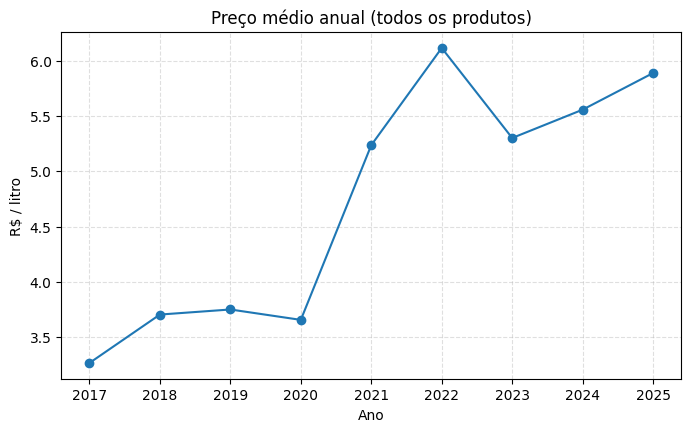

In [19]:
# ## Gráfico: média anual (todos os produtos)
SAVE_FIGS = False                     # True para salvar figuras em ./figs
FIG_DIR = "figs"
os.makedirs(FIG_DIR, exist_ok=True)
# %%
fig = plt.figure(figsize=(8,4.5))
desc_ano["media"].plot(marker="o")
plt.title("Preço médio anual (todos os produtos)")
plt.xlabel("Ano"); plt.ylabel("R$ / litro"); plt.grid(True, linestyle="--", alpha=0.4)
if SAVE_FIGS: plt.savefig(os.path.join(FIG_DIR, "media_anual_todos.png"), dpi=150, bbox_inches="tight")
plt.show()


Estatística por Produto x Ano

In [20]:
# # 5) Estatística por Produto x Ano

# %%
if "produto" in df.columns:
    desc_prod_ano = df.groupby(["produto","ano"])["valor_venda"].apply(describe_group).unstack()
    display(desc_prod_ano.round(3).sort_index())
else:
    print("Coluna 'produto' não encontrada.")


n  media  mediana    std    cv_%    p10    p90    iqr
produto            ano                                                               
DIESEL             2017  143472.0  3.100    3.090  0.227   7.313  2.840  3.390  0.241
                   2018  162342.0  3.503    3.490  0.248   7.067  3.199  3.800  0.331
                   2019  162263.0  3.600    3.590  0.244   6.789  3.299  3.897  0.301
                   2020  108750.0  3.418    3.399  0.360  10.526  2.959  3.879  0.541
                   2021   87905.0  4.694    4.647  0.543  11.574  3.999  5.400  0.759
                   2022  102477.0  6.631    6.690  0.719  10.849  5.540  7.540  0.950
                   2023  106136.0  5.758    5.850  0.588  10.212  4.890  6.450  0.760
                   2024  102581.0  5.972    5.890  0.372   6.233  5.590  6.440  0.410
                   2025   45771.0  6.239    6.190  0.400   6.409  5.790  6.760  0.480
DIESEL S10         2017  180110.0  3.218    3.199  0.228   7.085  2.959  3.499  0.270
                   2018  231937.0  3.594    3.589  0.243   6.761  3.299  3.899  0.350
                   2019  249503.0  3.691    3.690  0.234   6.340  3.399  3.980  0.271
                   2020  177945.0  3.508    3.499  0.353  10.051  3.039  3.950  0.538
                   2021  164496.0  4.741    4.699  0.542  11.432  4.043  5.490  0.752
                   2022  184760.0  6.734    6.790  0.730  10.835  5.590  7.640  0.970
                   2023  168461.0  5.860    5.980  0.605  10.329  4.990  6.590  0.810
                   2024  166268.0  6.031    5.990  0.369   6.112  5.650  6.490  0.400
                   2025   76134.0  6.292    6.290  0.413   6.567  5.800  6.790  0.500
ETANOL             2017  213853.0  2.897    2.890  0.424  14.624  2.379  3.490  0.592
                   2018  258991.0  3.133    3.090  0.433  13.814  2.599  3.699  0.670
                   2019  271379.0  3.168    3.085  0.486  15.355  2.599  3.880  0.760
                   2020  190504.0  3.178    3.169  0.535  16.828  2.490  3.890  0.751
                   2021  182872.0  4.671    4.679  0.770  16.492  3.699  5.630  1.100
                   2022  201350.0  4.852    4.860  0.873  18.004  3.690  5.990  1.300
                   2023  197849.0  4.005    3.980  0.520  12.982  3.390  4.690  0.790
                   2024  197306.0  4.068    3.990  0.513  12.615  3.430  4.740  0.700
                   2025   92598.0  4.478    4.470  0.459  10.245  3.890  4.990  0.650
GASOLINA           2017  239000.0  3.772    3.790  0.291   7.718  3.399  4.149  0.370
                   2018  294708.0  4.448    4.438  0.342   7.680  3.999  4.899  0.500
                   2019  305083.0  4.419    4.399  0.320   7.245  3.999  4.850  0.469
                   2020  214043.0  4.280    4.297  0.398   9.305  3.779  4.799  0.590
                   2021  204426.0  5.887    5.890  0.684  11.611  4.999  6.799  0.969
                   2022  228810.0  6.317    6.490  0.988  15.644  4.890  7.550  1.700
                   2023  232085.0  5.529    5.490  0.440   7.960  4.990  6.000  0.570
                   2024  233020.0  5.931    5.920  0.415   6.999  5.440  6.390  0.500
                   2025  110818.0  6.288    6.280  0.405   6.445  5.850  6.770  0.500
GASOLINA ADITIVADA 2020   15583.0  4.588    4.590  0.322   7.014  4.189  4.999  0.410
                   2021  152051.0  6.037    5.999  0.687  11.381  5.159  6.950  0.900
                   2022  172855.0  6.472    6.670  0.983  15.183  5.090  7.690  1.690
                   2023  180978.0  5.711    5.690  0.443   7.751  5.160  6.280  0.600
                   2024  180418.0  6.120    6.090  0.421   6.885  5.590  6.590  0.500
                   2025   85580.0  6.483    6.490  0.410   6.322  5.990  6.940  0.480
GNV                2017   12171.0  2.351    2.299  0.274  11.656  1.999  2.699  0.393
                   2018   15024.0  2.731    2.699  0.384  14.052  2.199  3.199  0.591
                   2019   15801.0  3.216    3.197  0.330  10.261  2.799  3.6

Gráficos: média anual por produto

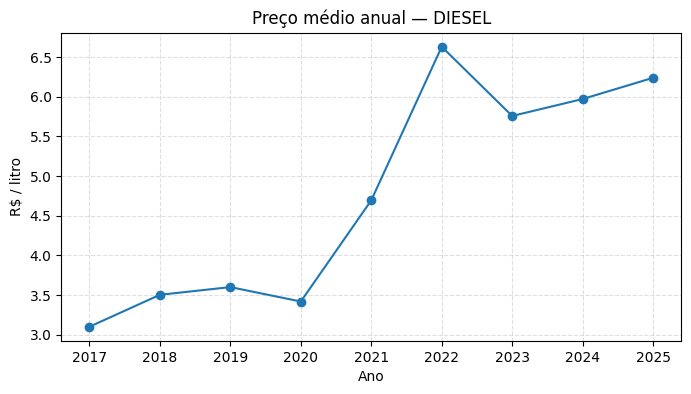

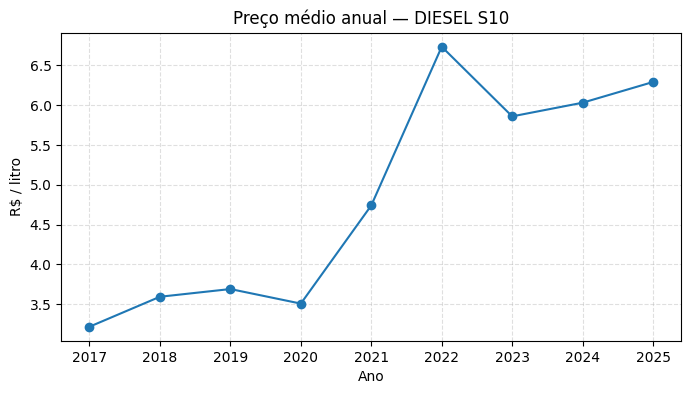

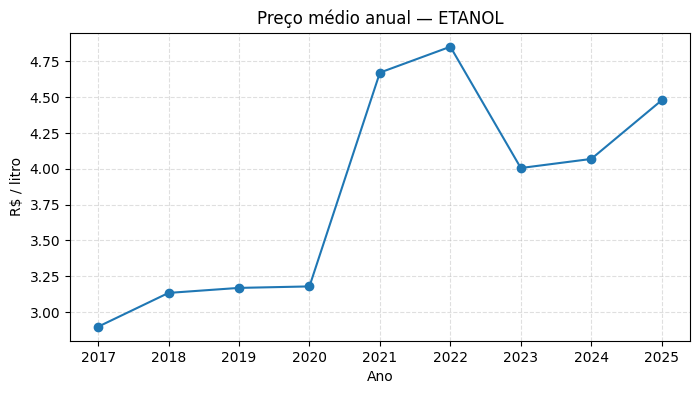

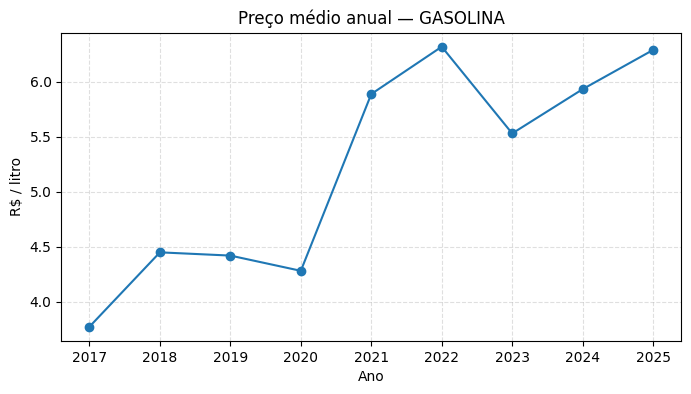

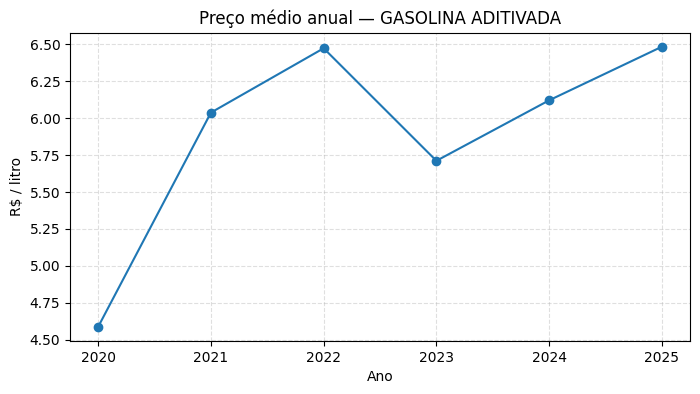

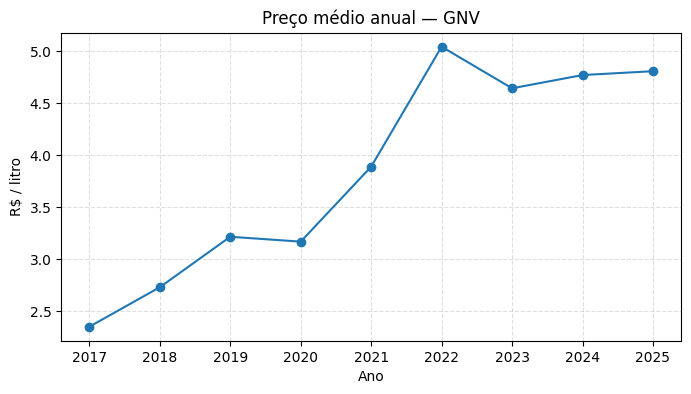

In [21]:
# ## Gráficos: média anual por produto

# %%
if "produto" in df.columns:
    for prod, sub in df.groupby("produto"):
        g = sub.groupby("ano")["valor_venda"].mean()
        fig = plt.figure(figsize=(8,4))
        g.plot(marker="o")
        plt.title(f"Preço médio anual — {prod}")
        plt.xlabel("Ano"); plt.ylabel("R$ / litro"); plt.grid(True, linestyle="--", alpha=0.4)
        if SAVE_FIGS: plt.savefig(os.path.join(FIG_DIR, f"media_anual_{prod}.png"), dpi=150, bbox_inches="tight")
        plt.show()


6) Estatística por Bandeira x Ano (e também por Produto)

In [22]:
# %% [markdown]
# # 6) Por Bandeira x Ano (e Produto x Bandeira x Ano)

# %%
if "bandeira" in df.columns:
    desc_band_ano = df.groupby(["bandeira","ano"])["valor_venda"].apply(describe_group).unstack()
    display(desc_band_ano.round(3).sort_index())

    if "produto" in df.columns:
        desc_prod_band_ano = df.groupby(["produto","bandeira","ano"])["valor_venda"].apply(describe_group).unstack()
        display(desc_prod_band_ano.round(3).sort_index())
else:
    print("Coluna 'bandeira' não encontrada.")


n  media  mediana    std    cv_%    p10    p90    iqr
bandeira                     ano                                                               
76 OIL                       2019       3.0  3.966    3.599  0.635  16.015  3.599  4.479  0.550
ACOL                         2017     380.0  3.279    3.199  0.490  14.950  2.689  3.980  0.899
                             2018     317.0  3.795    3.598  0.672  17.705  2.999  4.898  1.109
                             2019     134.0  3.790    3.620  0.668  17.624  2.999  4.799  1.401
                             2020      84.0  3.607    3.499  0.652  18.065  2.890  4.569  1.000
AIR BP                       2019       3.0  3.717    3.550  0.666  17.915  3.230  4.270  0.650
                             2023      95.0  5.623    5.770  0.534   9.494  4.808  6.182  0.895
ALE                          2024   17246.0  5.628    5.890  0.836  14.862  4.170  6.390  0.800
                             2025   11664.0  5.891    6.170  0.802  13.613  4.490  6.690  0.790
ALE COMBUSTÍVEIS             2017    3369.0  3.231    3.199  0.477  14.766  2.599  3.855  0.559
                             2018    1748.0  3.656    3.589  0.590  16.140  2.899  4.490  0.709
ALESAT                       2017   21212.0  3.295    3.250  0.458  13.895  2.749  3.899  0.600
                             2018   23265.0  3.749    3.619  0.618  16.480  2.997  4.690  0.820
                             2019   23696.0  3.815    3.740  0.583  15.294  2.999  4.690  0.733
                             2020   17496.0  3.697    3.669  0.612  16.548  2.950  4.590  0.810
                             2021   17409.0  5.273    5.250  0.933  17.694  4.139  6.599  1.350
                             2022   22967.0  6.090    6.200  1.160  19.044  4.590  7.540  1.800
                             2023   34277.0  5.303    5.490  0.850  16.032  3.940  6.250  1.150
                             2024   12825.0  5.396    5.740  0.898  16.639  3.820  6.190  0.820
AMAZONGÁS                    2022      13.0  5.687    5.300  1.246  21.911  4.210  7.390  2.000
AMERICANOIL                  2017     350.0  3.361    3.290  0.329   9.796  2.939  3.890  0.477
                             2018     391.0  3.671    3.499  0.467  12.709  3.099  4.269  0.779
                             2019     346.0  3.641    3.499  0.383  10.516  3.299  4.244  0.650
                             2020     341.0  3.582    3.569  0.508  14.189  2.949  4.349  0.800
                             2021     707.0  5.046    4.999  0.853  16.914  3.999  6.069  1.200
                             2022     536.0  6.453    6.590  0.801  12.407  5.290  7.460  1.350
                             2023      68.0  5.404    5.340  0.379   7.008  4.940  5.920  0.435
                             2024      36.0  5.717    5.990  0.734  12.841  4.590  6.460  0.683
                             2025       1.0  4.920    4.920    NaN     NaN  4.920  4.920  0.000
ATEM' S                      2017    3150.0  3.489    3.390  0.389  11.147  3.090  3.990  0.560
                             2018    4161.0  3.895    3.720  0.484  12.418  3.399  4.690  0.760
                             2019    4483.0  3.895    3.850  0.396  10.163  3.390  4.496  0.591
                             2020    3932.0  3.851    3.790  0.471  12.221  3.290  4.590  0.739
                             2021    4821.0  5.144    4.999  0.814  15.823  4.150  6.290  1.230
                             2022    4627.0  6.372    6.590  1.065  16.719  4.990  7.590  1.720
                             2023    4153.0  5.931    6.190  0.922  15.551  4.590  6.980  1.600
                             2024    3790.0  6.283    6.390  0.957  15.224  4.890  7.500  0.900
                             2025    1836.0  6.645    6.890  0.861  12.965  5.490  7.335  1.000
ATLÂNTICA                    2017    1008.0  3.428    3.320  0.351  10.238  3.050  3.919  0.640
                             2018     965.0  3.866    3.690  0.517  13.370  3.290  4.640  0.960
          

n  media  mediana    std    cv_%    p10    p90    iqr
produto            bandeira                     ano                                                               
DIESEL             76 OIL                       2019       1.0  3.599    3.599    NaN     NaN  3.599  3.599  0.000
                   ACOL                         2017      78.0  3.140    3.099  0.120   3.812  2.999  3.299  0.135
                                                2018      91.0  3.582    3.538  0.144   4.009  3.439  3.879  0.120
                                                2019      34.0  3.605    3.550  0.154   4.264  3.408  3.842  0.228
                                                2020      27.0  3.451    3.399  0.242   7.022  3.199  3.799  0.329
                   AIR BP                       2023      19.0  5.658    5.690  0.442   7.811  5.138  6.106  0.730
                   ALE                          2024    1935.0  5.934    5.890  0.278   4.679  5.650  6.290  0.350
                                                2025    1247.0  6.175    6.150  0.315   5.097  5.790  6.590  0.380
                   ALE COMBUSTÍVEIS             2017     568.0  3.097    3.090  0.191   6.154  2.890  3.329  0.201
                                                2018     260.0  3.445    3.398  0.238   6.917  3.199  3.839  0.217
                   ALESAT                       2017    3820.0  3.113    3.099  0.158   5.064  2.900  3.300  0.200
                                                2018    3834.0  3.536    3.500  0.193   5.467  3.290  3.799  0.290
                                                2019    3686.0  3.624    3.599  0.179   4.930  3.399  3.850  0.260
                                                2020    2551.0  3.441    3.440  0.323   9.388  2.998  3.880  0.501
                                                2021    1856.0  4.728    4.694  0.516  10.910  4.090  5.400  0.743
                                                2022    2758.0  6.645    6.700  0.669  10.067  5.590  7.490  0.800
                                                2023    4147.0  5.744    5.870  0.549   9.558  4.890  6.390  0.700
                                                2024    1461.0  5.857    5.800  0.270   4.611  5.590  6.250  0.340
                   AMAZONGÁS                    2022       1.0  7.390    7.390    NaN     NaN  7.390  7.390  0.000
                   AMERICANOIL                  2018      24.0  3.277    3.300  0.184   5.630  2.999  3.478  0.325
                                                2019      59.0  3.381    3.399  0.067   1.994  3.299  3.449  0.050
                                                2020      63.0  3.228    3.249  0.233   7.225  2.949  3.519  0.425
                                                2021     130.0  4.502    4.389  0.482  10.715  3.999  5.249  0.550
                                                2022     115.0  6.395    6.390  0.741  11.591  5.290  7.340  1.435
                                                2023       9.0  5.368    5.290  0.600  11.169  4.790  6.190  1.100
                                                2024       9.0  5.934    5.890  0.085   1.425  5.840  6.010  0.100
                   ATEM' S                      2017     751.0  3.266    3.250  0.203   6.204  2.990  3.550  0.209
                                                2018    1009.0  3.582    3.539  0.199   5.567  3.350  3.850  0.360
                                                2019    1067.0  3.769    3.750  0.169   4.482  3.590  3.984  0.160
                                                2020     823.0  3.598    3.599  0.274   7.614  3.220  3.900  0.400
                                                2021     829.0  4.729    4.650  0.617  13.041  3.942  5.490  0.700
                                                2022     794.0  6.842    6.790  0.715  10.444  5.750  7.790  0.875
                                                2023     690.0  6.154    6.290  0.745  12.112  4.990  6.990  0.900
                                    

Gráfico: média anual por bandeira (Top 6 por n)

<Figure size 900x500 with 0 Axes>

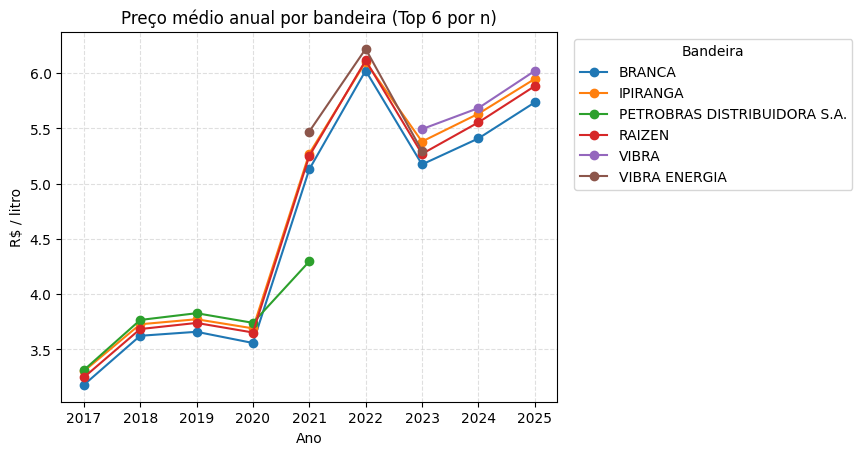

In [23]:

# ## Gráfico: média anual por bandeira (Top 6 por n)

# %%
if "bandeira" in df.columns:
    counts = df.groupby("bandeira")["valor_venda"].count().sort_values(ascending=False)
    top = counts.head(6).index.tolist()
    piv = df[df["bandeira"].isin(top)].groupby(["ano","bandeira"])["valor_venda"].mean().unstack()

    fig = plt.figure(figsize=(9,5))
    piv.plot(marker="o")
    plt.title("Preço médio anual por bandeira (Top 6 por n)")
    plt.xlabel("Ano"); plt.ylabel("R$ / litro"); plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(title="Bandeira", bbox_to_anchor=(1.02,1), loc="upper left")
    if SAVE_FIGS: plt.savefig(os.path.join(FIG_DIR, "media_anual_por_bandeira.png"), dpi=150, bbox_inches="tight")
    plt.show()


7) Estatística por Região x Ano (e Produto x Região)

In [24]:
if "regiao_sigla" in df.columns:
    desc_reg_ano = df.groupby(["regiao_sigla","ano"])["valor_venda"].apply(describe_group).unstack()
    display(desc_reg_ano.round(3).sort_index())

    if "produto" in df.columns:
        desc_prod_reg_ano = df.groupby(["produto","regiao_sigla","ano"])["valor_venda"].apply(describe_group).unstack()
        display(desc_prod_reg_ano.round(3).sort_index())
else:
    print("Coluna 'regiao_sigla' não encontrada.")


n  media  mediana    std    cv_%    p10    p90    iqr
regiao_sigla ano                                                               
CO           2017   70103.0  3.328    3.360  0.477  14.343  2.680  3.899  0.691
             2018   89576.0  3.749    3.699  0.640  17.074  2.890  4.655  0.900
             2019   93234.0  3.741    3.797  0.621  16.601  2.850  4.539  0.959
             2020   68810.0  3.659    3.629  0.637  17.423  2.869  4.599  0.880
             2021   69547.0  5.280    5.199  0.923  17.484  4.155  6.550  1.350
             2022   81395.0  6.057    6.290  1.224  20.211  4.390  7.540  1.900
             2023   67115.0  5.173    5.440  0.963  18.605  3.640  6.210  1.300
             2024   70638.0  5.466    5.860  0.981  17.952  3.790  6.370  0.780
             2025   32876.0  5.855    6.190  0.910  15.550  4.240  6.670  0.830
N            2017   47194.0  3.625    3.570  0.416  11.472  3.149  4.200  0.599
             2018   58320.0  4.051    3.950  0.504  12.452  3.489  4.790  0.810
             2019   60346.0  4.112    3.999  0.456  11.079  3.579  4.769  0.671
             2020   44317.0  3.981    3.950  0.530  13.317  3.290  4.739  0.760
             2021   47193.0  5.472    5.480  0.830  15.165  4.399  6.590  1.230
             2022   57699.0  6.572    6.780  1.011  15.381  5.160  7.750  1.590
             2023   60656.0  5.907    5.990  0.780  13.204  4.790  6.860  1.100
             2024   59194.0  6.165    6.290  0.825  13.378  4.890  7.050  0.860
             2025   28003.0  6.537    6.690  0.799  12.230  5.320  7.290  0.910
NE           2017  159702.0  3.315    3.230  0.375  11.304  2.899  3.890  0.511
             2018  188765.0  3.795    3.650  0.507  13.371  3.280  4.590  0.769
             2019  198748.0  3.890    3.790  0.465  11.940  3.390  4.590  0.711
             2020  144748.0  3.761    3.690  0.520  13.835  3.133  4.570  0.709
             2021  153529.0  5.351    5.379  0.867  16.208  4.250  6.590  1.230
             2022  177477.0  6.364    6.490  1.080  16.978  4.950  7.690  1.650
             2023  177375.0  5.417    5.570  0.755  13.937  4.290  6.290  1.140
             2024  182416.0  5.668    5.890  0.750  13.232  4.430  6.460  0.870
             2025   83107.0  5.979    6.190  0.724  12.110  4.790  6.750  0.950
S            2017  130062.0  3.286    3.199  0.461  14.030  2.760  3.900  0.730
             2018  157436.0  3.702    3.579  0.582  15.708  3.050  4.550  0.901
             2019  162298.0  3.729    3.640  0.520  13.945  3.070  4.470  0.709
             2020  115515.0  3.639    3.599  0.582  15.990  2.899  4.470  0.879
             2021  135564.0  5.278    5.277  0.939  17.798  4.149  6.590  1.490
             2022  155386.0  6.170    6.390  0.934  15.144  4.890  7.310  1.500
             2023  161453.0  5.440    5.590  0.692  12.721  4.390  6.190  0.870
             2024  152372.0  5.710    5.950  0.752  13.172  4.290  6.390  0.600
             2025   73531.0  6.046    6.290  0.746  12.335  4.690  6.740  0.600
SE           2017  381545.0  3.178    3.179  0.505  15.887  2.499  3.869  0.620
             2018  468905.0  3.613    3.540  0.676  18.699  2.700  4.599  0.930
             2019  489403.0  3.654    3.649  0.649  17.768  2.729  4.590  0.898
             2020  345910.0  3.572    3.549  0.666  18.645  2.699  4.499  0.900
             2021  401704.0  5.146    5.099  0.944  18.345  3.999  6.431  1.350
             2022  435545.0  5.950    6.060  1.187  19.950  4.380  7.450  1.900
             2023  437401.0  5.141    5.370  0.930  18.089  3.660  6.180  1.200
             2024  433916.0  5.392    5.770  0.985  18.276  3.770  6.290  1.300
             2025  202892.0  5.715    5.990  0.956  16.727  4.170  6.590  1.480

n  media  mediana    std    cv_%    p10    p90    iqr
produto            regiao_sigla ano                                                               
DIESEL             CO           2017   14287.0  3.275    3.269  0.217   6.633  2.999  3.590  0.300
                                2018   16817.0  3.670    3.650  0.221   6.023  3.399  3.969  0.300
                                2019   16930.0  3.727    3.699  0.221   5.935  3.450  3.999  0.270
                                2020   11602.0  3.519    3.499  0.346   9.846  3.049  3.952  0.540
                                2021    9172.0  4.856    4.799  0.543  11.188  4.199  5.590  0.800
                                2022   11574.0  6.697    6.790  0.665   9.935  5.640  7.500  0.870
                                2023   10093.0  5.760    5.890  0.586  10.175  4.880  6.390  0.840
                                2024   10114.0  5.932    5.890  0.348   5.862  5.590  6.340  0.380
                                2025    4718.0  6.210    6.190  0.387   6.238  5.770  6.650  0.480
                   N            2017   11897.0  3.379    3.350  0.291   8.622  3.040  3.749  0.360
                                2018   13965.0  3.763    3.729  0.313   8.327  3.399  4.160  0.411
                                2019   13655.0  3.922    3.890  0.320   8.154  3.550  4.380  0.381
                                2020    9389.0  3.733    3.720  0.442  11.830  3.159  4.330  0.601
                                2021    8130.0  5.020    4.979  0.623  12.405  4.268  5.850  0.891
                                2022   10143.0  6.981    6.990  0.753  10.784  5.850  7.890  0.980
                                2023   10270.0  6.183    6.270  0.677  10.958  5.190  6.990  0.960
                                2024    9724.0  6.436    6.370  0.522   8.113  5.810  7.190  0.690
                                2025    4279.0  6.733    6.740  0.530   7.873  6.090  7.420  0.605
                   NE           2017   25927.0  3.086    3.090  0.162   5.239  2.890  3.290  0.200
                                2018   26876.0  3.538    3.499  0.208   5.867  3.290  3.820  0.300
                                2019   26354.0  3.672    3.679  0.181   4.927  3.440  3.899  0.230
                                2020   17723.0  3.467    3.479  0.330   9.505  2.999  3.890  0.539
                                2021   11980.0  4.781    4.749  0.558  11.679  3.999  5.549  0.809
                                2022   15046.0  6.874    6.950  0.711  10.343  5.750  7.760  0.900
                                2023   17300.0  5.776    5.870  0.596  10.311  4.890  6.490  0.850
                                2024   17801.0  5.984    5.940  0.330   5.507  5.590  6.470  0.440
                                2025    7458.0  6.221    6.190  0.365   5.868  5.750  6.750  0.520
                   S            2017   24328.0  2.965    2.969  0.186   6.275  2.740  3.199  0.250
                                2018   28164.0  3.355    3.320  0.200   5.953  3.099  3.630  0.291
                                2019   28386.0  3.450    3.449  0.179   5.186  3.200  3.687  0.240
                                2020   19450.0  3.280    3.289  0.331  10.094  2.850  3.699  0.551
                                2021   17216.0  4.535    4.479  0.511  11.266  3.899  5.249  0.751
                                2022   20564.0  6.457    6.540  0.689  10.678  5.390  7.350  0.850
                                2023   22306.0  5.675    5.790  0.531   9.349  4.890  6.290  0.700
                                2024   20809.0  5.938    5.890  0.278   4.678  5.590  6.290  0.330
                                2025    9572.0  6.214    6.190  0.307   4.939  5.790  6.590  0.400
                   SE           2017   67033.0  3.067    3.059  0.185   6.018  2.849  3.299  0.241
                                2018   76520.0  3.460    3.449  0.207   5.970  3.199  3.740  0.300
                                2019   76938.0  3.545    3.549  0.197   5.569  3.299 

Gráfico: média anual por região

<Figure size 900x500 with 0 Axes>

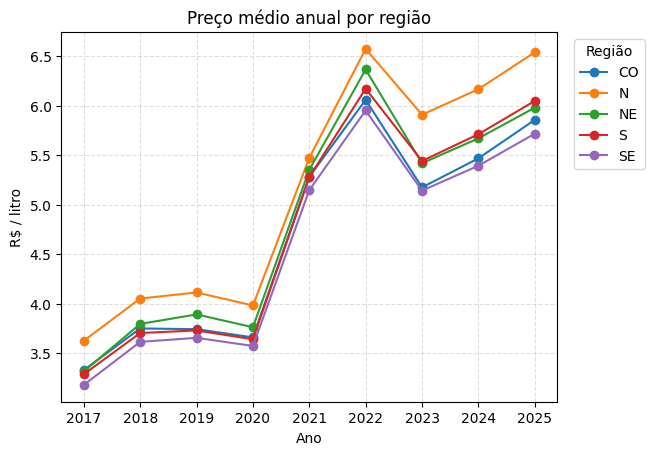

In [25]:
if "regiao_sigla" in df.columns:
    piv = df.groupby(["ano","regiao_sigla"])["valor_venda"].mean().unstack()
    fig = plt.figure(figsize=(9,5))
    piv.plot(marker="o")
    plt.title("Preço médio anual por região")
    plt.xlabel("Ano"); plt.ylabel("R$ / litro"); plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(title="Região", bbox_to_anchor=(1.02,1), loc="upper left")
    if SAVE_FIGS: plt.savefig(os.path.join(FIG_DIR, "media_anual_por_regiao.png"), dpi=150, bbox_inches="tight")
    plt.show()

8) Estatística por Estado (UF) x Ano e Município x Ano (aninhado por UF)

In [26]:
df.head(1)

,regiao_sigla,estado_sigla,municipio,revenda,cnpj_revenda,rua,bairro,cep,produto,data_coleta,valor_venda,unidade_medida,bandeira,ano
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,JARDIM ZULMIRA,18061-000,GASOLINA,2023-07-03,4.87,R$ / litro,BRANCA,2023


n  media  mediana    std    cv_%    p10    p90    iqr
estado_sigla ano                                                               
AC           2017    4963.0  4.004    3.900  0.364   9.091  3.640  4.600  0.520
             2018    6593.0  4.469    4.440  0.451  10.087  3.990  4.990  0.660
             2019    6799.0  4.532    4.480  0.357   7.881  3.990  4.990  0.460
             2020    5344.0  4.458    4.470  0.434   9.723  3.880  4.990  0.750
             2021    7523.0  5.952    6.090  0.710  11.925  5.070  6.900  0.921
             2022    6404.0  7.006    7.290  0.963  13.747  5.670  7.990  1.432
             2023    3504.0  6.378    6.590  0.873  13.685  4.790  7.454  1.020
             2024    4113.0  6.966    7.190  0.878  12.607  5.050  7.730  0.690
             2025    1520.0  7.424    7.690  0.912  12.282  5.490  8.170  0.620
AL           2017    8879.0  3.384    3.290  0.366  10.805  2.999  3.899  0.599
             2018    9958.0  3.856    3.699  0.517  13.417  3.300  4.690  0.750
             2019   10532.0  3.968    3.859  0.454  11.444  3.455  4.620  0.640
             2020    8121.0  3.871    3.799  0.514  13.275  3.279  4.678  0.709
             2021    8557.0  5.355    5.349  0.831  15.521  4.290  6.449  1.183
             2022    9881.0  6.244    6.390  1.090  17.463  4.790  7.550  1.700
             2023   10746.0  5.495    5.650  0.815  14.826  4.290  6.550  1.120
             2024   10666.0  5.706    5.890  0.841  14.744  4.450  6.740  1.237
             2025    4601.0  6.019    6.290  0.771  12.804  4.890  6.990  1.370
AM           2017    8698.0  3.576    3.490  0.416  11.644  3.100  4.200  0.600
             2018    9906.0  4.001    3.830  0.550  13.759  3.430  4.890  0.940
             2019   10468.0  3.958    3.890  0.461  11.651  3.390  4.590  0.651
             2020    8886.0  3.913    3.865  0.516  13.196  3.290  4.690  0.790
             2021   10442.0  5.122    4.990  0.842  16.447  4.099  6.290  1.290
             2022   10916.0  6.300    6.590  1.126  17.869  4.790  7.650  1.900
             2023   10557.0  5.962    6.290  0.924  15.499  4.590  6.990  1.600
             2024   10474.0  6.243    6.390  0.955  15.302  4.690  7.380  0.900
             2025    5081.0  6.804    6.980  0.855  12.561  5.490  7.990  0.700
AP           2017    2218.0  3.732    3.690  0.247   6.623  3.450  4.050  0.411
             2018    3335.0  4.085    3.999  0.275   6.730  3.770  4.490  0.360
             2019    2981.0  4.165    4.070  0.362   8.696  3.740  4.690  0.580
             2020    2239.0  3.642    3.650  0.423  11.611  3.090  4.171  0.590
             2021    1984.0  4.985    4.900  0.561  11.256  4.190  5.860  0.680
             2022    2396.0  6.114    6.250  0.903  14.762  4.760  7.220  1.310
             2023    2325.0  5.637    5.510  0.639  11.334  4.910  6.586  0.830
             2024    2662.0  6.073    6.090  0.485   7.984  5.520  6.520  0.600
             2025    1136.0  6.238    6.180  0.394   6.316  5.830  6.750  0.550
BA           2017   48521.0  3.283    3.190  0.403  12.270  2.870  3.899  0.589
             2018   58292.0  3.786    3.599  0.553  14.618  3.230  4.689  0.810
             2019   61199.0  3.857    3.690  0.509  13.201  3.318  4.659  0.880
             2020   43384.0  3.716    3.599  0.556  14.962  3.029  4.589  0.802
             2021   38206.0  5.340    5.349  0.891  16.694  4.190  6.599  1.252
             2022   48255.0  6.509    6.660  1.106  16.989  5.090  7.930  1.730
             2023   49656.0  5.482    5.690  0.766  13.978  4.290  6.360  1.180
             2024   53180.0  5.728    5.990  0.800  13.962  4.390  6.530  0.910
             2025   23121.0  6.016    6.290  0.761  12.651  4.770  6.790  0.960
CE           2017   29205.0  3.465    3.299  0.347  10.009  3.150  3.990  0.600
             2018   35814.0  3.908    3.760  0.456  11.657  3.459  4.650  0.750
             2019   37049.0  4.020    3.890  0.396   9.853  3.599  4.650  0.641
             2020   26886.

,estado_sigla,municipio,ano,n,media,mediana,std
0,AC,CRUZEIRO DO SUL,2017,967,4.404455,4.260,0.331386
1,AC,CRUZEIRO DO SUL,2018,1337,4.820540,4.740,0.443568
2,AC,CRUZEIRO DO SUL,2019,1526,4.897352,4.850,0.264933
3,AC,CRUZEIRO DO SUL,2020,939,4.825838,4.859,0.299843
4,AC,CRUZEIRO DO SUL,2021,1614,6.496313,6.420,0.544637
5,AC,CRUZEIRO DO SUL,2022,1375,7.615234,7.770,0.793189
6,AC,CRUZEIRO DO SUL,2023,713,7.236942,7.430,0.573985
7,AC,CRUZEIRO DO SUL,2024,1447,7.431244,7.590,0.646019
8,AC,CRUZEIRO DO SUL,2025,609,7.784926,8.090,0.721198
9,AC,RIO BRANCO,2017,3992,3.906795,3.800,0.299627


<Figure size 1000x500 with 0 Axes>

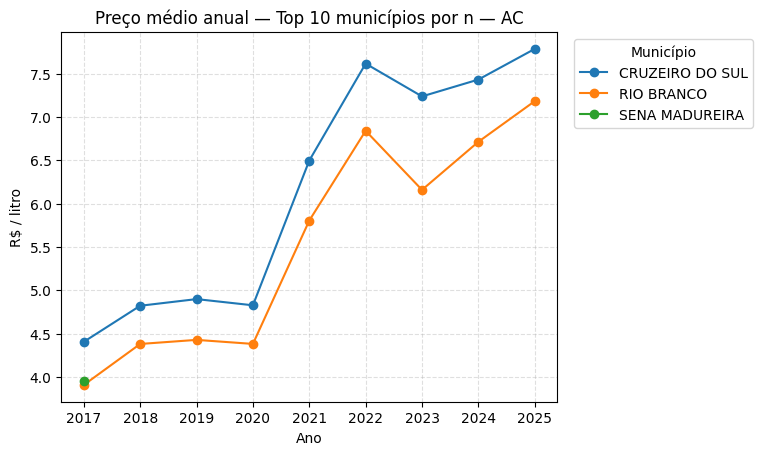

<Figure size 1000x500 with 0 Axes>

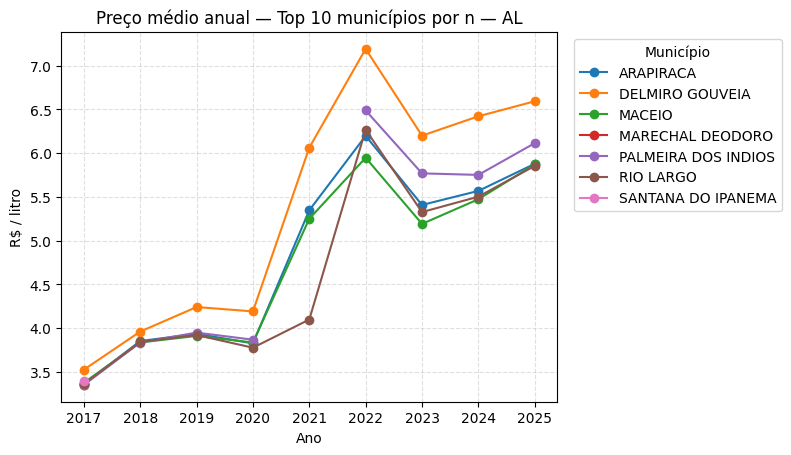

<Figure size 1000x500 with 0 Axes>

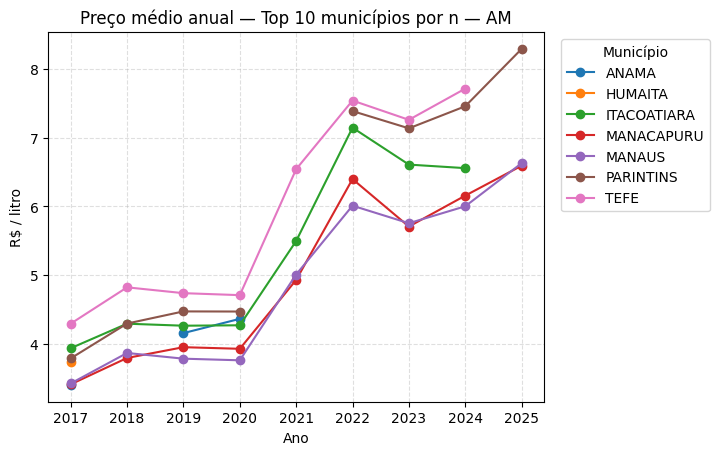

<Figure size 1000x500 with 0 Axes>

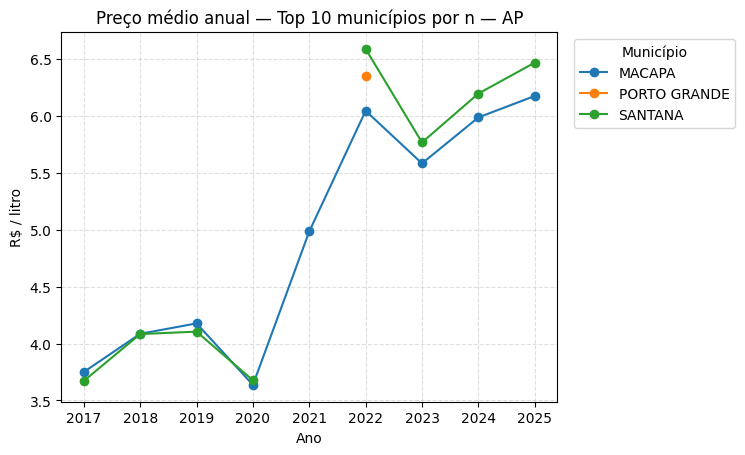

<Figure size 1000x500 with 0 Axes>

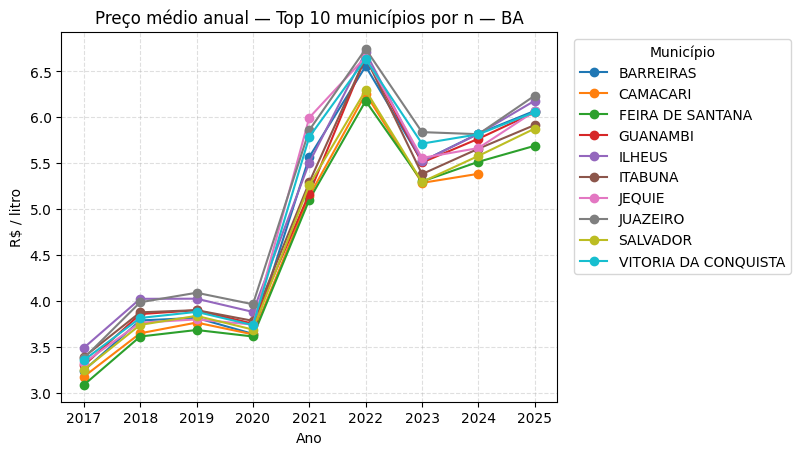

<Figure size 1000x500 with 0 Axes>

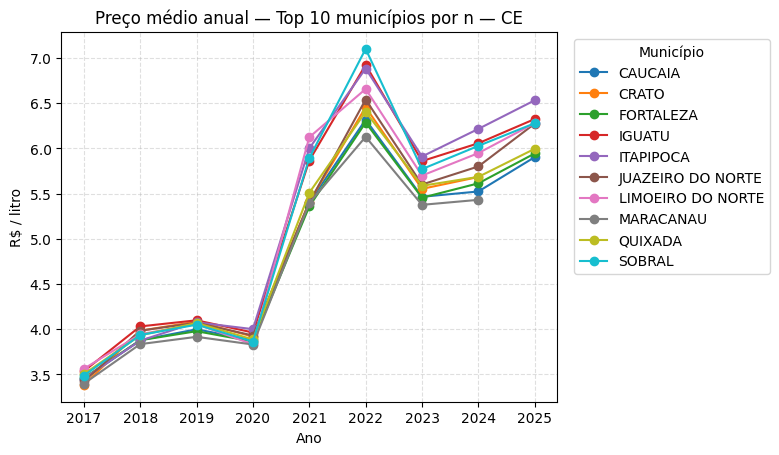

<Figure size 1000x500 with 0 Axes>

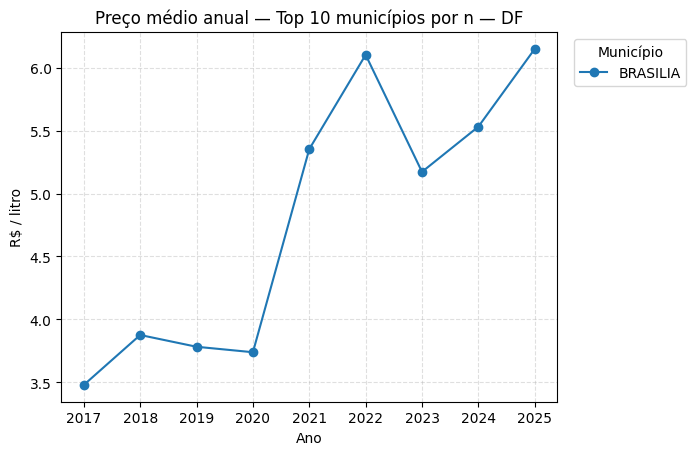

<Figure size 1000x500 with 0 Axes>

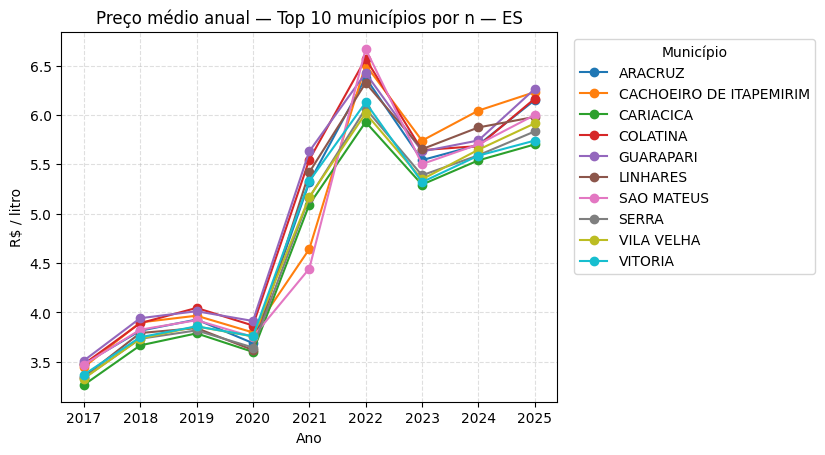

<Figure size 1000x500 with 0 Axes>

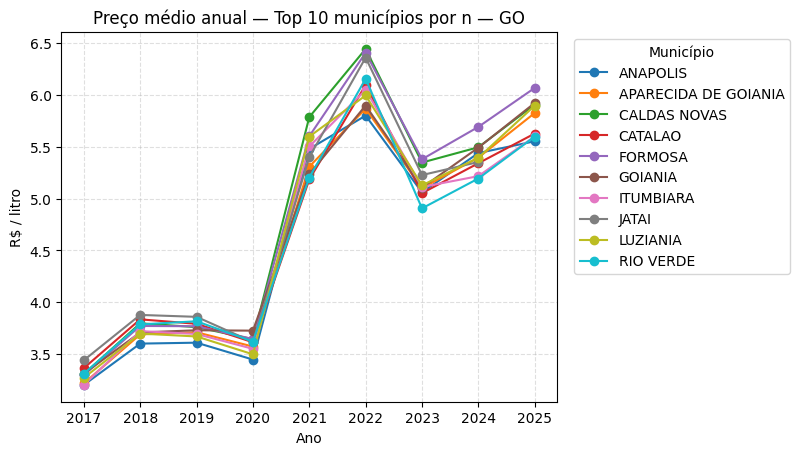

<Figure size 1000x500 with 0 Axes>

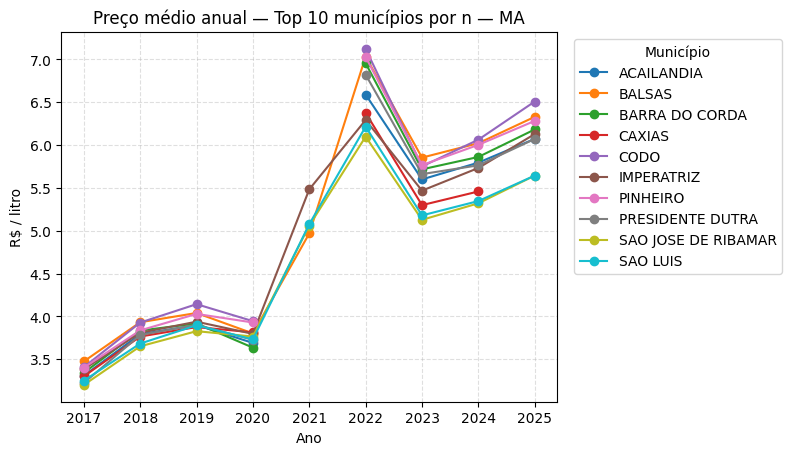

<Figure size 1000x500 with 0 Axes>

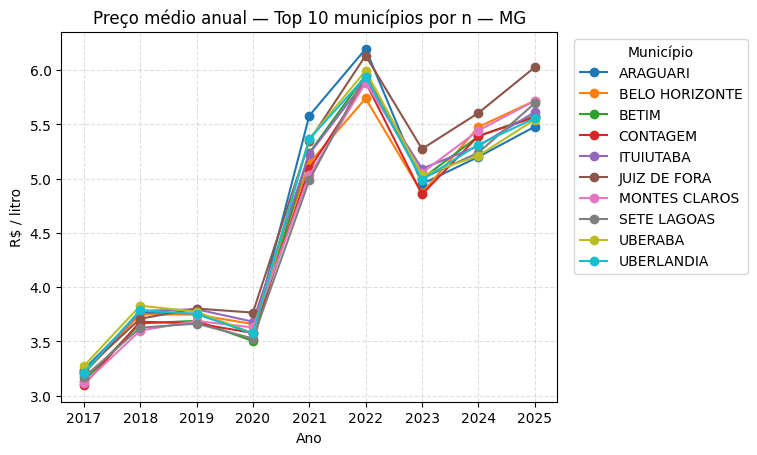

<Figure size 1000x500 with 0 Axes>

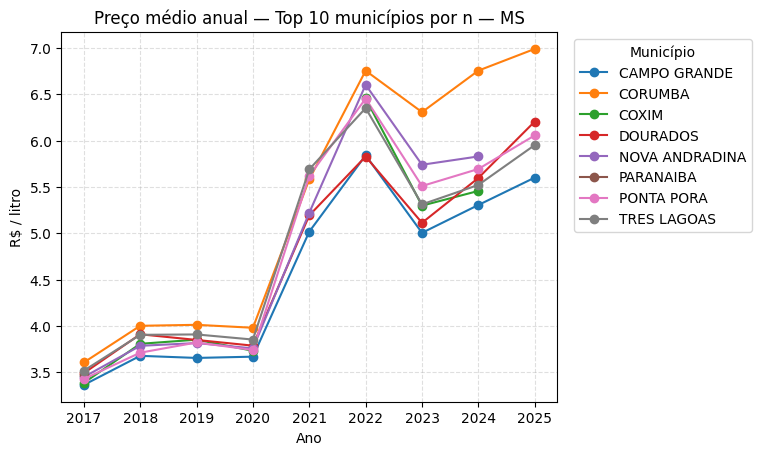

<Figure size 1000x500 with 0 Axes>

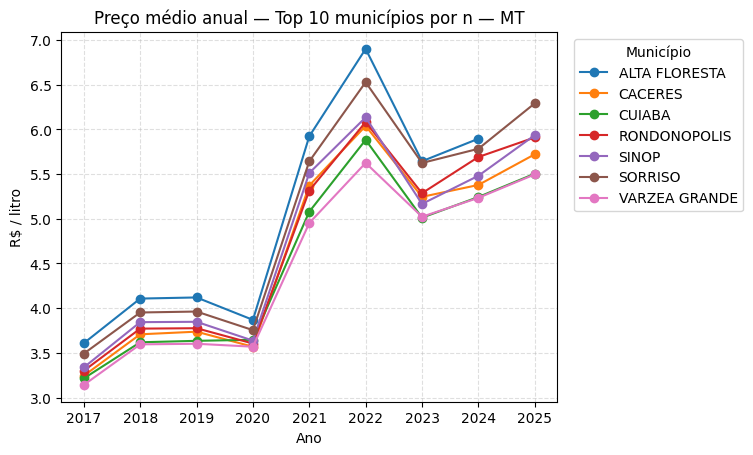

<Figure size 1000x500 with 0 Axes>

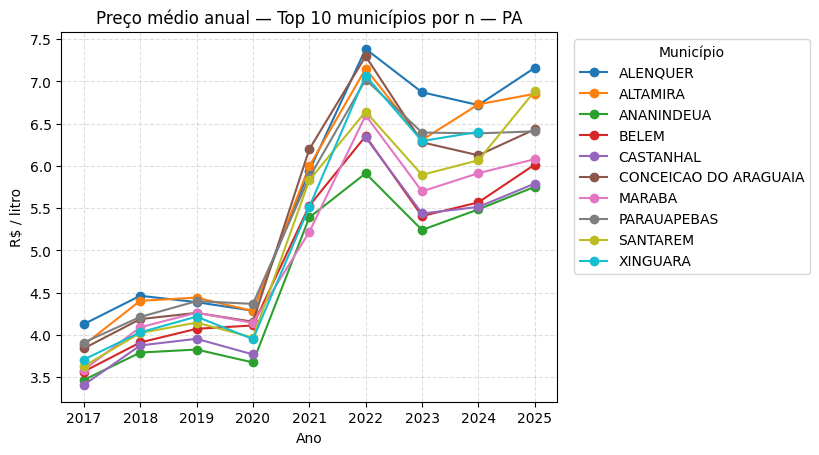

<Figure size 1000x500 with 0 Axes>

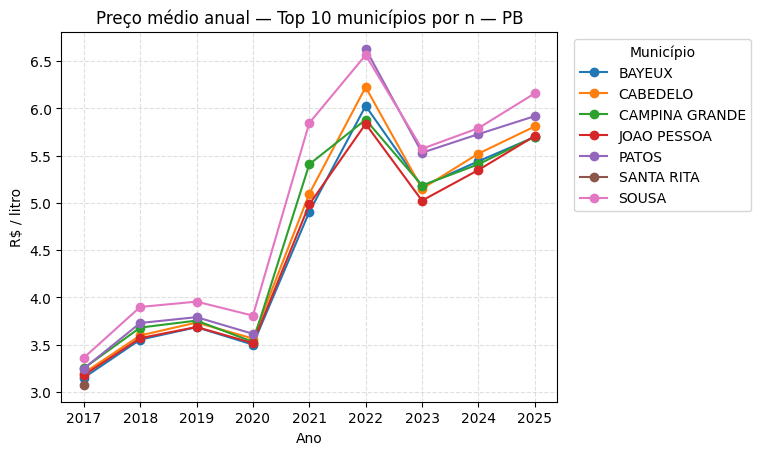

<Figure size 1000x500 with 0 Axes>

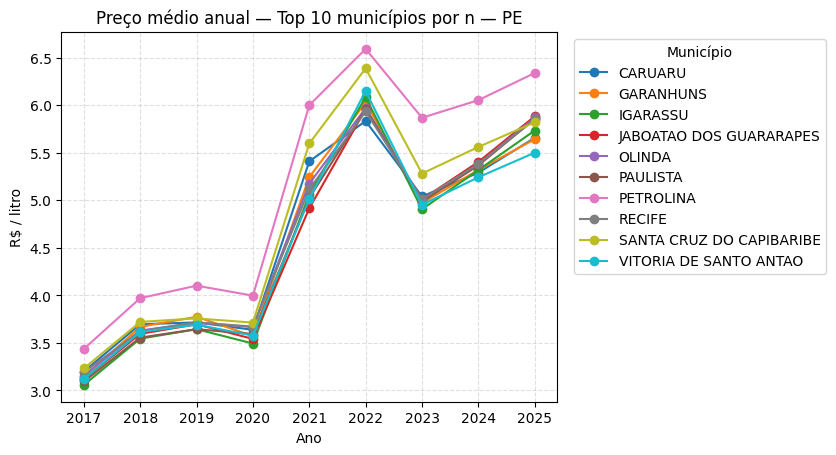

<Figure size 1000x500 with 0 Axes>

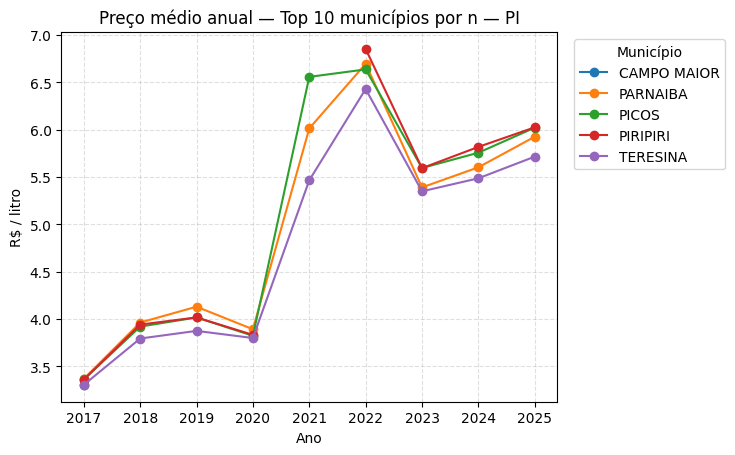

<Figure size 1000x500 with 0 Axes>

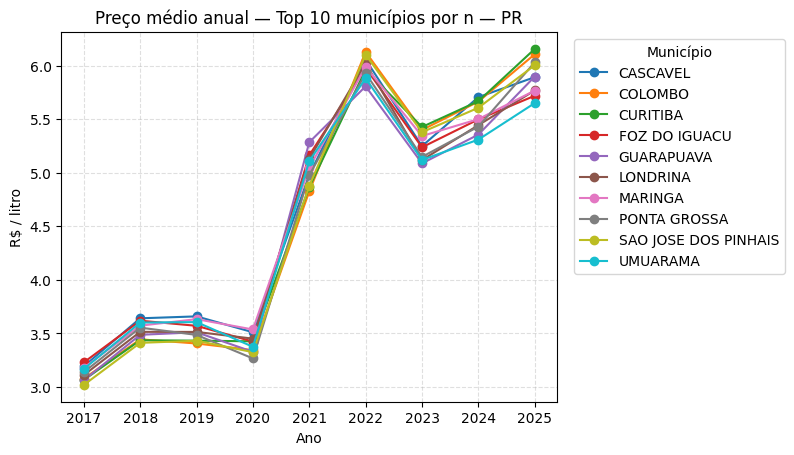

<Figure size 1000x500 with 0 Axes>

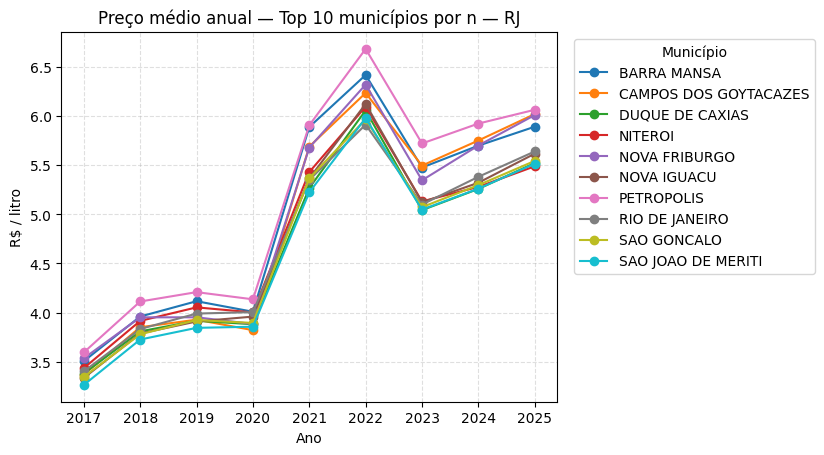

<Figure size 1000x500 with 0 Axes>

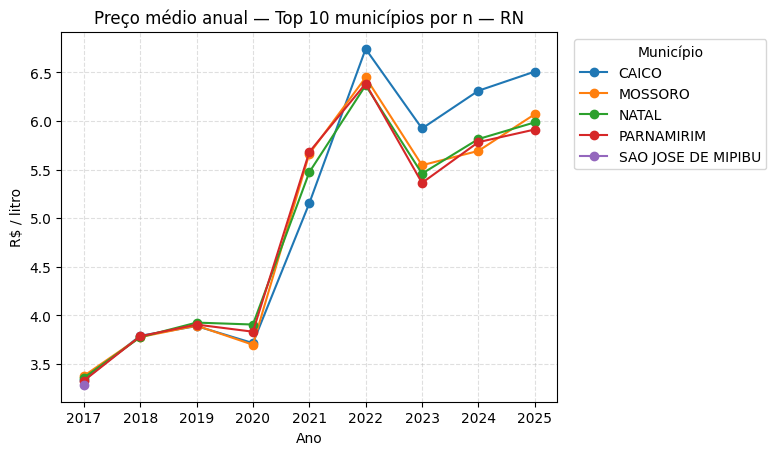

<Figure size 1000x500 with 0 Axes>

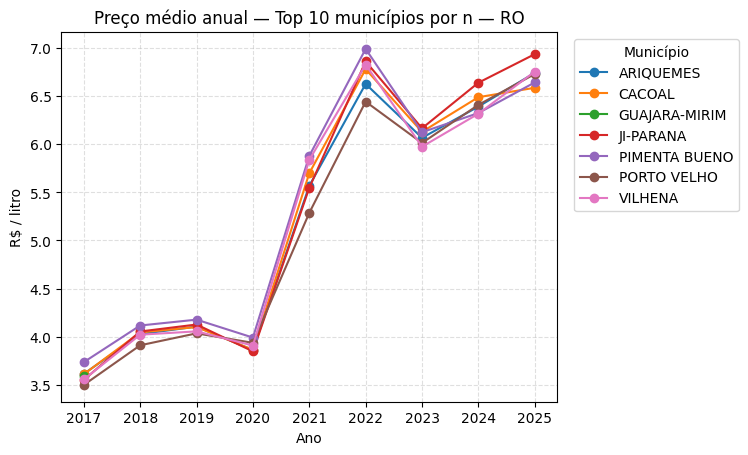

<Figure size 1000x500 with 0 Axes>

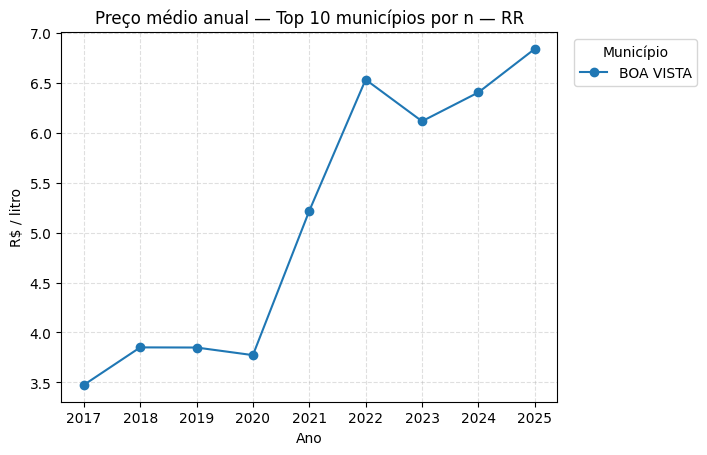

<Figure size 1000x500 with 0 Axes>

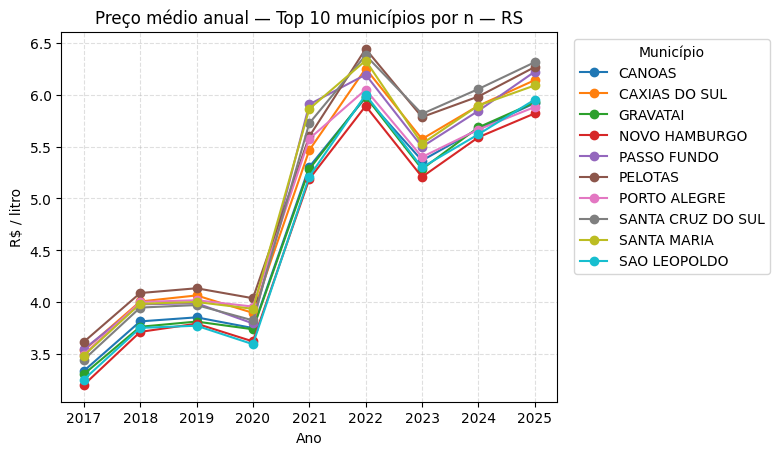

<Figure size 1000x500 with 0 Axes>

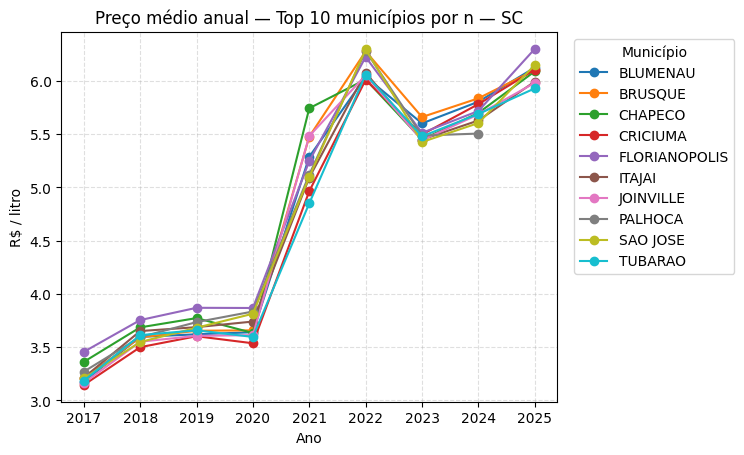

<Figure size 1000x500 with 0 Axes>

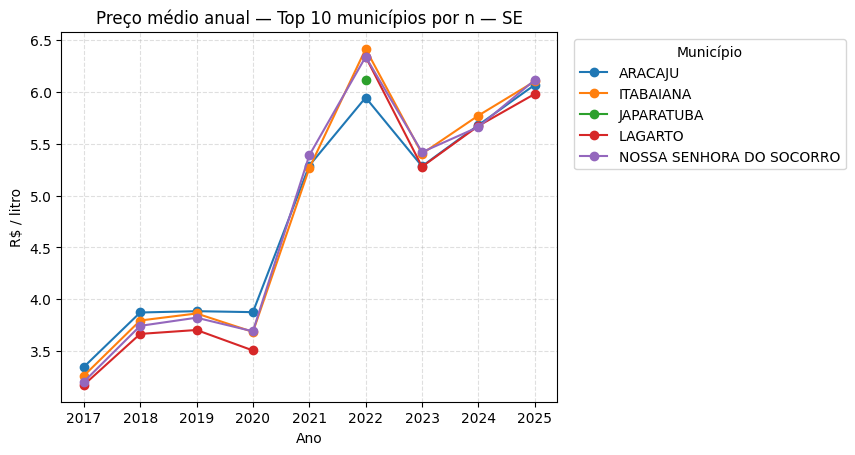

<Figure size 1000x500 with 0 Axes>

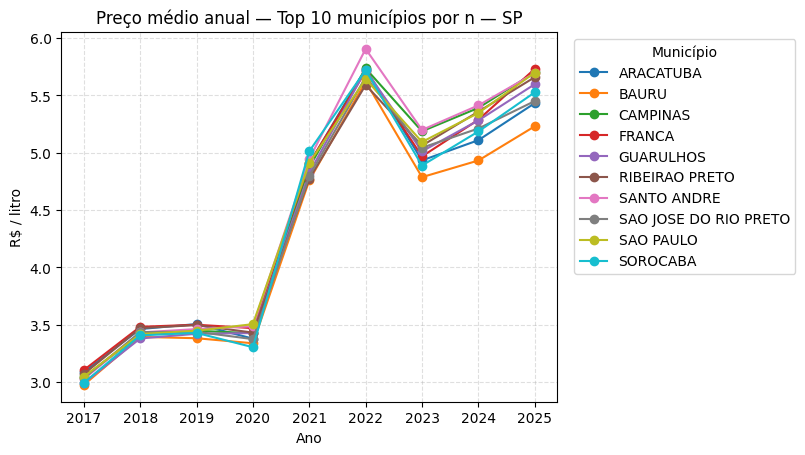

<Figure size 1000x500 with 0 Axes>

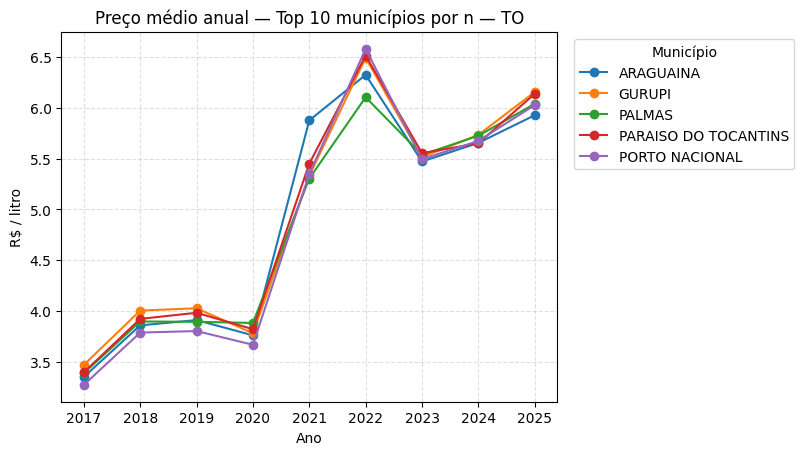

In [27]:
if "estado_sigla" in df.columns:
    desc_uf_ano = df.groupby(["estado_sigla","ano"])["valor_venda"].apply(describe_group).unstack()
    display(desc_uf_ano.round(3).sort_index())
else:
    print("Coluna 'estado_sigla' (UF) não encontrada.")

# %%
# --- Municípios dentro de cada UF ---
if all(c in df.columns for c in ["estado_sigla", "municipio"]):
    # resumo municipal anual (média e dispersão) por UF
    desc_mun_ano = (df.groupby(["estado_sigla","municipio","ano"])["valor_venda"]
                      .agg(n="count", media="mean", mediana="median", std="std"))
    display(desc_mun_ano.reset_index().head(20))

    # para cada UF, mostra top 10 municípios por n com tendência anual
    UFs = sorted(df["estado_sigla"].dropna().unique())
    for uf in UFs:
        sub = df[df["estado_sigla"]==uf]
        top_muns = (sub.groupby("municipio")["valor_venda"].count()
                       .sort_values(ascending=False).head(10).index)
        piv = (sub[sub["municipio"].isin(top_muns)]
               .groupby(["ano","municipio"])["valor_venda"].mean().unstack())

        fig = plt.figure(figsize=(10,5))
        piv.plot(marker="o")
        plt.title(f"Preço médio anual — Top 10 municípios por n — {uf}")
        plt.xlabel("Ano"); plt.ylabel("R$ / litro"); plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend(title="Município", bbox_to_anchor=(1.02,1), loc="upper left")
        if SAVE_FIGS: plt.savefig(os.path.join(FIG_DIR, f"media_anual_top_municipios_{uf}.png"), dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("Colunas 'estado' e/ou 'municipio' não encontradas.")

9) Dispersão e spread intra-ano (p10–p90) por UF e por produto

In [28]:
df.head(1)

,regiao_sigla,estado_sigla,municipio,revenda,cnpj_revenda,rua,bairro,cep,produto,data_coleta,valor_venda,unidade_medida,bandeira,ano
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,JARDIM ZULMIRA,18061-000,GASOLINA,2023-07-03,4.87,R$ / litro,BRANCA,2023


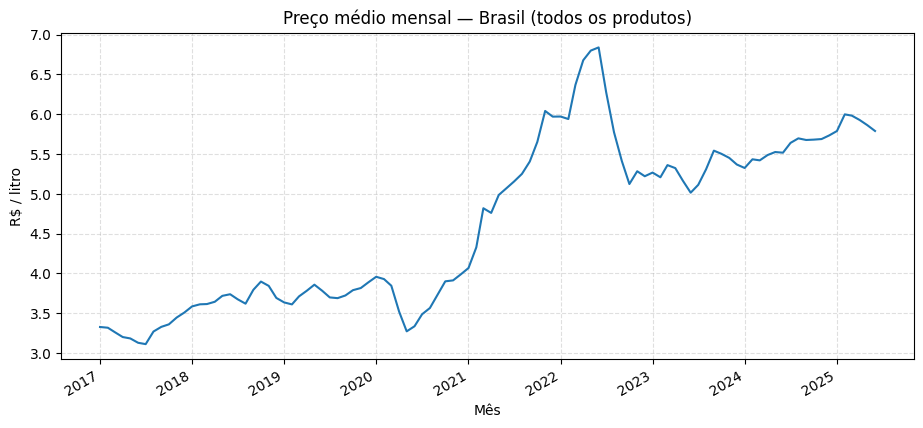

<Figure size 1100x500 with 0 Axes>

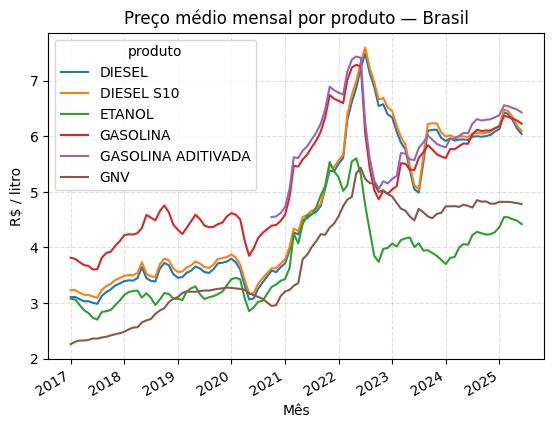

In [29]:
df["data_coleta"] = pd.to_datetime(df["data_coleta"], dayfirst=True, errors="coerce")

# valor_venda pode vir com vírgula decimal
df["valor_venda"] = pd.to_numeric(
    df["valor_venda"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

# 1) Criar "mes" (string YYYY-MM) e "mes_dt" (Timestamp no 1º dia do mês)
df["mes"] = df["data_coleta"].dt.to_period("M").astype(str)
df["mes_dt"] = pd.to_datetime(df["mes"] + "-01")

# 2) Agregações mensais (Brasil e por produto)
m_mensal_br = (
    df.groupby("mes_dt", as_index=True)["valor_venda"]
      .mean()
      .sort_index()
)

m_mensal_prod = (
    df.groupby(["mes_dt", "produto"])["valor_venda"]
      .mean()
      .unstack()
      .sort_index()
    if "produto" in df.columns else None
)

# 3) Tabela mensal (granularidade de mês) com métricas descritivas
tabela_mensal = (
    df.groupby("mes_dt")
      .agg(
          n=("valor_venda", "size"),
          media=("valor_venda", "mean"),
          mediana=("valor_venda", "median"),
          std=("valor_venda", "std"),
          p10=("valor_venda", lambda s: s.quantile(0.10)),
          p90=("valor_venda", lambda s: s.quantile(0.90)),
          iqr=("valor_venda", lambda s: s.quantile(0.75) - s.quantile(0.25)),
      )
      .assign(**{"cv_%": lambda d: np.where(d["media"].ne(0), d["std"] / d["media"] * 100, np.nan)})
      .reset_index()
      .rename(columns={"mes_dt": "mes"})
      .sort_values("mes")
)

# (opcional) Tabela mensal por produto
tabela_mensal_produto = (
    df.groupby(["mes_dt", "produto"])
      .agg(
          n=("valor_venda", "size"),
          media=("valor_venda", "mean"),
          mediana=("valor_venda", "median"),
          std=("valor_venda", "std"),
          p10=("valor_venda", lambda s: s.quantile(0.10)),
          p90=("valor_venda", lambda s: s.quantile(0.90)),
          iqr=("valor_venda", lambda s: s.quantile(0.75) - s.quantile(0.25)),
      )
      .assign(**{"cv_%": lambda d: np.where(d["media"].ne(0), d["std"] / d["media"] * 100, np.nan)})
      .reset_index()
      .rename(columns={"mes_dt": "mes"})
      .sort_values(["produto", "mes"])
    if "produto" in df.columns else None
)

# 4) Eventos (opcional, como no seu exemplo)
eventos = pd.DataFrame({
    "data": [
        # "2018-05", "2022-07", "2023-01", "2023-08"
    ],
    "descricao": [
        # "Greve dos caminhoneiros", "Mudanças tributárias/ICMS",
        # "Reoneração parcial PIS/Cofins", "Ajuste de preços na refinaria"
    ],
    "escopo": [
        # "Nacional", "Nacional", "Nacional", "Nacional"
    ],
    "produto_foco": [
        # "DIESEL", "GASOLINA", "GASOLINA", "DIESEL"
    ]
})

def to_period_date(s):
    if pd.isna(s): return pd.NaT
    s = str(s)
    try:
        if len(s) == 7:  # YYYY-MM
            return pd.to_datetime(s + "-01")
        else:
            return pd.to_datetime(s)
    except:
        return pd.NaT

if not eventos.empty:
    eventos["data"] = eventos["data"].apply(to_period_date)

# 5) Plot: média mensal Brasil
SAVE_FIGS = True
FIG_DIR = "figs_anp"
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(11, 4.8))
m_mensal_br.plot()
plt.title("Preço médio mensal — Brasil (todos os produtos)")
plt.xlabel("Mês"); plt.ylabel("R$ / litro"); plt.grid(True, linestyle="--", alpha=0.4)
if not eventos.empty:
    for _, r in eventos.dropna(subset=["data"]).iterrows():
        x = r["data"]
        plt.axvline(x, linestyle="--", alpha=0.4)
        plt.text(x, plt.ylim()[1], r["descricao"], rotation=90, va="top", ha="right", fontsize=9)
if SAVE_FIGS: plt.savefig(os.path.join(FIG_DIR, "mensal_brasil_eventos.png"), dpi=150, bbox_inches="tight")
plt.show()

# 6) Plot: média mensal por produto (se houver)
if m_mensal_prod is not None:
    plt.figure(figsize=(11, 5))
    m_mensal_prod.plot()
    plt.title("Preço médio mensal por produto — Brasil")
    plt.xlabel("Mês"); plt.ylabel("R$ / litro"); plt.grid(True, linestyle="--", alpha=0.4)
    if not eventos.empty:
        for _, r in eventos.dropna(subset=["data"]).iterrows():
            plt.axvline(r["data"], linestyle="--", alpha=0.4)
    if SAVE_FIGS: plt.savefig(os.path.join(FIG_DIR, "mensal_produtos_eventos.png"), dpi=150, bbox_inches="tight")
    plt.show()

# --- Exemplos de uso das tabelas ---
# print(tabela_mensal.head())
# if tabela_mensal_produto is not None: print(tabela_mensal_produto.head())


spread = intervalo interdecílico (interdecile range), uma medida de dispersão que pega a distância entre os percentis 90 e 10. 
Em economia, isso é uma forma de quantificar price dispersion (variação de preços para o mesmo produto em diferentes vendedores/regiões). Medidas usuais incluem faixa (máx–mín), p90–p10, desvio-padrão e coeficiente de variação. 

Os valores vêm do Levantamento de Preços de Combustíveis (LPC) da ANP (pesquisa semanal em postos). A metodologia de amostragem, roteiro de coleta e frequência estão descritos pela ANP. (https://www.gov.br/anp/pt-br/assuntos/precos-e-defesa-da-concorrencia/precos/composicao-e-estruturas-de-formacao-dos-precos)

p10: 10% mais baratos ficam abaixo desse preço.

p90: 10% mais caros ficam acima desse preço.

spread (p90–p10): largura do “miolo” central de 80% dos preços.

Exemplos rápidos (2017):

SP: p10=2,399; p90=3,699 → spread=1,300. Interpretação: 80% dos preços nos postos paulistas em 2017 ficaram dentro de um corredor de R$1,30/L.

MT: p10=2,399; p90=3,899 → spread=1,50 (maior dispersão que SP).
Em 2018, MT chega a 2,07 → heterogeneidade bem mais alta naquele ano/estado. (Maior spread = maior variação entre postos/localidades.)

O preço final reflete cadeia de custos e tributos (produção/importação, fretes até base e do distribuidor ao posto, margens, ICMS etc.). Diferenças de logística, estrutura concorrencial local e política tributária ajudam a explicar spreads distintos por estado e ao longo do tempo. (https://www.gov.br/anp/pt-br/assuntos/precos-e-defesa-da-concorrencia/precos/precos-revenda-e-de-distribuicao-combustiveis/informacoes-levantamento-de-precos-de-combustiveis)

aqui “spread” ≠ margem do posto/distribuidor; é dispersão entre preços observados. 

In [30]:
if "estado_sigla" in df.columns:
    spread_uf = df.groupby(["estado_sigla","ano"])["valor_venda"].agg(p10=lambda x: x.quantile(.10),
                                                                p90=lambda x: x.quantile(.90))
    spread_uf["spread"] = spread_uf["p90"] - spread_uf["p10"]
    display(spread_uf.reset_index().sort_values(["ano","spread"], ascending=[True, False]).head(30))

# Spread por Produto x Ano
if "produto" in df.columns:
    spread_prod = df.groupby(["produto","ano"])["valor_venda"].agg(p10=lambda x: x.quantile(.10),
                                                                   p90=lambda x: x.quantile(.90))
    spread_prod["spread"] = spread_prod["p90"] - spread_prod["p10"]
    display(spread_prod.reset_index().sort_values(["ano","spread"], ascending=[True, False]).head(30))

,estado_sigla,ano,p10,p90,spread
108,MT,2017,2.399,3.8990,1.5000
225,SP,2017,2.399,3.6990,1.3000
90,MG,2017,2.699,3.9590,1.2600
72,GO,2017,2.690,3.9400,1.2500
162,RJ,2017,2.899,4.1400,1.2410
198,RS,2017,2.899,4.0900,1.1910
153,PR,2017,2.660,3.8400,1.1800
117,PA,2017,3.189,4.3000,1.1110
18,AM,2017,3.100,4.2000,1.1000
234,TO,2017,2.900,3.9600,1.0600


,produto,ano,p10,p90,spread
18,ETANOL,2017,2.379,3.490,1.111
27,GASOLINA,2017,3.399,4.149,0.750
42,GNV,2017,1.999,2.699,0.700
0,DIESEL,2017,2.840,3.390,0.550
9,DIESEL S10,2017,2.959,3.499,0.540
19,ETANOL,2018,2.599,3.699,1.100
43,GNV,2018,2.199,3.199,1.000
28,GASOLINA,2018,3.999,4.899,0.900
1,DIESEL,2018,3.199,3.800,0.601
10,DIESEL S10,2018,3.299,3.899,0.600


10) Série mensal e anotações de eventos (opcional)

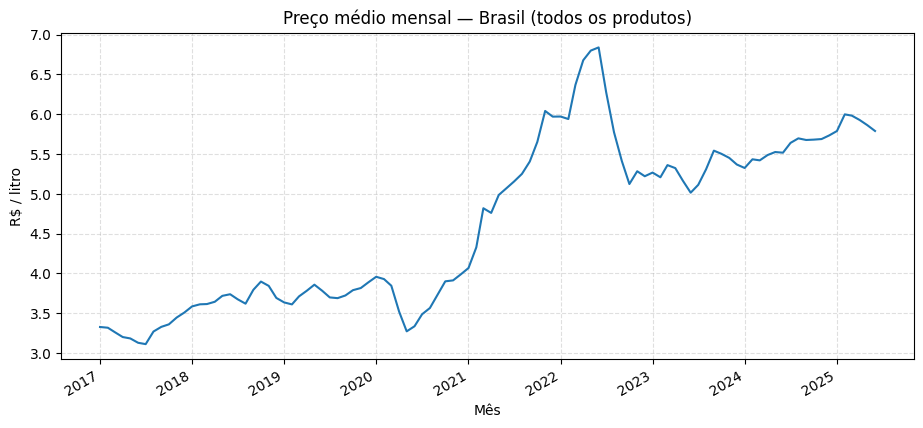

<Figure size 1100x500 with 0 Axes>

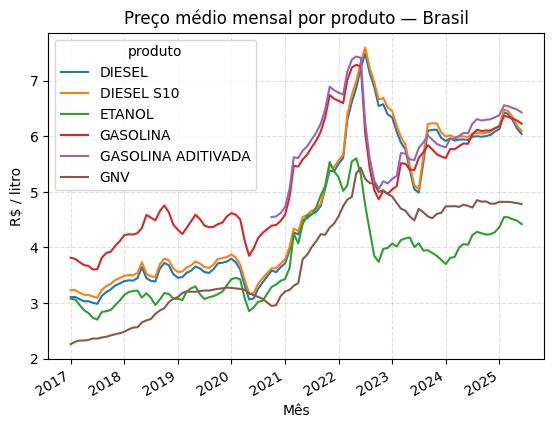

In [31]:
m_mensal_br = df.groupby("mes")["valor_venda"].mean().sort_index()
m_mensal_prod = df.groupby(["mes","produto"])["valor_venda"].mean().unstack() if "produto" in df.columns else None

# Tabela de eventos (edite livremente):
eventos = pd.DataFrame({
    # "YYYY-MM" ou "YYYY-MM-DD"
    "data": [
        # "2018-05",  # ex.: greve dos caminhoneiros
        # "2022-07",  # ex.: redução de ICMS / medidas federais
        # "2023-01",  # ex.: reinstalação parcial de tributos
        # "2023-08",  # ex.: variação de preço Petrobras
    ],
    "descricao": [
        # "Greve dos caminhoneiros",
        # "Mudanças tributárias/ICMS",
        # "Reoneração parcial PIS/Cofins",
        # "Ajuste de preços na refinaria",
    ],
    "escopo": [
        # "Nacional", "Estadual", "Nacional", "Nacional"
    ],
    "produto_foco": [
        # "DIESEL", "GASOLINA", "GASOLINA", "DIESEL"
    ]
})

# Converte col datas (aceita YYYY-MM)
def to_period_date(s):
    if pd.isna(s): return pd.NaT
    s = str(s)
    try:
        if len(s) == 7:  # YYYY-MM
            return pd.to_datetime(s + "-01")
        else:
            return pd.to_datetime(s)
    except:
        return pd.NaT

if not eventos.empty:
    eventos["data"] = eventos["data"].apply(to_period_date)

# Plot: média mensal Brasil (todos os produtos)
fig = plt.figure(figsize=(11,4.8))
m_mensal_br.index = pd.to_datetime(m_mensal_br.index + "-01")
m_mensal_br.sort_index().plot()
plt.title("Preço médio mensal — Brasil (todos os produtos)")
plt.xlabel("Mês"); plt.ylabel("R$ / litro"); plt.grid(True, linestyle="--", alpha=0.4)
# anotações
if not eventos.empty:
    for _, r in eventos.dropna(subset=["data"]).iterrows():
        x = r["data"]
        plt.axvline(x, linestyle="--", alpha=0.4)
        plt.text(x, plt.ylim()[1], r["descricao"], rotation=90, va="top", ha="right", fontsize=9)
if SAVE_FIGS: plt.savefig(os.path.join(FIG_DIR, "mensal_brasil_eventos.png"), dpi=150, bbox_inches="tight")
plt.show()

# Plot: média mensal por produto (se houver)
if m_mensal_prod is not None:
    m_mensal_prod.index = pd.to_datetime(m_mensal_prod.index + "-01")
    fig = plt.figure(figsize=(11,5))
    m_mensal_prod.sort_index().plot()
    plt.title("Preço médio mensal por produto — Brasil")
    plt.xlabel("Mês"); plt.ylabel("R$ / litro"); plt.grid(True, linestyle="--", alpha=0.4)
    if not eventos.empty:
        for _, r in eventos.dropna(subset=["data"]).iterrows():
            x = r["data"]
            plt.axvline(x, linestyle="--", alpha=0.4)
            # anotação uma vez no topo
    if SAVE_FIGS: plt.savefig(os.path.join(FIG_DIR, "mensal_produtos_eventos.png"), dpi=150, bbox_inches="tight")
    plt.show()

11) Outliers — marcações por Produto x Ano (IQR)

In [32]:
def flag_outliers_iqr(g, k=1.5):
    q1, q3 = g.quantile(0.25), g.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return (g < lo) | (g > hi)

if "produto" in df.columns:
    df["is_outlier"] = df.groupby(["produto","ano"])["valor_venda"].transform(flag_outliers_iqr)
    out_rate = df.groupby(["produto","ano"])["is_outlier"].mean().unstack().fillna(0)*100
    print("Taxa de outliers (%) por produto x ano:")
    display(out_rate.round(2))


Taxa de outliers (%) por produto x ano:


ano,2017,2018,2019,2020,2021,2022,2023,2024,2025
produto,,,,,,,,,
DIESEL,4.13,1.29,2.27,0.47,0.25,0.19,0.62,4.18,2.36
DIESEL S10,2.40,1.10,2.53,0.28,0.16,0.10,0.49,3.55,1.90
ETANOL,0.32,0.22,0.09,0.30,0.60,0.08,0.49,0.85,0.78
GASOLINA,1.18,0.14,0.12,0.16,0.11,0.00,1.39,2.28,1.89
GASOLINA ADITIVADA,0.00,0.00,0.00,0.94,0.49,0.00,1.05,2.30,1.71
GNV,0.05,0.13,0.29,0.30,0.16,1.63,1.74,3.99,3.43


12) Relatórios anuais (loop automático por ano)

ANO 2017


,n,media,mediana,std,cv_%,p10,p90,iqr
geral,788606.0,3.264,3.21,0.479,14.686,2.679,3.899,0.611


,n,media,mediana,std,cv_%,p10,p90,iqr
produto,,,,,,,,
GNV,12171.0,2.351,2.299,0.274,11.656,1.999,2.699,0.393
ETANOL,213853.0,2.897,2.890,0.424,14.624,2.379,3.490,0.592
DIESEL,143472.0,3.100,3.090,0.227,7.313,2.840,3.390,0.241
DIESEL S10,180110.0,3.218,3.199,0.228,7.085,2.959,3.499,0.270
GASOLINA,239000.0,3.772,3.790,0.291,7.718,3.399,4.149,0.370


,n,media,mediana,std,cv_%,p10,p90,iqr
bandeira,,,,,,,,
DINAMO,5.0,1.999,1.999,0.071,3.537,1.939,2.059,0.000
MERCOIL,4.0,2.739,2.739,0.624,22.765,2.199,3.279,1.080
PELIKANO,33.0,2.799,2.690,0.336,11.993,2.420,3.340,0.440
GP,32.0,2.829,2.669,0.448,15.845,2.369,3.499,0.541
RUMOS,2.0,2.879,2.879,0.863,29.964,2.391,3.367,0.610
TORRAO,349.0,2.910,2.899,0.502,17.261,2.249,3.499,0.800
D`MAIS,389.0,3.015,2.989,0.406,13.476,2.387,3.579,0.519
SULPETRO,69.0,3.023,2.779,0.378,12.501,2.648,3.619,0.750
PETRONAC,187.0,3.032,2.999,0.397,13.106,2.567,3.649,0.350


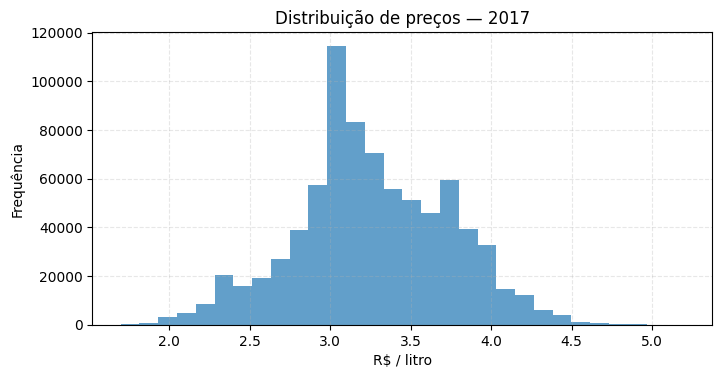

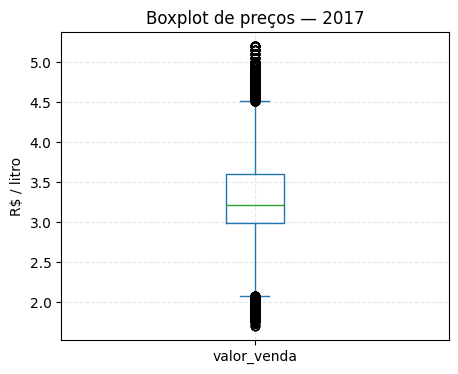

ANO 2018


,n,media,mediana,std,cv_%,p10,p90,iqr
geral,963002.0,3.703,3.599,0.628,16.967,2.899,4.599,0.861


,n,media,mediana,std,cv_%,p10,p90,iqr
produto,,,,,,,,
GNV,15024.0,2.731,2.699,0.384,14.052,2.199,3.199,0.591
ETANOL,258991.0,3.133,3.090,0.433,13.814,2.599,3.699,0.670
DIESEL,162342.0,3.503,3.490,0.248,7.067,3.199,3.800,0.331
DIESEL S10,231937.0,3.594,3.589,0.243,6.761,3.299,3.899,0.350
GASOLINA,294708.0,4.448,4.438,0.342,7.680,3.999,4.899,0.500


,n,media,mediana,std,cv_%,p10,p90,iqr
bandeira,,,,,,,,
DINAMO,6.0,2.422,2.349,0.292,12.060,2.149,2.769,0.385
TORRAO,249.0,3.261,3.190,0.642,19.697,2.439,4.119,1.150
PELIKANO,134.0,3.275,3.090,0.516,15.761,2.783,4.099,1.032
RM PETROLEO,213.0,3.299,3.219,0.602,18.237,2.483,4.137,1.160
GRAN PETRO,68.0,3.315,3.224,0.671,20.238,2.399,4.249,1.250
BREMEN,6.0,3.332,3.399,0.628,18.852,2.599,3.999,1.050
D`MAIS,533.0,3.422,3.418,0.549,16.048,2.698,4.199,0.950
STANG,1636.0,3.457,3.299,0.479,13.864,3.020,4.210,0.820
RUFF C.J.,467.0,3.468,3.430,0.591,17.028,2.699,4.289,1.100


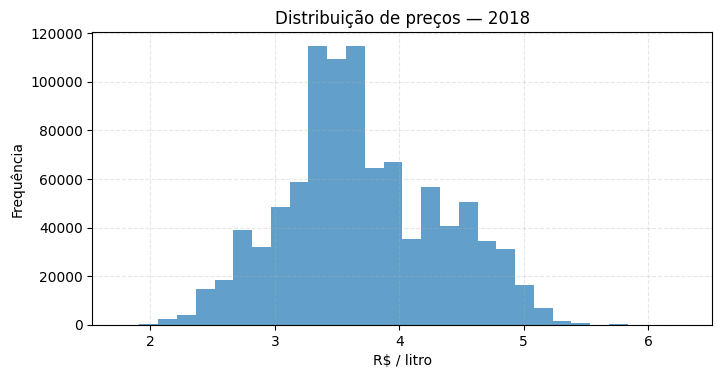

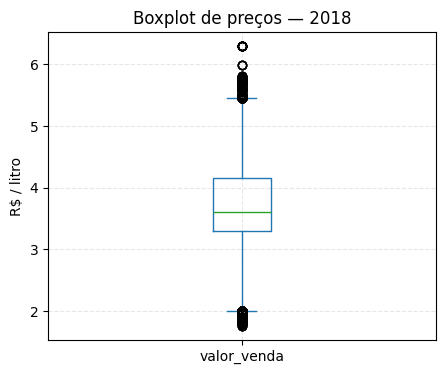

ANO 2019


,n,media,mediana,std,cv_%,p10,p90,iqr
geral,1004029.0,3.748,3.699,0.597,15.929,2.899,4.59,0.78


,n,media,mediana,std,cv_%,p10,p90,iqr
produto,,,,,,,,
ETANOL,271379.0,3.168,3.085,0.486,15.355,2.599,3.880,0.760
GNV,15801.0,3.216,3.197,0.330,10.261,2.799,3.685,0.500
DIESEL,162263.0,3.600,3.590,0.244,6.789,3.299,3.897,0.301
DIESEL S10,249503.0,3.691,3.690,0.234,6.340,3.399,3.980,0.271
GASOLINA,305083.0,4.419,4.399,0.320,7.245,3.999,4.850,0.469


,n,media,mediana,std,cv_%,p10,p90,iqr
bandeira,,,,,,,,
DINAMO,4.0,2.894,2.899,0.090,3.110,2.815,2.969,0.055
RM PETROLEO,36.0,3.170,3.224,0.623,19.645,2.448,3.800,1.250
REDE SOL,18.0,3.285,3.249,0.633,19.272,2.469,4.029,1.350
PELIKANO,397.0,3.345,3.279,0.468,14.004,2.741,4.015,0.860
GRAN PETRO,178.0,3.354,3.389,0.566,16.890,2.499,4.169,0.872
TORRAO,470.0,3.431,3.399,0.606,17.655,2.599,4.104,1.000
D`MAIS,659.0,3.440,3.468,0.523,15.218,2.649,4.099,1.035
ESTRADA,24.0,3.454,3.269,0.499,14.461,2.999,4.279,0.335
UNI,123.0,3.459,3.290,0.531,15.362,2.760,4.168,1.016


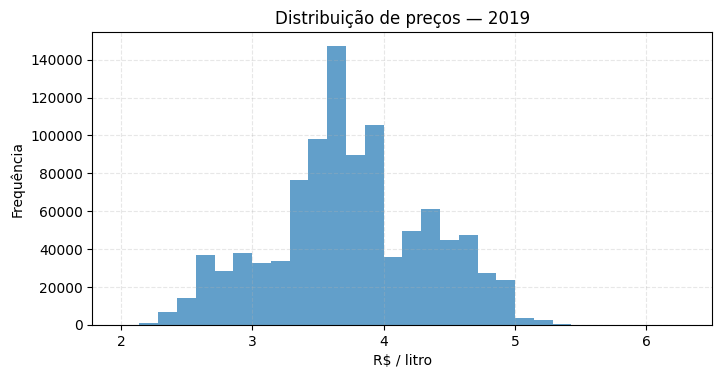

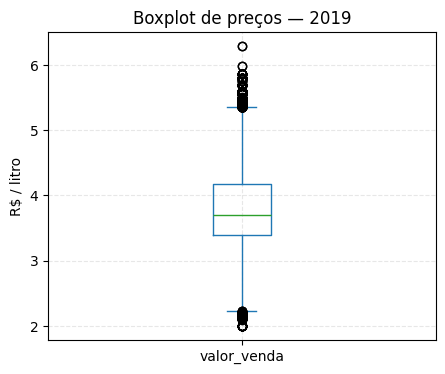

ANO 2020


,n,media,mediana,std,cv_%,p10,p90,iqr
geral,719300.0,3.654,3.609,0.625,17.101,2.899,4.499,0.889


,n,media,mediana,std,cv_%,p10,p90,iqr
produto,,,,,,,,
GNV,12475.0,3.169,3.099,0.316,9.973,2.799,3.630,0.450
ETANOL,190504.0,3.178,3.169,0.535,16.828,2.490,3.890,0.751
DIESEL,108750.0,3.418,3.399,0.360,10.526,2.959,3.879,0.541
DIESEL S10,177945.0,3.508,3.499,0.353,10.051,3.039,3.950,0.538
GASOLINA,214043.0,4.280,4.297,0.398,9.305,3.779,4.799,0.590
GASOLINA ADITIVADA,15583.0,4.588,4.590,0.322,7.014,4.189,4.999,0.410


,n,media,mediana,std,cv_%,p10,p90,iqr
bandeira,,,,,,,,
DINAMO,4.0,2.884,2.919,0.085,2.963,2.801,2.939,0.075
RM PETROLEO,20.0,3.107,3.224,0.682,21.941,2.199,4.007,1.200
GRAN PETRO,132.0,3.230,3.099,0.558,17.268,2.389,3.949,0.800
PELIKANO,212.0,3.282,3.259,0.473,14.407,2.689,4.053,0.473
D`MAIS,455.0,3.306,3.229,0.559,16.910,2.489,4.158,0.741
UNI,105.0,3.332,3.290,0.544,16.329,2.550,4.170,0.640
PETROLUZ,75.0,3.352,3.444,0.713,21.265,2.299,4.277,1.172
TORRAO,335.0,3.377,3.299,0.587,17.389,2.599,4.199,0.750
STANG,1311.0,3.408,3.310,0.502,14.713,2.790,4.219,0.740


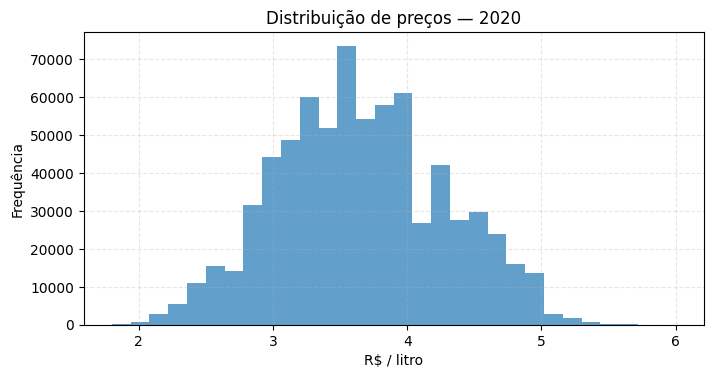

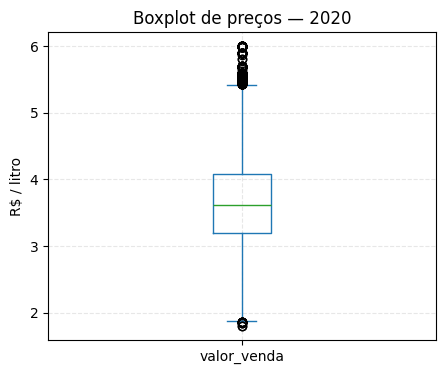

ANO 2021


,n,media,mediana,std,cv_%,p10,p90,iqr
geral,807537.0,5.238,5.199,0.926,17.689,4.09,6.499,1.359


,n,media,mediana,std,cv_%,p10,p90,iqr
produto,,,,,,,,
GNV,15787.0,3.889,3.950,0.600,15.416,2.999,4.599,0.940
ETANOL,182872.0,4.671,4.679,0.770,16.492,3.699,5.630,1.100
DIESEL,87905.0,4.694,4.647,0.543,11.574,3.999,5.400,0.759
DIESEL S10,164496.0,4.741,4.699,0.542,11.432,4.043,5.490,0.752
GASOLINA,204426.0,5.887,5.890,0.684,11.611,4.999,6.799,0.969
GASOLINA ADITIVADA,152051.0,6.037,5.999,0.687,11.381,5.159,6.950,0.900


,n,media,mediana,std,cv_%,p10,p90,iqr
bandeira,,,,,,,,
FEDERAL,21.0,4.181,4.170,0.597,14.284,3.490,4.990,0.950
PETROBRAS DISTRIBUIDORA S.A.,19532.0,4.296,4.259,0.677,15.747,3.399,5.190,1.053
TAG DISTRIBUIDORA,4.0,4.445,4.495,0.772,17.378,3.715,5.135,1.150
PELIKANO,70.0,4.600,4.454,0.868,18.867,3.397,5.679,1.270
TOBRAS,87.0,4.603,4.599,0.993,21.578,3.599,6.139,1.300
D`MAIS,45.0,4.791,4.588,0.580,12.104,4.086,5.478,1.099
UNI,135.0,4.931,5.090,0.769,15.601,3.990,5.974,1.005
RUFF C.J.,84.0,4.952,4.824,0.725,14.637,4.164,5.799,0.903
AMERICANOIL,707.0,5.046,4.999,0.853,16.914,3.999,6.069,1.200


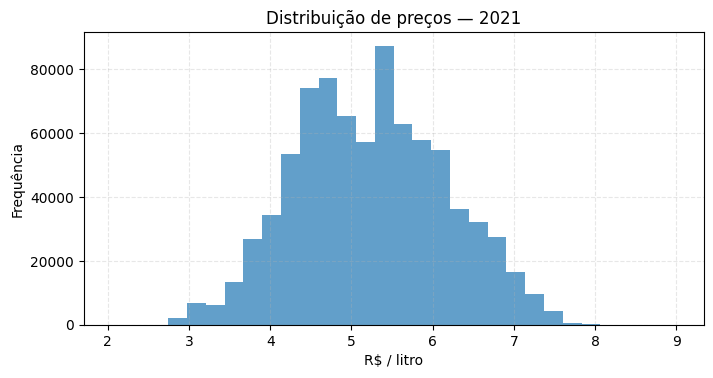

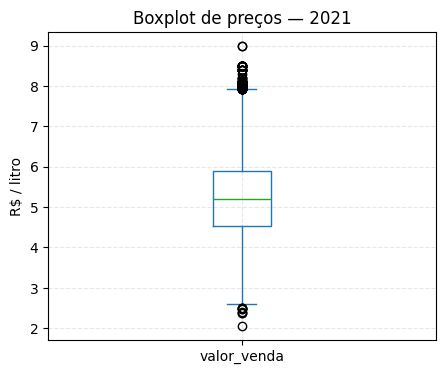

ANO 2022


,n,media,mediana,std,cv_%,p10,p90,iqr
geral,907502.0,6.118,6.29,1.137,18.584,4.59,7.49,1.74


,n,media,mediana,std,cv_%,p10,p90,iqr
produto,,,,,,,,
ETANOL,201350.0,4.852,4.86,0.873,18.004,3.69,5.99,1.300
GNV,17250.0,5.043,4.99,0.630,12.502,4.25,5.89,0.808
GASOLINA,228810.0,6.317,6.49,0.988,15.644,4.89,7.55,1.700
GASOLINA ADITIVADA,172855.0,6.472,6.67,0.983,15.183,5.09,7.69,1.690
DIESEL,102477.0,6.631,6.69,0.719,10.849,5.54,7.54,0.950
DIESEL S10,184760.0,6.734,6.79,0.730,10.835,5.59,7.64,0.970


,n,media,mediana,std,cv_%,p10,p90,iqr
bandeira,,,,,,,,
NACIONAL GÁS BUTANO,36.0,4.827,4.680,0.744,15.409,4.040,5.440,0.650
PETROBRASIL,24.0,4.832,4.590,1.193,24.693,3.490,6.390,2.900
BAHIANA,13.0,4.959,4.790,0.836,16.858,4.290,5.630,0.400
LIQUIGÁS,106.0,4.976,4.790,0.876,17.607,3.990,6.495,0.558
SUPERGASBRAS ENERGIA,44.0,5.087,4.970,0.818,16.082,4.059,6.525,0.705
ULTRAGAZ,27.0,5.113,4.990,1.144,22.376,3.550,6.654,1.125
D`MAIS,65.0,5.212,4.870,1.038,19.922,3.770,6.490,1.700
ON PETRO,16.0,5.318,5.250,0.933,17.549,4.150,6.570,0.955
AMAZONGÁS,13.0,5.687,5.300,1.246,21.911,4.210,7.390,2.000


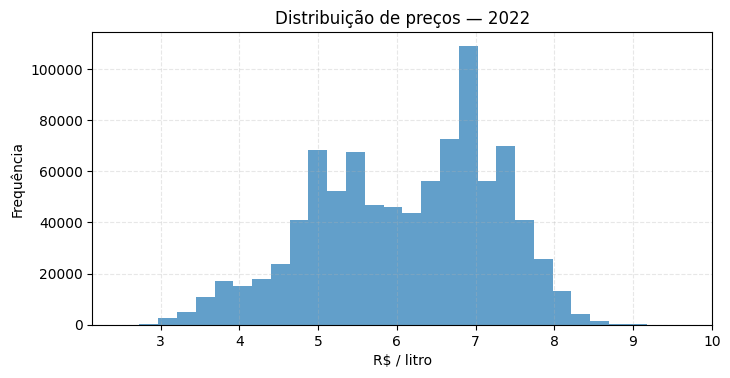

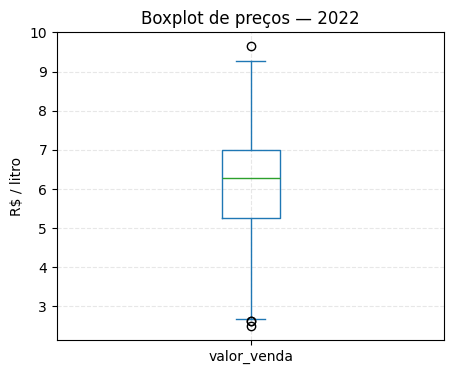

ANO 2023


,n,media,mediana,std,cv_%,p10,p90,iqr
geral,904000.0,5.302,5.49,0.877,16.547,3.89,6.29,1.1


,n,media,mediana,std,cv_%,p10,p90,iqr
produto,,,,,,,,
ETANOL,197849.0,4.005,3.98,0.520,12.982,3.39,4.69,0.79
GNV,18491.0,4.643,4.59,0.569,12.249,3.99,5.37,0.72
GASOLINA,232085.0,5.529,5.49,0.440,7.960,4.99,6.00,0.57
GASOLINA ADITIVADA,180978.0,5.711,5.69,0.443,7.751,5.16,6.28,0.60
DIESEL,106136.0,5.758,5.85,0.588,10.212,4.89,6.45,0.76
DIESEL S10,168461.0,5.860,5.98,0.605,10.329,4.99,6.59,0.81


,n,media,mediana,std,cv_%,p10,p90,iqr
bandeira,,,,,,,,
PETROBRASIL,106.0,4.610,4.890,0.858,18.610,3.390,5.690,1.500
TORRAO,4.0,4.745,4.945,0.829,17.474,3.975,5.355,0.525
FEDERAL ENERGIA,201.0,4.920,5.090,0.784,15.931,3.790,5.890,1.360
D`MAIS,480.0,5.003,5.190,0.838,16.746,3.562,5.890,0.800
TOTALENERGIES,1413.0,5.059,5.350,0.895,17.697,3.658,5.990,1.500
TDC DISTRIBUIDORA,524.0,5.061,5.160,0.716,14.143,3.990,5.950,1.113
ROYAL FIC,94.0,5.136,5.190,0.920,17.922,3.650,6.190,1.230
CIAPETRO,1129.0,5.136,5.390,0.899,17.507,3.690,6.008,1.300
STANG,2254.0,5.152,5.330,0.690,13.394,3.990,5.890,1.000


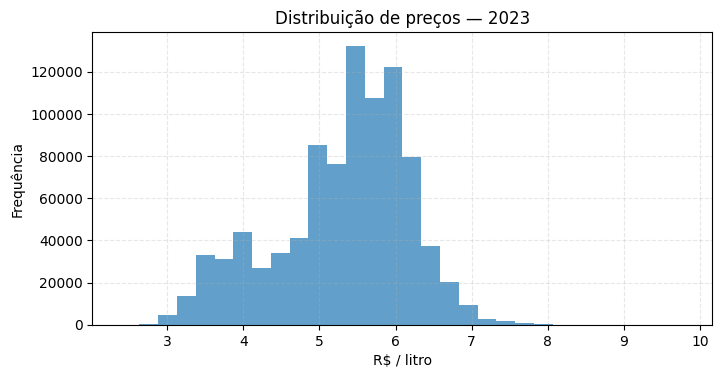

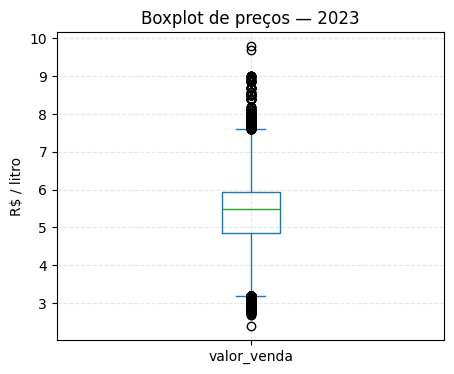

ANO 2024


,n,media,mediana,std,cv_%,p10,p90,iqr
geral,898536.0,5.559,5.86,0.919,16.529,3.99,6.39,0.87


,n,media,mediana,std,cv_%,p10,p90,iqr
produto,,,,,,,,
ETANOL,197306.0,4.068,3.99,0.513,12.615,3.43,4.74,0.70
GNV,18943.0,4.771,4.69,0.436,9.142,4.29,5.31,0.50
GASOLINA,233020.0,5.931,5.92,0.415,6.999,5.44,6.39,0.50
DIESEL,102581.0,5.972,5.89,0.372,6.233,5.59,6.44,0.41
DIESEL S10,166268.0,6.031,5.99,0.369,6.112,5.65,6.49,0.40
GASOLINA ADITIVADA,180418.0,6.120,6.09,0.421,6.885,5.59,6.59,0.50


,n,media,mediana,std,cv_%,p10,p90,iqr
bandeira,,,,,,,,
WATT,52.0,4.949,4.83,1.153,23.289,3.750,6.150,2.240
SIMARELLI,3.0,4.957,5.59,1.185,23.900,3.990,5.670,1.050
FEDERAL ENERGIA,259.0,5.165,5.54,0.740,14.333,4.090,5.922,1.365
D`MAIS,470.0,5.259,5.65,0.851,16.173,3.670,5.870,0.380
ROYAL FIC,189.0,5.338,5.69,0.936,17.535,3.650,6.080,0.560
STANG,1976.0,5.339,5.67,0.783,14.665,3.990,6.050,0.740
PETROBRASIL,12.0,5.353,5.79,0.778,14.527,4.272,5.980,1.525
TOTALENERGIES,2126.0,5.385,5.79,0.924,17.165,3.890,6.190,1.560
UNI,48.0,5.391,5.96,0.943,17.482,4.090,6.160,1.900


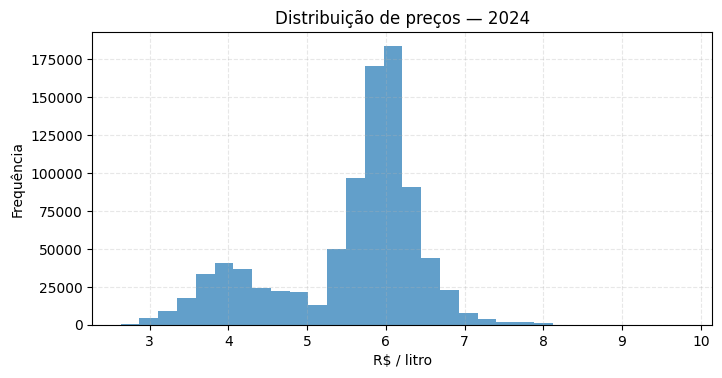

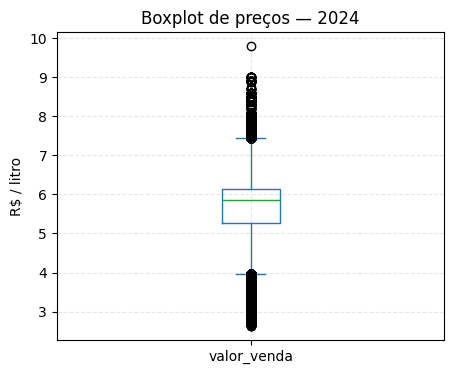

ANO 2025


,n,media,mediana,std,cv_%,p10,p90,iqr
geral,420409.0,5.891,6.17,0.893,15.163,4.39,6.76,0.9


,n,media,mediana,std,cv_%,p10,p90,iqr
produto,,,,,,,,
ETANOL,92598.0,4.478,4.47,0.459,10.245,3.89,4.990,0.65
GNV,9508.0,4.808,4.74,0.435,9.041,4.29,5.383,0.50
DIESEL,45771.0,6.239,6.19,0.400,6.409,5.79,6.760,0.48
GASOLINA,110818.0,6.288,6.28,0.405,6.445,5.85,6.770,0.50
DIESEL S10,76134.0,6.292,6.29,0.413,6.567,5.80,6.790,0.50
GASOLINA ADITIVADA,85580.0,6.483,6.49,0.410,6.322,5.99,6.940,0.48


,n,media,mediana,std,cv_%,p10,p90,iqr
bandeira,,,,,,,,
AMERICANOIL,1.0,4.920,4.92,NaN,NaN,4.920,4.920,0.000
WATT,44.0,5.166,5.08,1.079,20.880,3.990,6.290,2.140
PETROSERRA,64.0,5.468,5.70,0.602,11.009,4.390,5.990,0.535
PETROBRASIL,18.0,5.529,5.99,0.824,14.906,4.270,6.220,1.560
ROYAL FIC,120.0,5.597,5.85,0.966,17.264,3.790,6.554,0.500
D`MAIS,230.0,5.618,5.96,0.836,14.879,3.970,6.290,0.300
TOTALENERGIES,1188.0,5.674,6.09,0.885,15.598,4.290,6.480,1.700
SIM DISTRIBUIDOR,80.0,5.681,5.98,0.865,15.229,3.990,6.470,0.140
IDAZA,259.0,5.727,6.09,0.840,14.664,4.170,6.290,0.300


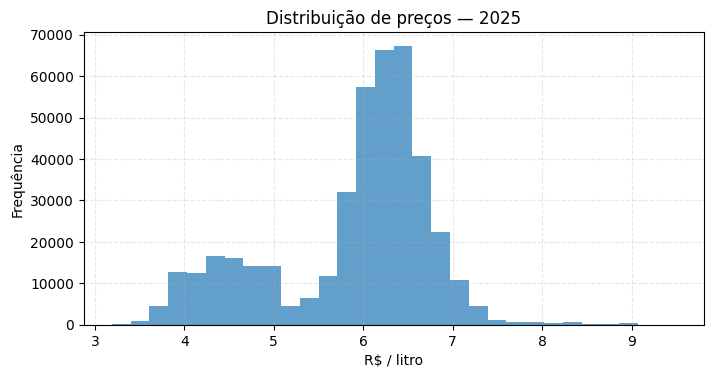

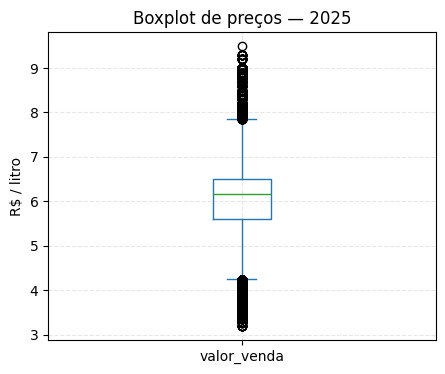

In [33]:
anos = sorted(df["ano"].dropna().unique().tolist())

for a in anos:
    print("="*80)
    print(f"ANO {a}")
    print("="*80)

    sub = df[df["ano"]==a]

    # 12.1 — resumo geral
    resumo = describe_group(sub["valor_venda"]).to_frame(name="geral").T
    display(resumo.round(3))

    # 12.2 — por produto
    if "produto" in sub.columns:
        tab = sub.groupby("produto")["valor_venda"].apply(describe_group).unstack()
        display(tab.round(3).sort_values("media"))

    # 12.3 — por bandeira
    if "bandeira" in sub.columns:
        tab = sub.groupby("bandeira")["valor_venda"].apply(describe_group).unstack()
        display(tab.round(3).sort_values("media"))

    # 12.4 — por região
    if "regiao" in sub.columns:
        tab = sub.groupby("regiao")["valor_venda"].apply(describe_group).unstack()
        display(tab.round(3).sort_values("media"))

    # 12.5 — por UF
    if "estado" in sub.columns:
        tab = sub.groupby("estado")["valor_venda"].apply(describe_group).unstack()
        display(tab.round(3).sort_values("media"))

    # 12.6 — gráfico: distribuição de preços (hist + box) do ano
    fig = plt.figure(figsize=(8,3.8))
    sub["valor_venda"].plot(kind="hist", bins=30, alpha=0.7)
    plt.title(f"Distribuição de preços — {a}")
    plt.xlabel("R$ / litro"); plt.ylabel("Frequência"); plt.grid(True, linestyle="--", alpha=0.3)
    if SAVE_FIGS: plt.savefig(os.path.join(FIG_DIR, f"hist_{a}.png"), dpi=150, bbox_inches="tight")
    plt.show()

    fig = plt.figure(figsize=(5,4))
    sub["valor_venda"].plot(kind="box")
    plt.title(f"Boxplot de preços — {a}")
    plt.ylabel("R$ / litro"); plt.grid(True, linestyle="--", alpha=0.3)
    if SAVE_FIGS: plt.savefig(os.path.join(FIG_DIR, f"box_{a}.png"), dpi=150, bbox_inches="tight")
    plt.show()

1) Imports, caminho dos dados e funções utilitárias

In [34]:
pip freeze


anyio==4.10.0
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.3.0
asttokens==3.0.0
async-lru==2.0.5
attrs==25.3.0
babel==2.17.0
beautifulsoup4==4.13.5
bleach==6.2.0
branca==0.8.1
certifi==2025.8.3
cffi==2.0.0
charset-normalizer==3.4.3
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.16
decorator==5.2.1
defusedxml==0.7.1
executing==2.2.1
fastjsonschema==2.21.2
folium==0.20.0
fonttools==4.59.2
fqdn==1.5.1
geobr==0.2.2
geopandas==1.1.0
h11==0.16.0
html5lib==1.1
httpcore==1.0.9
httpx==0.28.1
idna==3.10
ipykernel==6.30.1
ipython==9.5.0
ipython_pygments_lexers==1.1.1
isoduration==20.11.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.2
json5==0.12.1
jsonpointer==3.0.0
jsonschema==4.25.1
jsonschema-specifications==2025.9.1
jupyter-events==0.12.0
jupyter-lsp==2.3.0
jupyter_client==8.6.3
jupyter_core==5.8.1
jupyter_server==2.17.0
jupyter_server_terminals==0.5.3
jupyterlab==4.4.7
jupyterlab_pygments==0.3.0
jupyterlab_server==2.27.3
kiwisolver==1.4.9
lark==1.2.2
lxml==5.4.0
MarkupSafe==

In [35]:
import os, re, unicodedata, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

try:
    from geobr import read_state, read_municipality, read_region
except Exception as e:
    print("Falha ao importar geobr. Rode a célula de instalação e reinicie o kernel, se necessário.")
    raise

# Se você já tem o df limpo do notebook anterior, pule o carregamento abaixo
FILE_PATH = "dados_combustiveis.csv"   # ajuste se necessário

# -- Normalização de colunas e limpeza leve (compatível com seu notebook anterior) --
def normalize_cols(cols):
    out = []
    for c in cols:
        c = c.strip().lower()
        c = re.sub(r"[^\w]+", "_", c)
        c = re.sub(r"_+", "_", c).strip("_")
        out.append(c)
    return out

def parse_brl_to_float(x):
    if pd.isna(x): return np.nan
    s = str(x).replace("R$", "").replace(" ", "").strip()
    if "." in s and "," in s:
        s = s.replace(".", "").replace(",", ".")
    else:
        s = s.replace(",", ".")
    s = re.sub(r"[^0-9.\-]", "", s)
    try:
        return float(s)
    except:
        return np.nan

def strip_accents_upper(s):
    if pd.isna(s): return s
    s = str(s)
    s = unicodedata.normalize("NFKD", s).encode("ASCII", "ignore").decode("ASCII")
    return s.upper().strip()

# Mapeamento UF -> Região (caso sua coluna 'regiao' não exista)
UF_TO_REGION = {
    "AC":"NORTE","AM":"NORTE","AP":"NORTE","PA":"NORTE","RO":"NORTE","RR":"NORTE","TO":"NORTE",
    "AL":"NORDESTE","BA":"NORDESTE","CE":"NORDESTE","MA":"NORDESTE","PB":"NORDESTE","PE":"NORDESTE","PI":"NORDESTE","RN":"NORDESTE","SE":"NORDESTE",
    "DF":"CENTRO-OESTE","GO":"CENTRO-OESTE","MS":"CENTRO-OESTE","MT":"CENTRO-OESTE",
    "ES":"SUDESTE","MG":"SUDESTE","RJ":"SUDESTE","SP":"SUDESTE",
    "PR":"SUL","RS":"SUL","SC":"SUL"
}

2) Carregar dados e padronizar (ano, produto, regiao, estado, municipio)

In [36]:
if 'df' not in globals():
    ext = os.path.splitext(FILE_PATH)[1].lower()
    if ext in [".xlsx", ".xls"]:
        df = pd.read_excel(FILE_PATH, dtype=str)
    else:
        df = pd.read_csv(FILE_PATH, sep=None, engine="python", dtype=str)

df = df.copy()
df.columns = normalize_cols(df.columns)

# Renomeia colunas mais comuns
rename_map = {}
for a in ["regiao","regiao_sigla","sigla_regiao"]: 
    if a in df.columns: rename_map[a] = "regiao"
for a in ["estado","uf","estado_sigla","sigla_uf"]:
    if a in df.columns: rename_map[a] = "estado"
for a in ["municipio","municipiorevenda","municipio_revenda"]:
    if a in df.columns: rename_map[a] = "municipio"
for a in ["produto"]: 
    if a in df.columns: rename_map[a] = "produto"
for a in ["valor_venda","preco_venda","preco","preco_medio","valor_de_venda"]:
    if a in df.columns: rename_map[a] = "valor_venda"
for a in ["data_coleta","data","data_da_coleta"]:
    if a in df.columns: rename_map[a] = "data_coleta"
for a in ["bandeira","marca"]:
    if a in df.columns: rename_map[a] = "bandeira"
for a in ["ano"]:
    if a in df.columns: rename_map[a] = "ano"

df = df.rename(columns=rename_map)

# Tipos
if "valor_venda" in df.columns:
    df["valor_venda"] = df["valor_venda"].apply(parse_brl_to_float)

if "data_coleta" in df.columns:
    df["data_coleta"] = pd.to_datetime(df["data_coleta"], errors="coerce")
if "ano" not in df.columns or df["ano"].isna().all():
    df["ano"] = df["data_coleta"].dt.year

# Normalizações de chaves
for c in ["produto","regiao","estado","municipio","bandeira"]:
    if c in df.columns:
        df[c] = df[c].apply(strip_accents_upper)

# Garante REGIAO se não houver
if "regiao" not in df.columns and "estado" in df.columns:
    df["regiao"] = df["estado"].map(UF_TO_REGION)

# Garante UF com 2 letras
if "estado" in df.columns:
    df["estado"] = df["estado"].str[:2]  # se veio "SP - SAO PAULO", pega "SP"

# Tira ausentes críticos
df = df[~df["valor_venda"].isna()]
df = df[~df["ano"].isna()]
df["ano"] = df["ano"].astype(int, errors="ignore")

print("Anos:", sorted(df["ano"].unique()))
if "produto" in df.columns:
    print("Produtos (amostra):", sorted(df["produto"].unique())[:10])

Anos: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Produtos (amostra): ['DIESEL', 'DIESEL S10', 'ETANOL', 'GASOLINA', 'GASOLINA ADITIVADA', 'GNV']


3) Carregar shapes do IBGE (Região, UF, Município)

In [37]:
SHAPE_YEAR = 2020

gdf_reg = read_region(year=SHAPE_YEAR)      # colunas usuais: code_region, name_region
gdf_uf  = read_state(year=SHAPE_YEAR)       # colunas: code_state, name_state, abbrev_state
gdf_mun = read_municipality(year=SHAPE_YEAR)# colunas: code_muni, name_muni, code_state

# Padroniza nomes para join
gdf_reg["REGIAO"] = gdf_reg["name_region"].apply(strip_accents_upper)
gdf_uf["UF"]      = gdf_uf["abbrev_state"].apply(strip_accents_upper)
gdf_mun["UF"]     = gdf_mun["code_state"].map(dict(zip(gdf_uf["code_state"], gdf_uf["UF"])))
gdf_mun["MUNIC"]  = gdf_mun["name_muni"].apply(strip_accents_upper)

# Garantir CRS comum
gdf_reg = gdf_reg.to_crs(4674)  # SIRGAS 2000
gdf_uf  = gdf_uf.to_crs(4674)
gdf_mun = gdf_mun.to_crs(4674)


4) Agregações de preço (Região, UF, Município)

In [38]:
df_use = df.dropna(subset=["ano", "produto", "valor_venda"])

# Região
if "regiao" in df_use.columns:
    agg_reg = (df_use.groupby(["ano","produto","regiao"])["valor_venda"]
                      .agg(media="mean", n="count")
                      .reset_index())
else:
    raise ValueError("Coluna 'regiao' ausente e não foi possível derivar. Verifique a etapa 2.")

# UF
if "estado" in df_use.columns:
    agg_uf = (df_use.groupby(["ano","produto","estado"])["valor_venda"]
                    .agg(media="mean", n="count")
                    .reset_index())
else:
    raise ValueError("Coluna 'estado' (UF) ausente. Verifique a etapa 2.")

# Município (aninhado por UF) — pode ser pesado, filtrar depois por UF/ano/produto
if all(c in df_use.columns for c in ["estado","municipio"]):
    agg_mun = (df_use.groupby(["ano","produto","estado","municipio"])["valor_venda"]
                      .agg(media="mean", n="count")
                      .reset_index())
    # chaves normalizadas para join com shape
    agg_mun["UF"] = agg_mun["estado"].apply(strip_accents_upper)
    agg_mun["MUNIC"] = agg_mun["municipio"].apply(strip_accents_upper)
else:
    agg_mun = None


5) Funções de plot de mapas (um mapa por figura)

In [39]:
def map_regiao(year:int, produto:str, legend=True, save=False, outdir="figs"):
    """Mapa por REGIÃO para um ano e produto."""
    os.makedirs(outdir, exist_ok=True)
    sub = agg_reg[(agg_reg["ano"]==year) & (agg_reg["produto"]==strip_accents_upper(produto))].copy()
    if sub.empty:
        print(f"Sem dados para {year} / {produto}.")
        return
    sub["REGIAO"] = sub["regiao"].apply(strip_accents_upper)
    g = gdf_reg.merge(sub, on="REGIAO", how="left")
    fig = plt.figure(figsize=(7,7))
    ax = g.plot(column="media", legend=legend)
    plt.title(f"Preço médio (R$/L) — REGIÕES — {produto} — {year}")
    plt.axis("off")
    if save:
        plt.savefig(os.path.join(outdir, f"mapa_regiao_{produto}_{year}.png"), dpi=150, bbox_inches="tight")
    plt.show()

def map_uf(year:int, produto:str, legend=True, save=False, outdir="figs"):
    """Mapa por UF (estado) para um ano e produto."""
    os.makedirs(outdir, exist_ok=True)
    sub = agg_uf[(agg_uf["ano"]==year) & (agg_uf["produto"]==strip_accents_upper(produto))].copy()
    if sub.empty:
        print(f"Sem dados para {year} / {produto}.")
        return
    sub["UF"] = sub["estado"].apply(strip_accents_upper).str[:2]
    g = gdf_uf.merge(sub, on="UF", how="left")
    fig = plt.figure(figsize=(7.8,7.8))
    ax = g.plot(column="media", legend=legend)
    plt.title(f"Preço médio (R$/L) — ESTADOS — {produto} — {year}")
    plt.axis("off")
    if save:
        plt.savefig(os.path.join(outdir, f"mapa_uf_{produto}_{year}.png"), dpi=150, bbox_inches="tight")
    plt.show()

def map_municipios(uf:str, year:int, produto:str, legend=True, save=False, outdir="figs"):
    """Mapa municipal DENTRO de uma UF para um ano/produto."""
    if agg_mun is None:
        print("Dados municipais não disponíveis (faltou 'municipio' na base).")
        return
    os.makedirs(outdir, exist_ok=True)
    uf = strip_accents_upper(uf)[:2]
    sub = agg_mun[(agg_mun["ano"]==year) & 
                  (agg_mun["produto"]==strip_accents_upper(produto)) &
                  (agg_mun["UF"]==uf)].copy()
    if sub.empty:
        print(f"Sem dados municipais para {uf} / {year} / {produto}.")
        return
    # Filtra o shape municipal para a UF selecionada
    g_shape = gdf_mun[gdf_mun["UF"]==uf][["MUNIC","geometry"]].copy()
    # Join por nome normalizado (pode haver sobras sem match)
    g = g_shape.merge(sub[["MUNIC","media","n"]], on="MUNIC", how="left")
    fig = plt.figure(figsize=(7.8,7.8))
    ax = g.plot(column="media", legend=legend)
    plt.title(f"Preço médio (R$/L) — MUNICÍPIOS de {uf} — {produto} — {year}")
    plt.axis("off")
    if save:
        fname = f"mapa_municipios_{uf}_{produto}_{year}.png"
        plt.savefig(os.path.join(outdir, fname), dpi=150, bbox_inches="tight")
    plt.show()


In [40]:
df.head(5)

,regiao,estado,municipio,revenda,cnpj_revenda,rua,bairro,cep,produto,data_coleta,valor_venda,unidade_medida,bandeira,ano,mes,mes_dt,is_outlier
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,JARDIM ZULMIRA,18061-000,GASOLINA,2023-07-03,4.87,R$ / litro,BRANCA,2023,2023-07,2023-07-01,False
1,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,JARDIM ZULMIRA,18061-000,DIESEL S10,2023-07-03,4.88,R$ / litro,BRANCA,2023,2023-07,2023-07-01,False
2,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,JARDIM ZULMIRA,18061-000,ETANOL,2023-07-03,3.27,R$ / litro,BRANCA,2023,2023-07,2023-07-01,False
3,N,AC,CRUZEIRO DO SUL,CARDINAL E OLIVEIRA LTDA,03.608.766/0006-56,AVENIDA 25 DE AGOSTO,25 DE AGOSTO,69980-000,GASOLINA,2023-07-03,6.95,R$ / litro,VIBRA ENERGIA,2023,2023-07,2023-07-01,True
4,N,AC,CRUZEIRO DO SUL,CARDINAL E OLIVEIRA LTDA,03.608.766/0006-56,AVENIDA 25 DE AGOSTO,25 DE AGOSTO,69980-000,DIESEL S10,2023-07-03,6.85,R$ / litro,VIBRA ENERGIA,2023,2023-07,2023-07-01,False


In [41]:
def _norm_text(s: str) -> str:
    """Normaliza texto para comparação: maiúsculas, sem acento, sem espaços extras."""
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return ""
    s = str(s).strip().upper()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = " ".join(s.split())
    return s

def _mk_capital_lookup(capitais_map: dict) -> dict:
    """Cria mapeamento UF->capital normalizados (para comparação robusta)."""
    return { _norm_text(uf): _norm_text(cidade) for uf, cidade in capitais_map.items() if cidade }

# ========= 2) Dicionário de capitais (edite à vontade) =========
CAPITAIS_BR = {
    "AC": "Rio Branco",       "AL": "Maceió",        "AM": "Manaus",         "AP": "Macapá",
    "BA": "Salvador",         "CE": "Fortaleza",     "DF": "Brasília",       "ES": "Vitória",
    "GO": "Goiânia",          "MA": "São Luís",      "MG": "Belo Horizonte", "MS": "Campo Grande",
    "MT": "Cuiabá",           "PA": "Belém",         "PB": "João Pessoa",    "PE": "Recife",
    "PI": "Teresina",         "PR": "Curitiba",      "RJ": "Rio de Janeiro", "RN": "Natal",
    "RO": "Porto Velho",      "RR": "Boa Vista",     "RS": "Porto Alegre",   "SC": "Florianópolis",
    "SE": "Aracaju",          "SP": "São Paulo",     "TO": "Palmas",
}
CAP_LOOKUP = _mk_capital_lookup(CAPITAIS_BR)

# ========= 3) Detecta nomes de colunas no seu df =========
def pick_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Nenhuma das colunas esperadas foi encontrada: {candidates}")

# De acordo com sua amostra:
COL_UF   = pick_col(df, ["estado", "Estado - Sigla", "estado_sigla", "UF"])
COL_MUN  = pick_col(df, ["municipio", "Municipio"])
COL_DATA = pick_col(df, ["data_coleta", "Data da Coleta"])
COL_PRECO= pick_col(df, ["valor_venda", "Valor de Venda"])

# ========= 4) Normaliza e marca capitais =========
df["_uf_norm"]  = df[COL_UF].map(_norm_text)
df["_mun_norm"] = df[COL_MUN].map(_norm_text)

def _is_capital_row(uf_norm, mun_norm) -> bool:
    cap = CAP_LOOKUP.get(uf_norm, "")
    return (cap != "") and (mun_norm == cap)

df["is_capital"] = np.vectorize(_is_capital_row)(df["_uf_norm"], df["_mun_norm"])

# ========= 5) Subconjuntos para mapas/plots =========
# A) Agregado por ESTADO (ex.: mediana de preço)
df_estados = (
    df.groupby(COL_UF, as_index=False)
      .agg(n=(COL_PRECO, "size"),
           mediana_preco=(COL_PRECO, "median"))
      .sort_values(COL_UF)
)

# B) Apenas registros das CAPITAIS (para pontos/curvas específicas)
cols_keep = [COL_UF, COL_MUN, COL_DATA, COL_PRECO, "is_capital"]
df_capitais = df.loc[df["is_capital"], [c for c in cols_keep if c in df.columns]].copy()

# ========= 6) Amostras de verificação =========
print("Capitais (amostra):")
print(df_capitais.head(10))
print("\nAgregado por estado (mediana):")
print(df_estados.head(10))


Capitais (amostra):
   estado   municipio data_coleta  valor_venda  is_capital
10     AC  RIO BRANCO  2023-07-05         6.29        True
11     AC  RIO BRANCO  2023-07-05         6.29        True
12     AC  RIO BRANCO  2023-07-05         5.96        True
13     AC  RIO BRANCO  2023-07-05         5.99        True
14     AC  RIO BRANCO  2023-07-05         4.59        True
15     AC  RIO BRANCO  2023-07-05         6.22        True
16     AC  RIO BRANCO  2023-07-05         6.29        True
17     AC  RIO BRANCO  2023-07-05         5.75        True
18     AC  RIO BRANCO  2023-07-05         5.85        True
19     AC  RIO BRANCO  2023-07-05         6.26        True

Agregado por estado (mediana):
  estado       n  mediana_preco
0     AC   46763          4.990
1     AL   81941          4.690
2     AM   85428          4.730
3     AP   21276          4.589
4     BA  423814          4.510
5     CE  262272          4.629
6     DF   68659          4.680
7     ES  144862          4.590
8     GO  2

<Figure size 780x780 with 0 Axes>

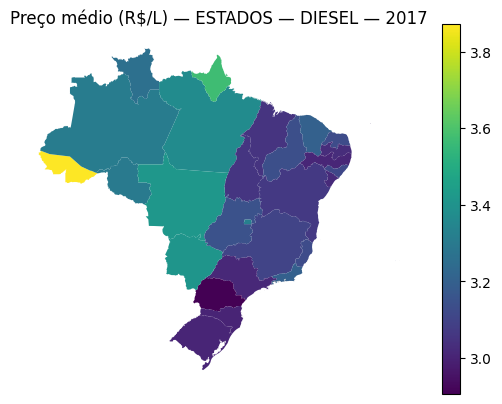

<Figure size 780x780 with 0 Axes>

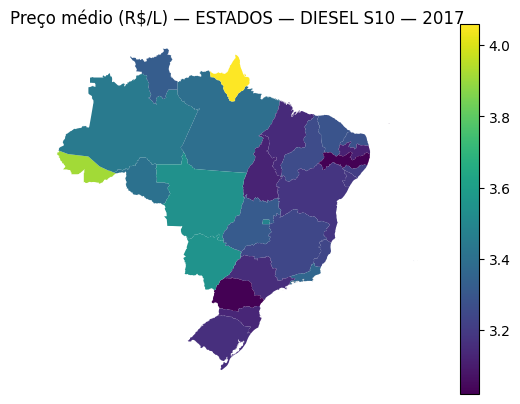

<Figure size 780x780 with 0 Axes>

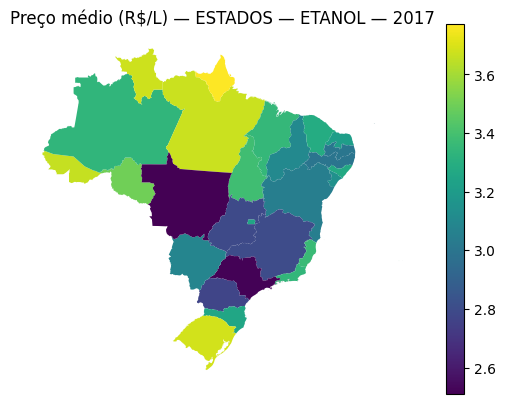

<Figure size 780x780 with 0 Axes>

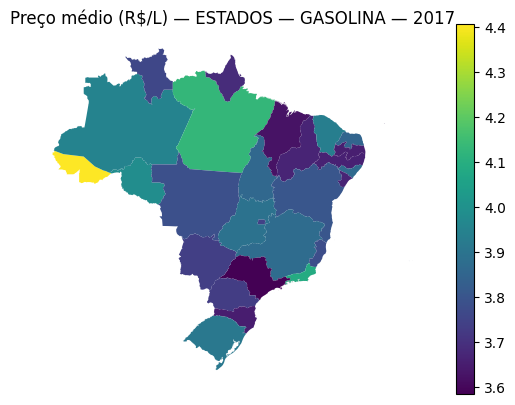

Sem dados para 2017 / GASOLINA ADITIVADA.


<Figure size 780x780 with 0 Axes>

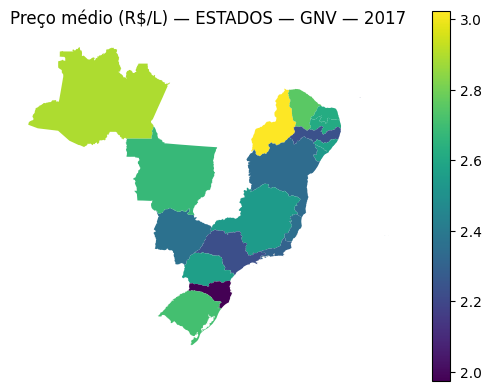

<Figure size 780x780 with 0 Axes>

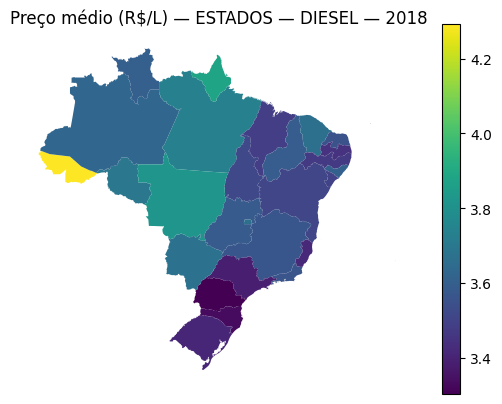

<Figure size 780x780 with 0 Axes>

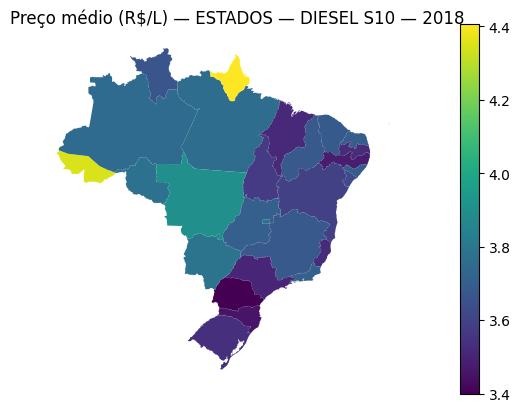

<Figure size 780x780 with 0 Axes>

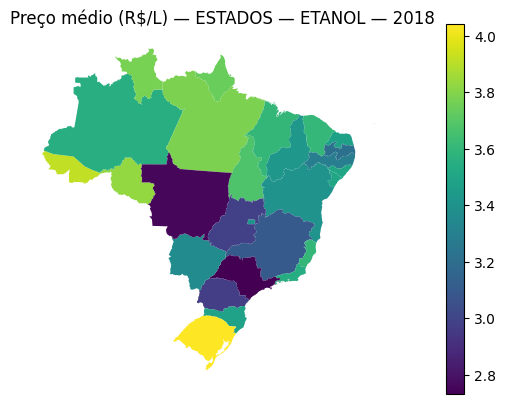

<Figure size 780x780 with 0 Axes>

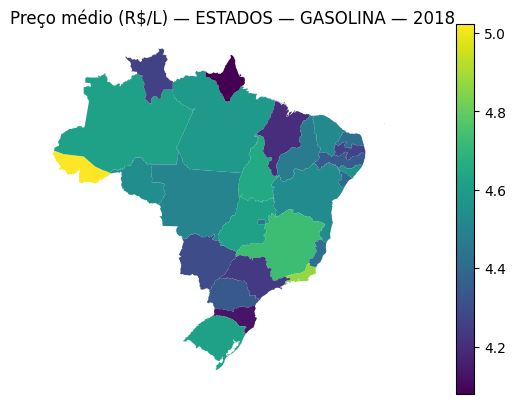

Sem dados para 2018 / GASOLINA ADITIVADA.


<Figure size 780x780 with 0 Axes>

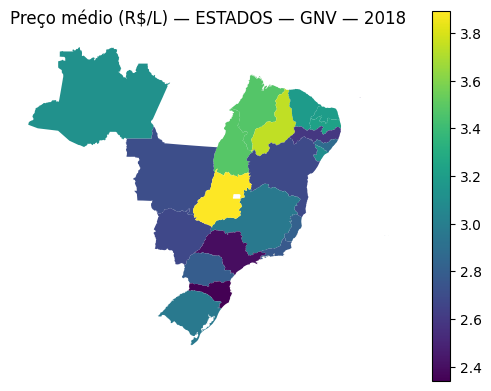

<Figure size 780x780 with 0 Axes>

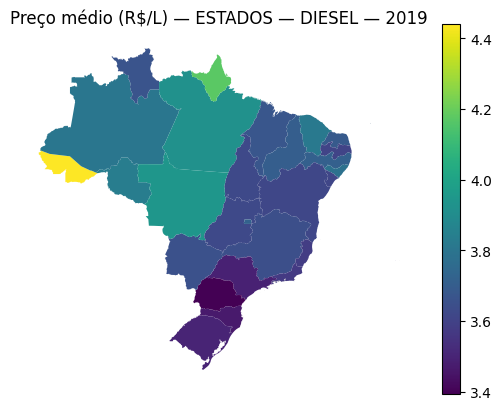

<Figure size 780x780 with 0 Axes>

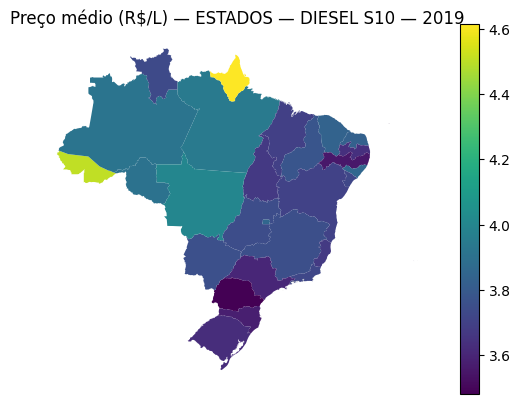

<Figure size 780x780 with 0 Axes>

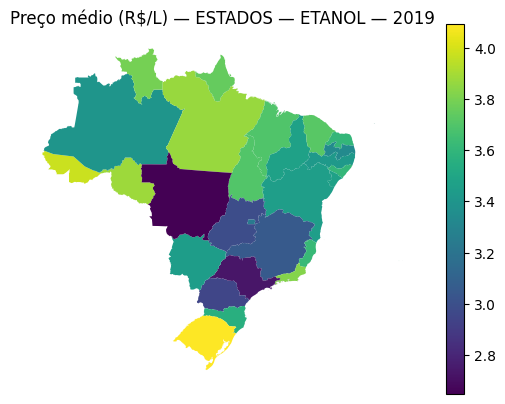

<Figure size 780x780 with 0 Axes>

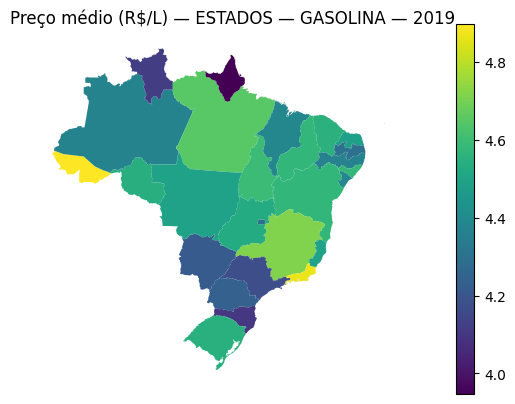

Sem dados para 2019 / GASOLINA ADITIVADA.


<Figure size 780x780 with 0 Axes>

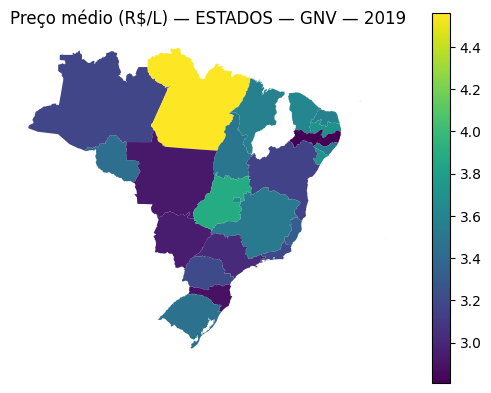

<Figure size 780x780 with 0 Axes>

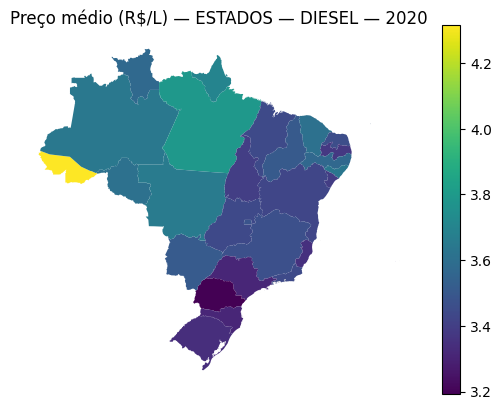

<Figure size 780x780 with 0 Axes>

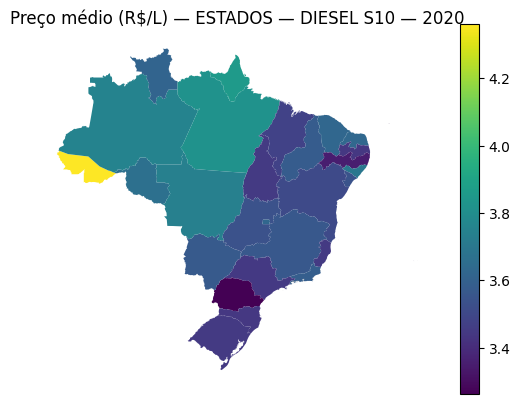

<Figure size 780x780 with 0 Axes>

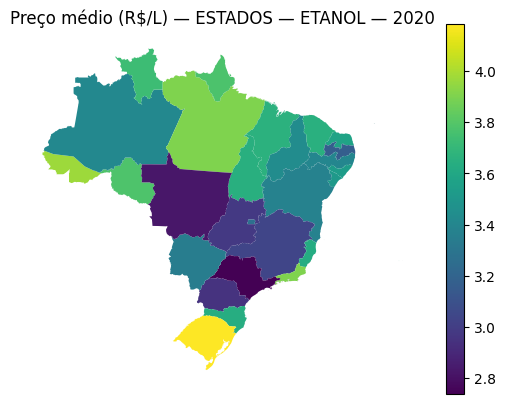

<Figure size 780x780 with 0 Axes>

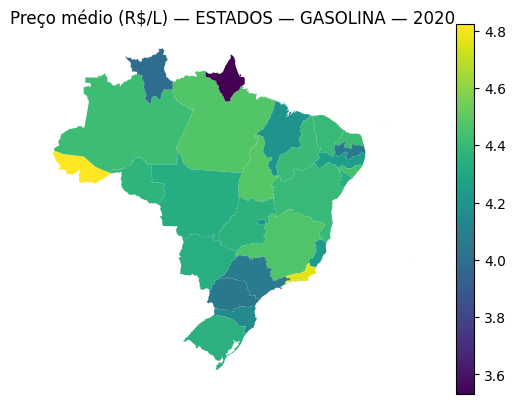

<Figure size 780x780 with 0 Axes>

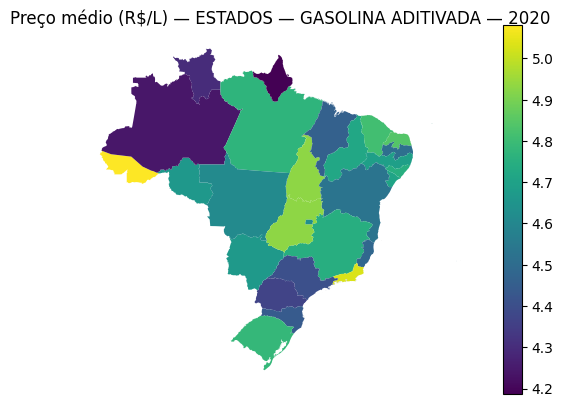

<Figure size 780x780 with 0 Axes>

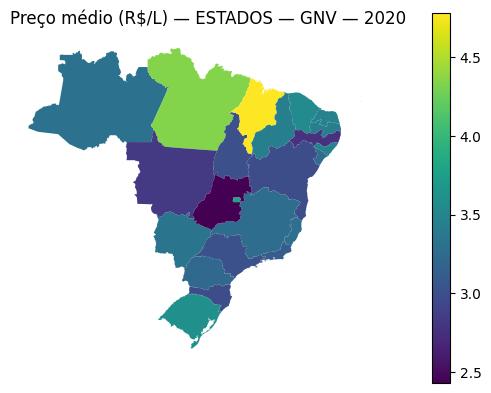

<Figure size 780x780 with 0 Axes>

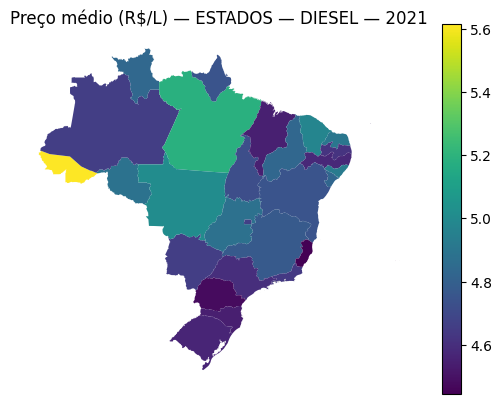

<Figure size 780x780 with 0 Axes>

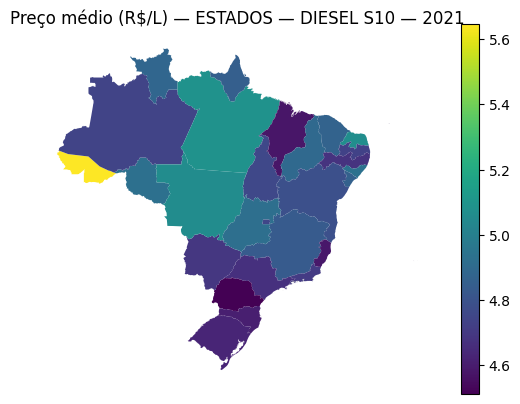

<Figure size 780x780 with 0 Axes>

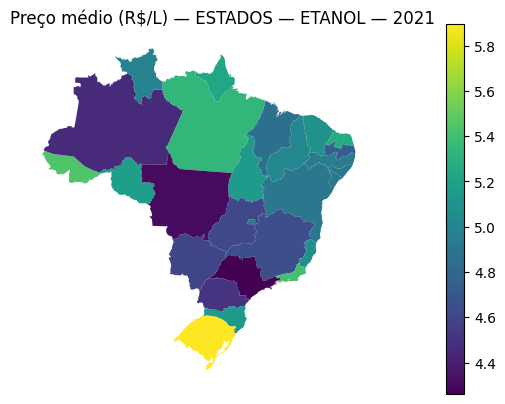

<Figure size 780x780 with 0 Axes>

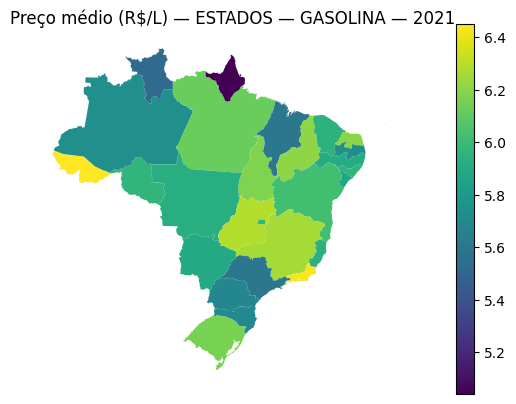

<Figure size 780x780 with 0 Axes>

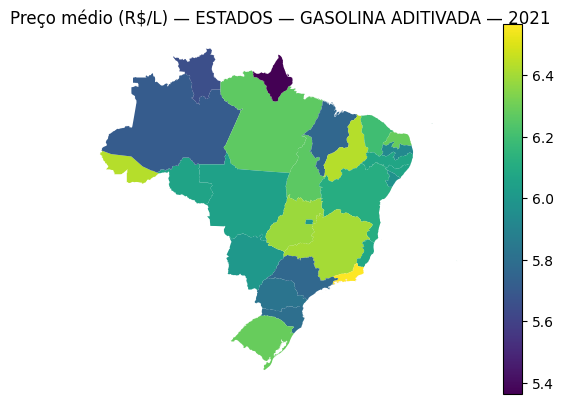

<Figure size 780x780 with 0 Axes>

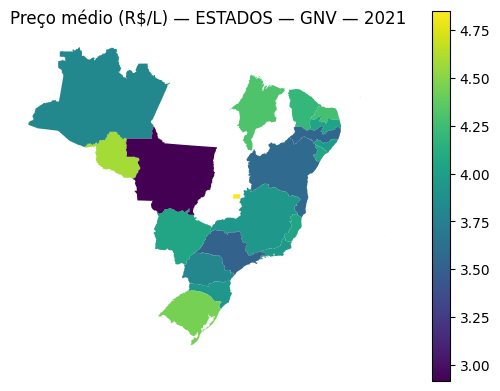

<Figure size 780x780 with 0 Axes>

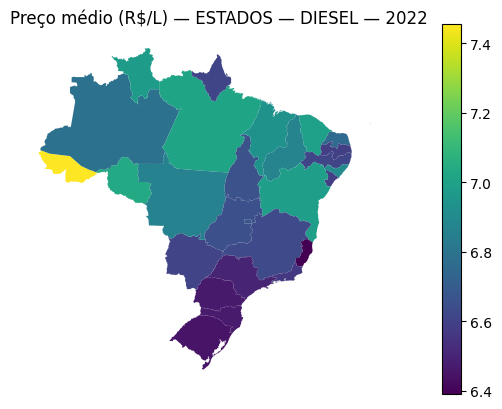

<Figure size 780x780 with 0 Axes>

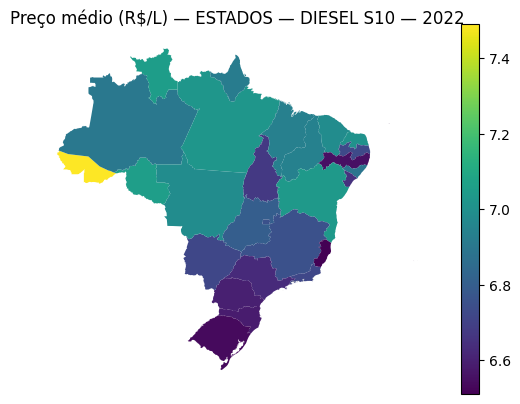

<Figure size 780x780 with 0 Axes>

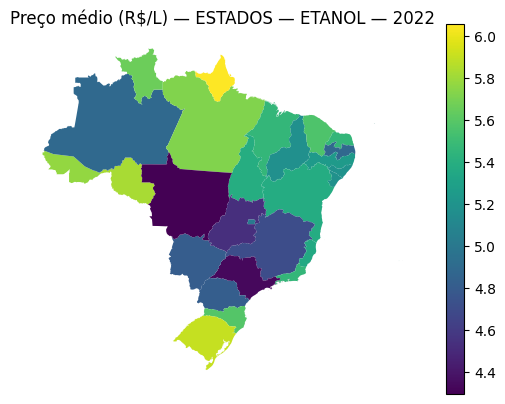

<Figure size 780x780 with 0 Axes>

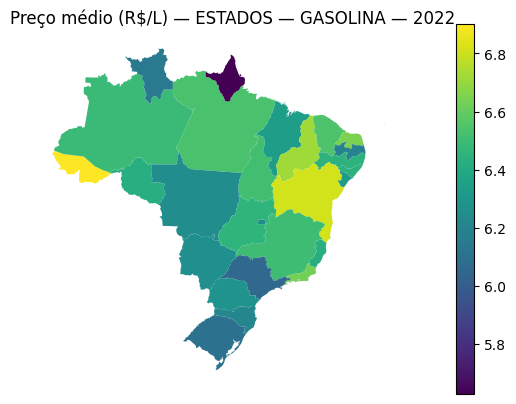

<Figure size 780x780 with 0 Axes>

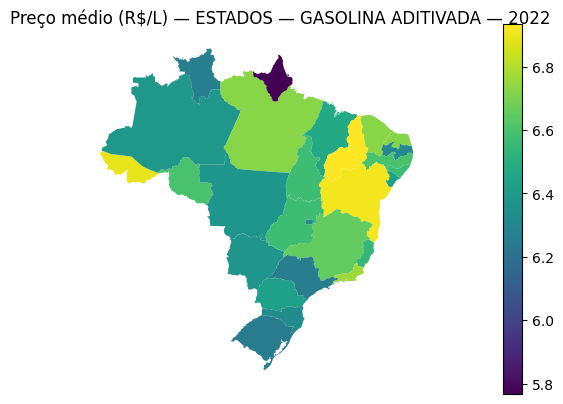

<Figure size 780x780 with 0 Axes>

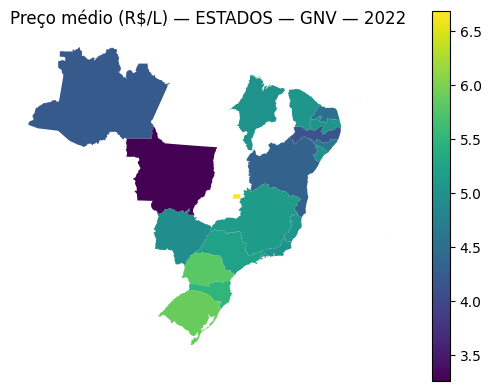

<Figure size 780x780 with 0 Axes>

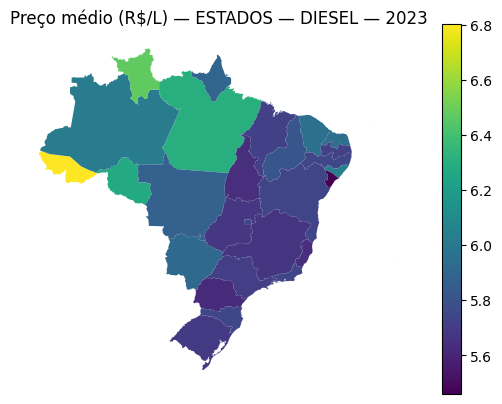

<Figure size 780x780 with 0 Axes>

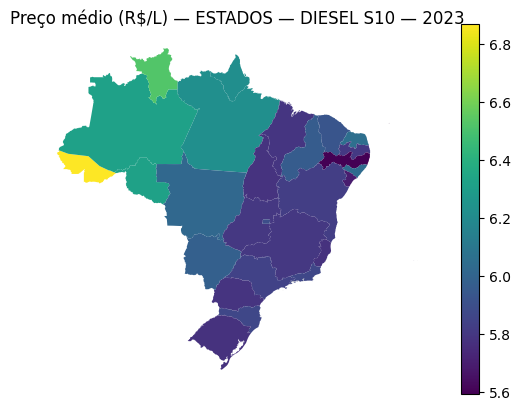

<Figure size 780x780 with 0 Axes>

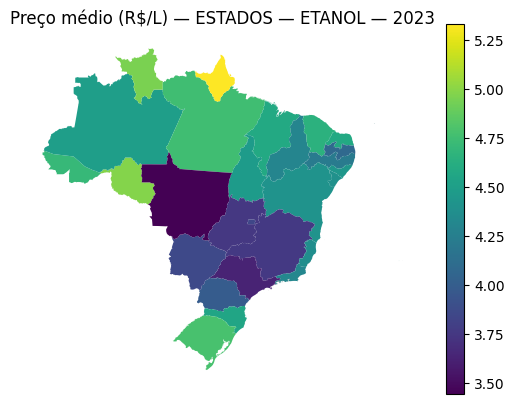

<Figure size 780x780 with 0 Axes>

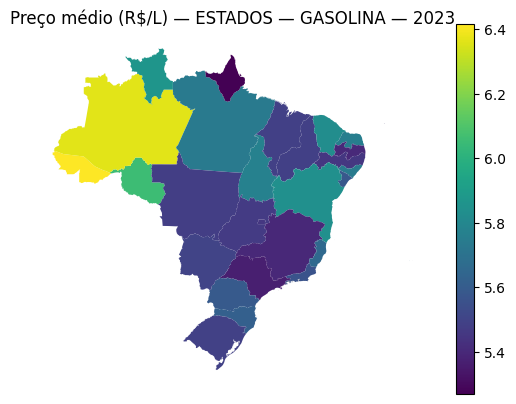

<Figure size 780x780 with 0 Axes>

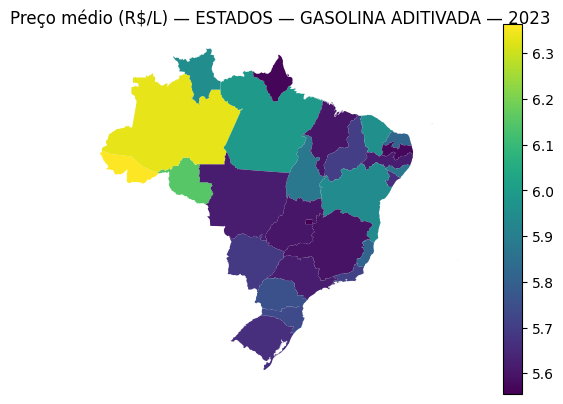

<Figure size 780x780 with 0 Axes>

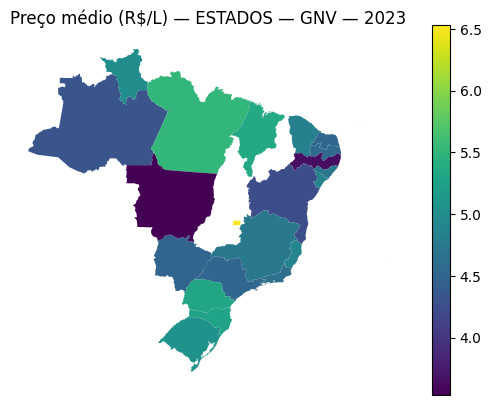

<Figure size 780x780 with 0 Axes>

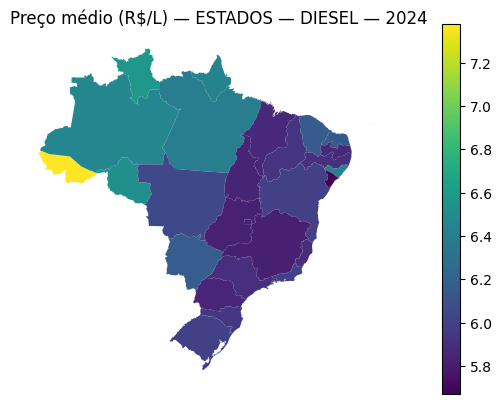

<Figure size 780x780 with 0 Axes>

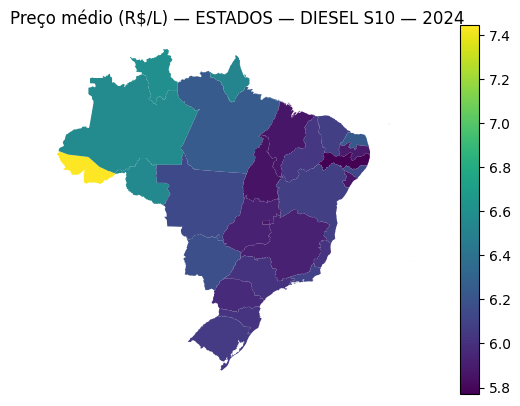

<Figure size 780x780 with 0 Axes>

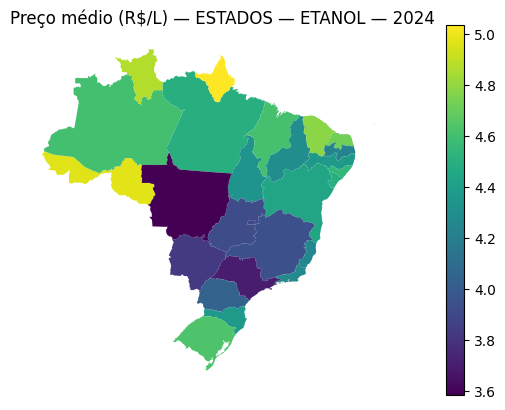

<Figure size 780x780 with 0 Axes>

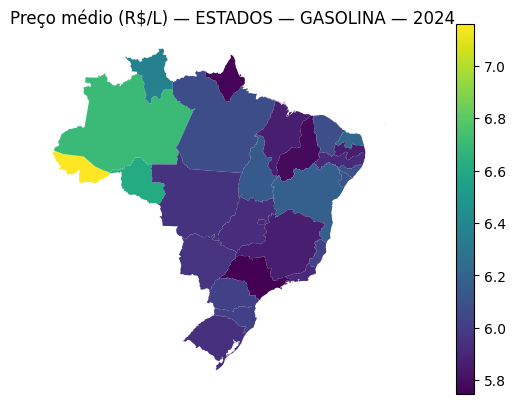

<Figure size 780x780 with 0 Axes>

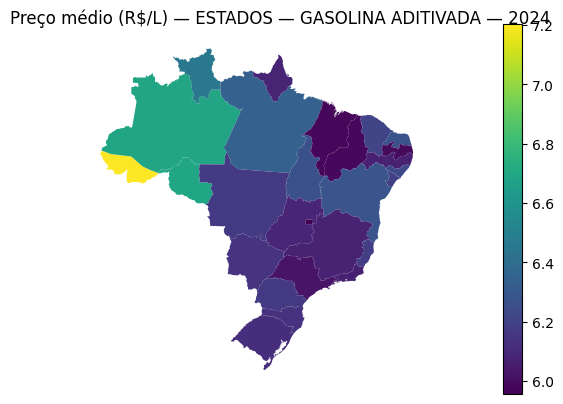

<Figure size 780x780 with 0 Axes>

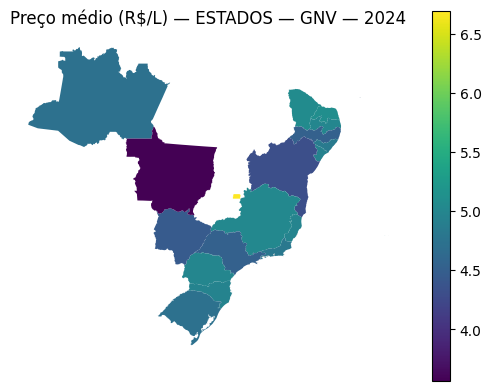

<Figure size 780x780 with 0 Axes>

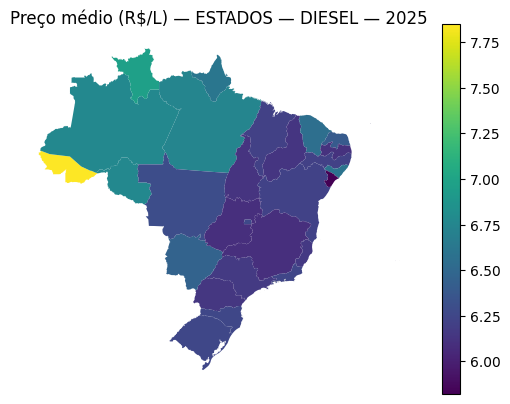

<Figure size 780x780 with 0 Axes>

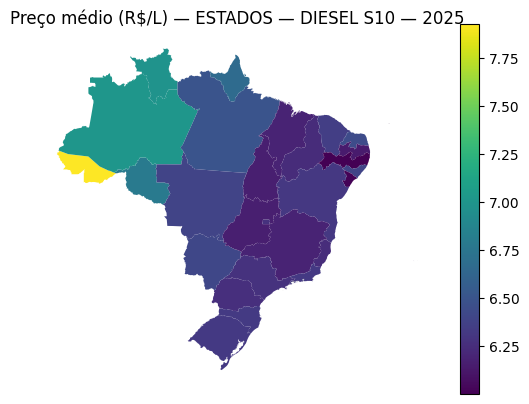

<Figure size 780x780 with 0 Axes>

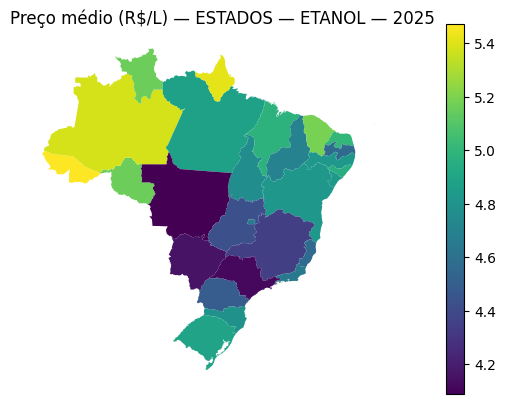

<Figure size 780x780 with 0 Axes>

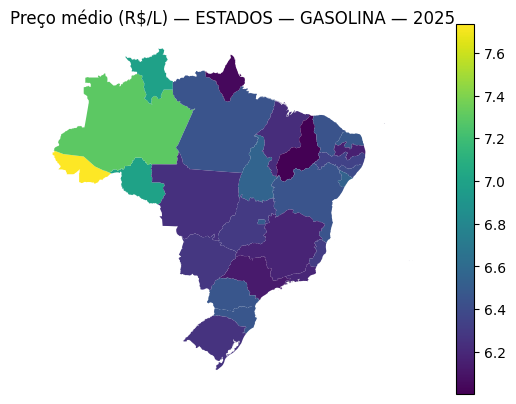

<Figure size 780x780 with 0 Axes>

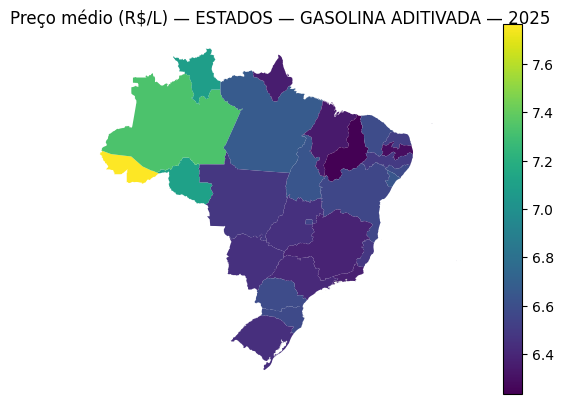

<Figure size 780x780 with 0 Axes>

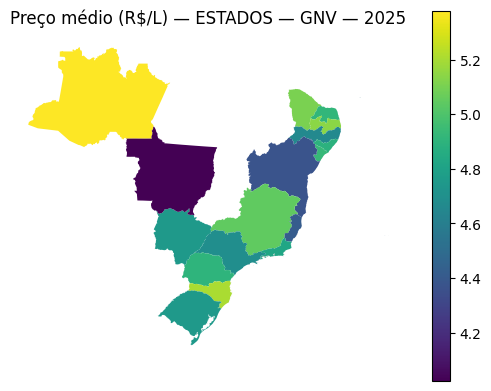

In [42]:
anos_escolhidos = sorted(df["ano"].unique())
# Para reduzir volume filtrar: anos_escolhidos = [2020, 2021, 2022, 2023, 2025]
produtos_escolhidos = sorted(df["produto"].unique())  # ou selecionar manualmente, ["GASOLINA","DIESEL","ETANOL"]

# # --- Mapas por REGIÃO ---
# for a in anos_escolhidos:
#     for p in produtos_escolhidos:
#         map_regiao(a, p, legend=True, save=False)

# --- Mapas por UF ---
for a in anos_escolhidos:
    for p in produtos_escolhidos:
        map_uf(a, p, legend=True, save=False)

# # --- Mapas por MUNICÍPIO (por UF) ---
# # Escolha 1 ou mais UFs para detalhar (municipal pode ser pesado):
# UFs_para_mapear = ["SP", "RJ", "MG", "BA", "RS"]  # ajuste conforme necessidade
# for uf in UFs_para_mapear:
#     for a in anos_escolhidos:
#         for p in produtos_escolhidos:
#             map_municipios(uf, a, p, legend=True, save=False)

<Figure size 780x780 with 0 Axes>

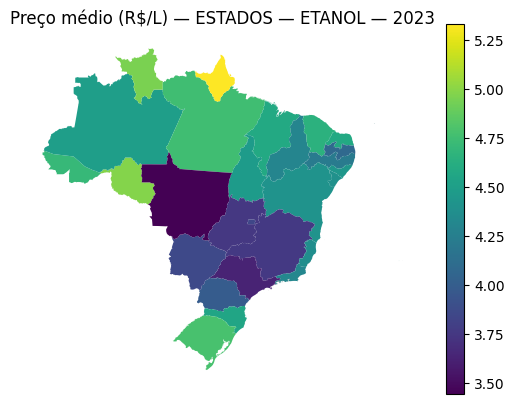

<Figure size 780x780 with 0 Axes>

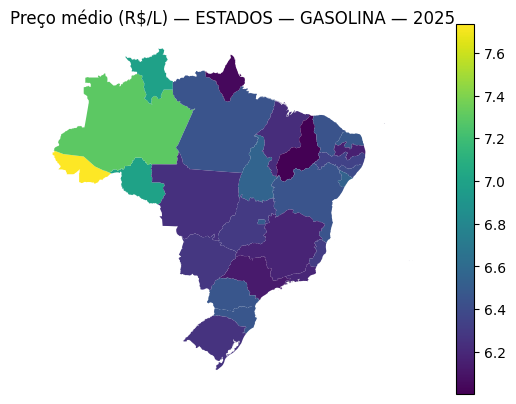

<Figure size 780x780 with 0 Axes>

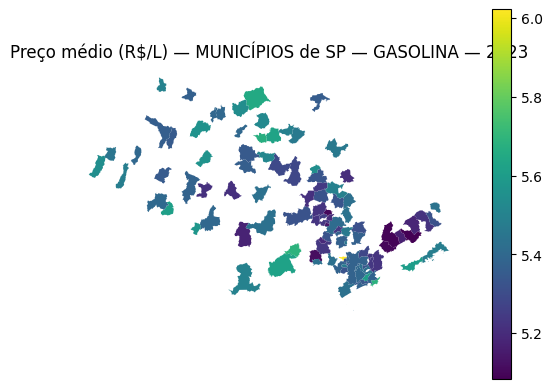

<Figure size 780x780 with 0 Axes>

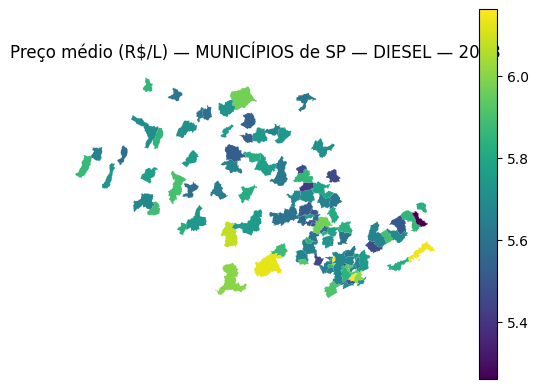

<Figure size 780x780 with 0 Axes>

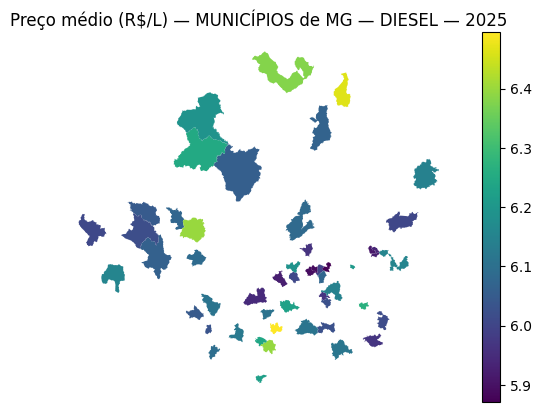

<Figure size 780x780 with 0 Axes>

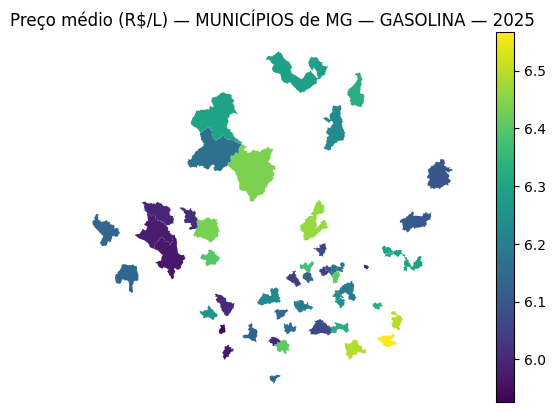

In [43]:
# # REGIÃO – por ano e produto
# map_regiao(2023, "GASOLINA")
# map_regiao(2025, "DIESEL")

# UF – por ano e produto
map_uf(2023, "ETANOL")
map_uf(2025, "GASOLINA")

# MUNICÍPIOS – escolha a UF, por ano e produto
map_municipios("SP", 2023, "GASOLINA")
map_municipios("SP", 2023, "DIESEL")
map_municipios("MG", 2025, "DIESEL")
map_municipios("MG", 2025, "GASOLINA")


In [44]:
df_raw.head(3)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,None,JARDIM ZULMIRA,18061-000,GASOLINA,03/07/2023,"4,87",None,R$ / litro,BRANCA
1,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,None,JARDIM ZULMIRA,18061-000,DIESEL S10,03/07/2023,"4,88",None,R$ / litro,BRANCA
2,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,None,JARDIM ZULMIRA,18061-000,ETANOL,03/07/2023,"3,27",None,R$ / litro,BRANCA


In [45]:
import statsmodels

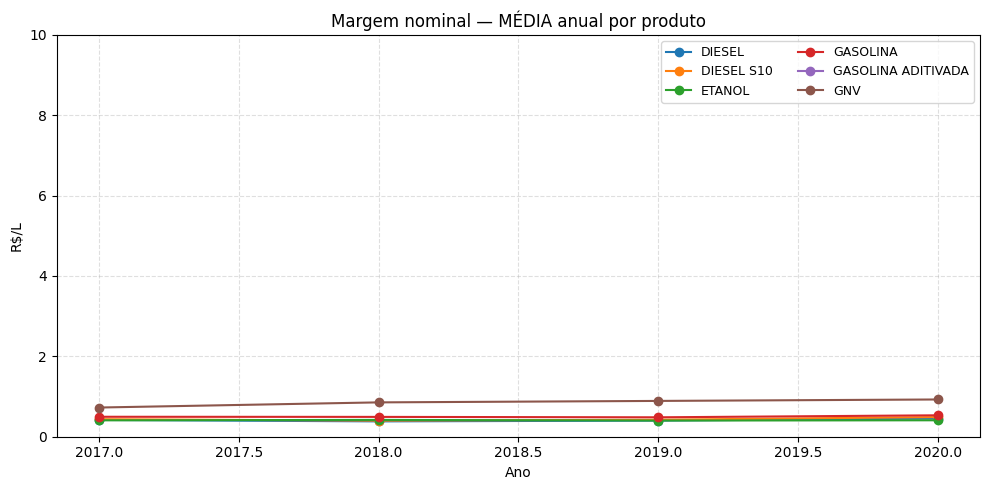

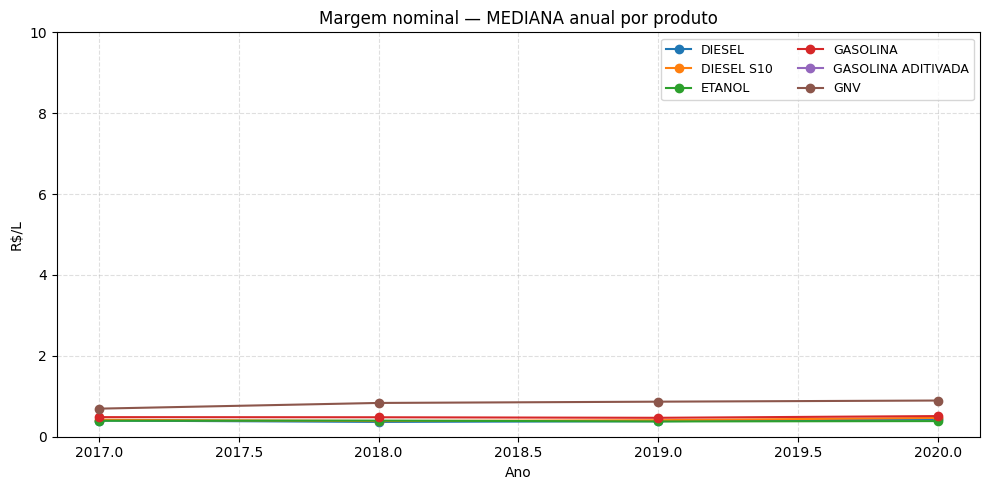


[Período observado] primeira e última data: 2017-01-02 00:00:00 → 2025-01-31 00:00:00

[Média de registros por mês]: 73545.1

[UF × Produto × Bandeira] — valor de venda (mediana) (head):
  estado produto                      bandeira  valor_median
0     AC  DIESEL                     AMAZONGÁS         7.390
1     AC  DIESEL                       ATEM' S         7.600
2     AC  DIESEL                        BRANCA         4.600
3     AC  DIESEL                       EQUADOR         4.380
4     AC  DIESEL                         FOGAS         7.440
5     AC  DIESEL                      IPIRANGA         5.329
6     AC  DIESEL  PETROBRAS DISTRIBUIDORA S.A.         4.320
7     AC  DIESEL                        RAIZEN         4.250
8     AC  DIESEL                         SABBÁ         4.410
9     AC  DIESEL                         VIBRA         7.100

[CAPITAIS] — valor de venda (mediana) (head):
  estado   municipio produto                      bandeira  valor_mediana
0     AC  RIO BRANCO

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========================= 0) CONFIGURAÇÕES =========================
LIMITE_SUP_ESCALA = 10.0   # use p/ fixar eixo Y nos gráficos (ex.: 10 R$/L)
LIMITE_INF_ESCALA = 0.0

PERIODO_INI = pd.Timestamp("2017-01-01")
PERIODO_FIM = pd.Timestamp("2025-01-31")  # até jan/2025

CAPITAIS_BR = {
    "AC":"Rio Branco","AL":"Maceió","AM":"Manaus","AP":"Macapá","BA":"Salvador","CE":"Fortaleza",
    "DF":"Brasília","ES":"Vitória","GO":"Goiânia","MA":"São Luís","MG":"Belo Horizonte","MS":"Campo Grande",
    "MT":"Cuiabá","PA":"Belém","PB":"João Pessoa","PE":"Recife","PI":"Teresina","PR":"Curitiba",
    "RJ":"Rio de Janeiro","RN":"Natal","RO":"Porto Velho","RR":"Boa Vista","RS":"Porto Alegre",
    "SC":"Florianópolis","SE":"Aracaju","SP":"São Paulo","TO":"Palmas",
}

# ========================= 1) PADRONIZAÇÃO DA BASE =========================
df = df_raw.copy()

# Padroniza nomes para snake_case
rename_map = {
    "Regiao - Sigla":"regiao", "Estado - Sigla":"estado", "Municipio":"municipio",
    "Revenda":"revenda", "Cep":"cep", "Produto":"produto", "Bandeira":"bandeira",
    "Data da Coleta":"data_coleta", "Valor de Venda":"valor_venda", "Valor de Compra":"valor_compra",
    "Unidade de Medida":"unidade_medida"
}
df.rename(columns={c: rename_map.get(c, c) for c in df.columns}, inplace=True)

# Datas e mês
df["data_coleta"] = pd.to_datetime(df["data_coleta"], dayfirst=True, errors="coerce")
df["ano"] = df["data_coleta"].dt.year
df["mes"] = df["data_coleta"].dt.to_period("M").astype(str)
df["mes_dt"] = pd.to_datetime(df["mes"] + "-01", errors="coerce")

# Conversão pt-BR -> float
def to_float_bra(s):
    if s is None: return np.nan
    s = str(s).strip()
    if s == "" or s.lower() in {"nan","none","null"}: return np.nan
    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:
        s = s.replace(",", ".")
    try:
        return float(s)
    except Exception:
        return np.nan

for col in ["valor_venda","valor_compra"]:
    if col in df.columns:
        df[col] = df[col].apply(to_float_bra)

# Filtrar período 2017-01 a 2025-01
df = df.loc[df["data_coleta"].between(PERIODO_INI, PERIODO_FIM)].copy()

# Remover linhas sem preço de venda
df = df.dropna(subset=["valor_venda"]).copy()

# Margem nominal
df["margem_nominal"] = df["valor_venda"] - df["valor_compra"]

# Flag de capitais
import unicodedata
def _norm(s):
    if s is None: return ""
    s = str(s).strip().upper()
    s = unicodedata.normalize("NFKD", s)
    return "".join(ch for ch in s if not unicodedata.combining(ch))

cap_lookup = { _norm(uf): _norm(c) for uf,c in CAPITAIS_BR.items() }
df["_uf_norm"] = df["estado"].map(_norm)
df["_mun_norm"] = df["municipio"].map(_norm)
df["is_capital"] = df.apply(lambda r: cap_lookup.get(r["_uf_norm"], "") == r["_mun_norm"], axis=1)

# ========================= 2) ESTATÍSTICAS CHAVE =========================
# 2.1 Médias por ESTADO (UF) e por CAPITAIS, estratificando por PRODUTO e BANDEIRA
def agg_metric(dfx, col_value="valor_venda", how="median"):
    if how == "mean":
        return dfx.groupby(["estado","produto","bandeira"], as_index=False)[col_value].mean().rename(columns={col_value:"valor_"+how})
    else:
        return dfx.groupby(["estado","produto","bandeira"], as_index=False)[col_value].median().rename(columns={col_value:"valor_"+how})

uf_media  = agg_metric(df, "valor_venda", "mean")
uf_mediana= agg_metric(df, "valor_venda", "median")

cap = df.loc[df["is_capital"]]
cap_media   = cap.groupby(["estado","municipio","produto","bandeira"], as_index=False)["valor_venda"].mean().rename(columns={"valor_venda":"valor_media"})
cap_mediana = cap.groupby(["estado","municipio","produto","bandeira"], as_index=False)["valor_venda"].median().rename(columns={"valor_venda":"valor_mediana"})

# 2.2 Comparação VENDA x COMPRA (nível e diferença) — Brasil/ano/produto
compra_ok = df.dropna(subset=["valor_compra"]).copy()
comp_vc_ano_prod = (
    compra_ok.groupby(["ano","produto"], as_index=False)
             .agg(
                 venda_media=("valor_venda","mean"),
                 compra_media=("valor_compra","mean"),
                 venda_mediana=("valor_venda","median"),
                 compra_mediana=("valor_compra","median"),
                 n=("valor_venda","size"),
                 margem_media=("margem_nominal","mean"),
                 margem_mediana=("margem_nominal","median")
             )
)
# Colunas percentuais (margem em % da compra e da venda)
comp_vc_ano_prod["margem_pct_compra"] = 100 * (comp_vc_ano_prod["margem_media"] / comp_vc_ano_prod["compra_media"])
comp_vc_ano_prod["margem_pct_venda"]  = 100 * (comp_vc_ano_prod["margem_media"] / comp_vc_ano_prod["venda_media"])

# 2.3 Categorias de BANDEIRA: contagem, % e "top 50%" (Pareto)
band_count = (
    df.groupby("bandeira", as_index=False)
      .agg(n=("valor_venda","size"))
      .sort_values("n", ascending=False)
      .assign(perc=lambda d: 100*d["n"]/d["n"].sum())
)
band_count["perc_acum"] = band_count["perc"].cumsum()
band_top50 = band_count.loc[band_count["perc_acum"] <= 50]

# 2.4 Média de registros/mês (Brasil)
reg_mes = df.groupby("mes_dt", as_index=False).agg(n=("valor_venda","size")).sort_values("mes_dt")
media_registros_mes = reg_mes["n"].mean()

# 2.5 CV% (coeficiente de variação) — Brasil por ano e por produto
cv_ano = (
    df.groupby("ano")["valor_venda"]
      .agg(media="mean", std="std")
      .assign(cv_pct=lambda d: 100*d["std"]/d["media"])
      .reset_index()
)
cv_ano_prod = (
    df.groupby(["ano","produto"])["valor_venda"]
      .agg(media="mean", std="std")
      .assign(cv_pct=lambda d: 100*d["std"]/d["media"])
      .reset_index()
)

# 2.6 Variação de preço 2017 → 2025 (Brasil, por produto e geral)
def _pick_value(dfx, ano, col="valor_venda", how="median"):
    s = dfx.loc[dfx["ano"]==ano, col]
    if s.empty: return np.nan
    return s.median() if how=="median" else s.mean()

var_2017_2025 = []
for prod in sorted(df["produto"].dropna().unique()):
    dsub = df.loc[df["produto"]==prod]
    v2017 = _pick_value(dsub, 2017, "valor_venda", "median")
    v2025 = _pick_value(dsub, 2025, "valor_venda", "median")
    var_2017_2025.append({
        "produto": prod,
        "mediana_2017": v2017,
        "mediana_2025": v2025,
        "delta_abs": (v2025 - v2017) if pd.notna(v2025) and pd.notna(v2017) else np.nan,
        "delta_%": (100*(v2025 - v2017)/v2017) if pd.notna(v2025) and pd.notna(v2017) and v2017!=0 else np.nan
    })
var_2017_2025 = pd.DataFrame(var_2017_2025).sort_values("delta_%", ascending=False)

# ========================= 3) TESTES DE HIPÓTESE =========================
# Testar se combustíveis podem ser analisados juntos: ANOVA/Kruskal no preço de venda
from scipy import stats

# Amostra “equilibrada” (opcional: subamostrar para reduzir viés por tamanhos muito diferentes)
df_test = df.dropna(subset=["valor_venda","produto"]).copy()

# ANOVA (assume variâncias iguais; com tamanhos desiguais, interpretar com cautela)
grupos = [g["valor_venda"].values for _, g in df_test.groupby("produto")]
anova_F, anova_p = stats.f_oneway(*grupos) if len(grupos) >= 2 else (np.nan, np.nan)

# Kruskal–Wallis (não-paramétrico)
kr_H, kr_p = stats.kruskal(*grupos) if len(grupos) >= 2 else (np.nan, np.nan)

# Welch t-test pairwise + Holm (controle de família)
prods = sorted(df_test["produto"].unique().tolist())
pairs = []
for i in range(len(prods)):
    for j in range(i+1, len(prods)):
        a = df_test.loc[df_test["produto"]==prods[i], "valor_venda"]
        b = df_test.loc[df_test["produto"]==prods[j], "valor_venda"]
        t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
        pairs.append({"p1":prods[i], "p2":prods[j], "p_raw":p})
pairs_df = pd.DataFrame(pairs)
if not pairs_df.empty:
    # Holm-Bonferroni
    pairs_df = pairs_df.sort_values("p_raw").reset_index(drop=True)
    m = len(pairs_df)
    pairs_df["p_holm"] = pairs_df["p_raw"] * (m - pairs_df.index.values)
    pairs_df["p_holm"] = pairs_df["p_holm"].clip(upper=1.0)

# ========================= 4) MODELO COM VARIÁVEL TEMPO =========================
# OLS: log(valor_venda) ~ ano (contínuo) + C(produto) + C(bandeira) + C(estado)
# Erros robustos (HC3)
import statsmodels.formula.api as smf

df_model = df.dropna(subset=["valor_venda","ano","produto","bandeira","estado"]).copy()
df_model["log_preco"] = np.log(df_model["valor_venda"].replace({0.0: np.nan}))
df_model = df_model.dropna(subset=["log_preco"])

formula = "log_preco ~ ano + C(produto) + C(bandeira) + C(estado)"
mod = smf.ols(formula, data=df_model).fit(cov_type="HC3")
beta_tempo = mod.params.get("ano", np.nan)             # coeficiente anual
efeito_ano_pct = (np.exp(beta_tempo) - 1) * 100 if pd.notna(beta_tempo) else np.nan

# ========================= 5) GRÁFICOS (MESMA ESCALA) =========================
# 5.1 Margem nominal (média e mediana) por ano × produto
agg_anual = (
    df.groupby(["ano","produto"])["margem_nominal"]
      .agg(media="mean", mediana="median")
      .reset_index()
)
wide_mean = agg_anual.pivot(index="ano", columns="produto", values="media")
wide_median = agg_anual.pivot(index="ano", columns="produto", values="mediana")

ymin = np.nanmin([wide_mean.min().min(), wide_median.min().min()])
ymax = np.nanmax([wide_mean.max().max(), wide_median.max().max()])
if not np.isfinite(ymin) or not np.isfinite(ymax):
    ymin, ymax = 0, 1
pad = 0.05*(ymax - ymin if ymax>ymin else 1)
ylims = (LIMITE_INF_ESCALA if LIMITE_INF_ESCALA is not None else ymin-pad,
         LIMITE_SUP_ESCALA if LIMITE_SUP_ESCALA is not None else ymax+pad)

plt.figure(figsize=(10,5))
for c in wide_mean.columns:
    plt.plot(wide_mean.index, wide_mean[c], marker="o", label=str(c))
plt.title("Margem nominal — MÉDIA anual por produto")
plt.xlabel("Ano"); plt.ylabel("R$/L"); plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(*ylims); plt.legend(ncol=2, fontsize=9); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
for c in wide_median.columns:
    plt.plot(wide_median.index, wide_median[c], marker="o", label=str(c))
plt.title("Margem nominal — MEDIANA anual por produto")
plt.xlabel("Ano"); plt.ylabel("R$/L"); plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(*ylims); plt.legend(ncol=2, fontsize=9); plt.tight_layout(); plt.show()

# ========================= 6) SAÍDAS PRINCIPAIS (PRINTS RÁPIDOS) =========================
print("\n[Período observado] primeira e última data:",
      df["data_coleta"].min(), "→", df["data_coleta"].max())
print("\n[Média de registros por mês]:", round(media_registros_mes, 1))

print("\n[UF × Produto × Bandeira] — valor de venda (mediana) (head):")
print(uf_mediana.head(10))

print("\n[CAPITAIS] — valor de venda (mediana) (head):")
print(cap_mediana.head(10))

print("\n[VENDA vs COMPRA] — Brasil por ano×produto (head):")
print(comp_vc_ano_prod.head(12))

print("\n[Bandeiras] contagem/percentual e Top 50% (Pareto):")
print(band_count.head(10))
print("\nTop 50% (cumulativo):")
print(band_top50)

print("\n[CV% por ano] (head):")
print(cv_ano.head())

print("\n[Variação 2017 → 2025 por produto] (head):")
print(var_2017_2025.head(15))

print("\n[ANOVA] F, p =", anova_F, anova_p)
print("[Kruskal] H, p =", kr_H, kr_p)
if not pairs_df.empty:
    print("\n[Welch + Holm] comparações par-a-par (head):")
    print(pairs_df.head(15))

print("\n[Modelo OLS] coeficiente de 'ano' =", round(beta_tempo, 6),
      "→ efeito anual aproximado =", f"{efeito_ano_pct:.2f}%" if pd.notna(efeito_ano_pct) else "NaN")

# Observação:
# - Para “mesma escala” em outros gráficos, use os limites ylims definidos acima (ou ajuste LIMITE_SUP_ESCALA).
# - Se quiser salvar resultados/tabelas, use .to_csv() nos DataFrames gerados.


In [47]:
df_cmp = df_raw.copy()

In [48]:
df_cmp.head(1)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,None,JARDIM ZULMIRA,18061-000,GASOLINA,03/07/2023,"4,87",None,R$ / litro,BRANCA


In [49]:
df_cmp = df_raw.copy()

cols_drop = ["CNPJ da Revenda", "Numero Rua", "Nome da Rua", "Complemento", "Bairro"]
df_cmp = df_cmp.drop(columns=[c for c in cols_drop if c in df_cmp.columns], errors="ignore")

# Datas -> datetime
if "Data da Coleta" in df_cmp.columns:
    df_cmp["Data da Coleta"] = pd.to_datetime(df_cmp["Data da Coleta"], dayfirst=True, errors="coerce")

# >>> Converter preços pt-BR -> float (FAZER ANTES de calcular a margem)
for col in ["Valor de Venda", "Valor de Compra"]:
    if col in df_cmp.columns:
        df_cmp[col] = (
            df_cmp[col].astype(str).str.strip()
            .replace({"None": np.nan, "none": np.nan, "NaN": np.nan, "nan": np.nan})
            .str.replace(".", "", regex=False)   # milhar
            .str.replace(",", ".", regex=False)  # vírgula decimal -> ponto
        )
        df_cmp[col] = pd.to_numeric(df_cmp[col], errors="coerce")

if {"Valor de Venda", "Valor de Compra"}.issubset(df_cmp.columns):
    df_cmp["margem_nominal"] = df_cmp["Valor de Venda"] - df_cmp["Valor de Compra"]

# >>> Manter APENAS linhas com Valor de Compra disponível
df_compra = df_cmp.loc[df_cmp["Valor de Compra"].notna()].copy()

# Criar mês (YYYY-MM) e mes_dt (Timestamp do 1º dia do mês)
df_compra["mes"] = df_compra["Data da Coleta"].dt.to_period("M").astype(str)
df_compra["mes_dt"] = pd.to_datetime(df_compra["mes"] + "-01", errors="coerce")

# Tabela mensal (apenas Valor de Compra)
compra_mensal = (
    df_compra.groupby("mes_dt")["Valor de Compra"]
    .agg(
        n="size",
        media="mean",
        mediana="median",
        std="std",
        p10=lambda s: s.quantile(0.10),
        p90=lambda s: s.quantile(0.90),
        iqr=lambda s: s.quantile(0.75) - s.quantile(0.25),
    )
    .reset_index()
    .sort_values("mes_dt")
    .assign(**{"cv_%": lambda d: np.where(d["media"].ne(0), d["std"] / d["media"] * 100, np.nan)})
)

# Visualização rápida
print(df_compra[["Data da Coleta", "Valor de Compra"]].head())
print(compra_mensal.head())

       Data da Coleta  Valor de Compra
472430     2017-07-04           3.0396
472440     2017-07-03           3.5757
472441     2017-07-03           3.0509
472450     2017-07-06           3.2829
472451     2017-07-06           3.0056
      mes_dt      n     media  mediana       std     p10      p90     iqr       cv_%
0 2017-01-01  41108  2.913831   2.8501  0.371243  2.4780  3.43890  0.5806  12.740731
1 2017-02-01  33132  2.886824   2.8288  0.372441  2.4340  3.40519  0.5717  12.901397
2 2017-03-01  40519  2.798186   2.7600  0.390179  2.2884  3.32592  0.5557  13.943997
3 2017-04-01  34541  2.735467   2.7000  0.400422  2.1476  3.26980  0.5437  14.638169
4 2017-05-01  41906  2.732756   2.7269  0.408694  2.0930  3.26180  0.5133  14.955375


In [50]:
df_compra.sample(2)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira,margem_nominal,mes,mes_dt
7353630,SE,RJ,MARICA,AUTO POSTO SENTIDO DO MAR LTDA,24900-000,DIESEL,2018-06-04,3.899,3.51,R$ / litro,BRANCA,0.389,2018-06,2018-06-01
6860302,SE,SP,SUZANO,AUTO POSTO SUZAN PECAS E ACESSORIOS LTDA,08610-140,DIESEL,2020-08-17,3.199,2.83,R$ / litro,BRANCA,0.369,2020-08,2020-08-01


Primeira data: 2017-01-02 00:00:00
Última data  : 2020-08-17 00:00:00

Estatísticas anuais da margem_nominal:
    ano       n     media  mediana       std
0  2017  355765  0.447209   0.4300  0.165893
1  2018  386490  0.436334   0.4164  0.177173
2  2019  381869  0.437487   0.4161  0.179622
3  2020  156012  0.478695   0.4567  0.205060


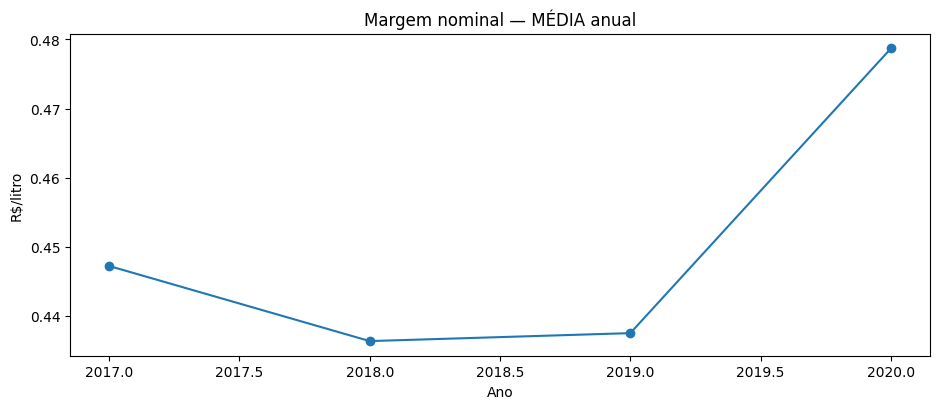

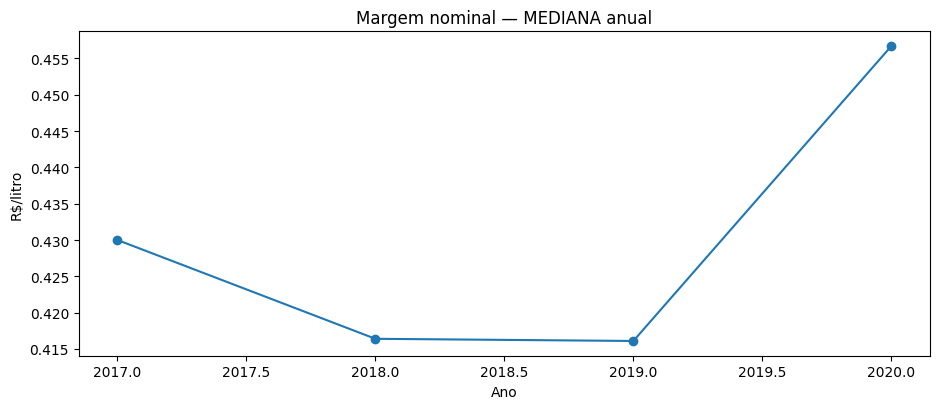


Amostra com percentuais:
       Data da Coleta     Produto  Valor de Compra  Valor de Venda  margem_nominal  margem_pct  margem_pct_sobre_venda
472430     2017-07-04    GASOLINA           3.0396            3.68          0.6404   21.068562               17.402174
472440     2017-07-03    GASOLINA           3.5757            4.70          1.1243   31.442794               23.921277
472441     2017-07-03      DIESEL           3.0509            4.22          1.1691   38.319840               27.703791
472450     2017-07-06    GASOLINA           3.2829            3.83          0.5471   16.665144               14.284595
472451     2017-07-06      ETANOL           3.0056            3.60          0.5944   19.776417               16.511111
472452     2017-07-06      DIESEL           3.0036            3.65          0.6464   21.520842               17.709589
472453     2017-07-06  DIESEL S10           2.9159            3.75          0.8341   28.605233               22.242667
472454     2017-07-06 

In [51]:
dfm = df_cmp.copy() if 'df_cmp' in globals() else df.copy()

# -------- Garantias de tipos --------
# Data
if not np.issubdtype(dfm["Data da Coleta"].dtype, np.datetime64):
    dfm["Data da Coleta"] = pd.to_datetime(dfm["Data da Coleta"], dayfirst=True, errors="coerce")

# Valores numéricos (se vieram como string)
for col in ["Valor de Venda", "Valor de Compra", "margem_nominal"]:
    if col in dfm.columns and not np.issubdtype(dfm[col].dtype, np.number):
        dfm[col] = pd.to_numeric(dfm[col], errors="coerce")

# Se não existir margem_nominal, calcula
if "margem_nominal" not in dfm.columns:
    dfm["margem_nominal"] = dfm["Valor de Venda"] - dfm["Valor de Compra"]

# Remover linhas sem compra/venda coerente
dfm = dfm.dropna(subset=["Valor de Compra", "Valor de Venda", "margem_nominal"]).copy()

# -------- 1) Primeira e última data --------
primeira_data = dfm["Data da Coleta"].min()
ultima_data   = dfm["Data da Coleta"].max()
print("Primeira data:", primeira_data)
print("Última data  :", ultima_data)

# Ano (se não existir)
if "ano" not in dfm.columns:
    dfm["ano"] = dfm["Data da Coleta"].dt.year

# -------- 2) Série anual da margem (média e mediana) --------
agg_anual = (
    dfm.groupby("ano")["margem_nominal"]
       .agg(n="size", media="mean", mediana="median", std="std")
       .reset_index()
       .sort_values("ano")
)
print("\nEstatísticas anuais da margem_nominal:")
print(agg_anual.head(20))

# Gráfico: média anual da margem_nominal
plt.figure(figsize=(9.5, 4.2))
plt.plot(agg_anual["ano"], agg_anual["media"], marker="o")
plt.title("Margem nominal — MÉDIA anual")
plt.xlabel("Ano")
plt.ylabel("R$/litro")
plt.tight_layout()
plt.show()

# Gráfico: mediana anual da margem_nominal
plt.figure(figsize=(9.5, 4.2))
plt.plot(agg_anual["ano"], agg_anual["mediana"], marker="o")
plt.title("Margem nominal — MEDIANA anual")
plt.xlabel("Ano")
plt.ylabel("R$/litro")
plt.tight_layout()
plt.show()

# -------- 3) Coluna percentual da diferença --------
# Definição padrão de margem percentual: (venda - compra) / compra
# (evita divisão por 0 ou NaN)
den = dfm["Valor de Compra"].replace({0.0: np.nan})
dfm["margem_pct"] = 100.0 * (dfm["margem_nominal"] / den)

# (Opcional) também sobre o preço de venda, se quiser comparar:
dfm["margem_pct_sobre_venda"] = 100.0 * (dfm["margem_nominal"] / dfm["Valor de Venda"].replace({0.0: np.nan}))

print("\nAmostra com percentuais:")
print(dfm[["Data da Coleta","Produto","Valor de Compra","Valor de Venda","margem_nominal","margem_pct","margem_pct_sobre_venda"]].head(10))

# Agregado anual dos percentuais (útil para relatório)
agg_pct = (
    dfm.groupby("ano")[["margem_pct","margem_pct_sobre_venda"]]
       .agg(["count","mean","median","std"])
       .round(3)
)
print("\nResumo anual das margens percentuais:")
print(agg_pct)


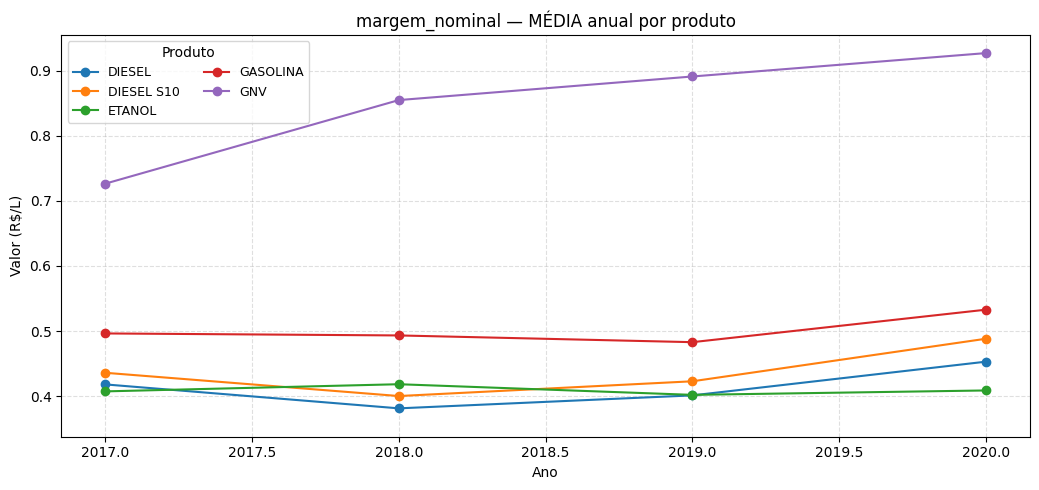

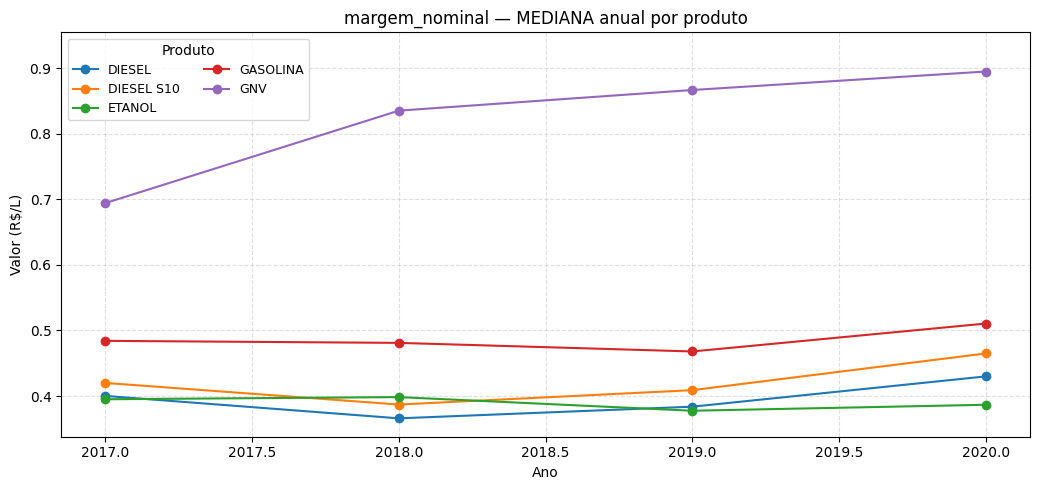

      ano     Produto     media  mediana       n
0  2017.0      DIESEL  0.418249   0.4002   63241
1  2017.0  DIESEL S10  0.436088   0.4200   79740
2  2017.0      ETANOL  0.407551   0.3951   93857
3  2017.0    GASOLINA  0.496473   0.4842  116396
4  2017.0         GNV  0.726346   0.6943    2531
Produto    DIESEL  DIESEL S10    ETANOL  GASOLINA       GNV
ano                                                        
2017.0   0.418249    0.436088  0.407551  0.496473  0.726346
2018.0   0.381506    0.400404  0.418535  0.493404  0.854625
2019.0   0.401401    0.423047  0.402203  0.483077  0.890826
2020.0   0.453145    0.488341  0.408979  0.532932  0.926717
Produto  DIESEL  DIESEL S10  ETANOL  GASOLINA     GNV
ano                                                  
2017.0   0.4002     0.42000  0.3951    0.4842  0.6943
2018.0   0.3660     0.38705  0.3984    0.4811  0.8353
2019.0   0.3838     0.40900  0.3776    0.4680  0.8668
2020.0   0.4300     0.46500  0.3867    0.5106  0.8950


In [52]:
TARGET = "margem_nominal"  # variável a analisar (ex.: 'margem_nominal', 'Valor de Venda', etc.)
SAVE_FIGS = False
FIG_DIR = "figs_anp"

# ======= Seleção robusta de colunas (adapte se necessário) =======
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Nenhuma das colunas encontradas: {candidates}")

COL_DATA = pick_col(df_cmp if 'df_cmp' in globals() else df, ["Data da Coleta","data_coleta"])
COL_PROD = pick_col(df_cmp if 'df_cmp' in globals() else df, ["Produto","produto"])
COL_VALC = pick_col(df_cmp if 'df_cmp' in globals() else df, ["Valor de Compra","valor_compra"])
COL_VALV = pick_col(df_cmp if 'df_cmp' in globals() else df, ["Valor de Venda","valor_venda"])

# Base para análise
dfm = (df_cmp if 'df_cmp' in globals() else df).copy()

# Garantias de tipo
dfm[COL_DATA] = pd.to_datetime(dfm[COL_DATA], dayfirst=True, errors="coerce")
for col in [COL_VALV, COL_VALC, TARGET]:
    if col in dfm.columns and not np.issubdtype(dfm[col].dtype, np.number):
        dfm[col] = pd.to_numeric(dfm[col], errors="coerce")

# Se TARGET não existir, calcula margem_nominal
if TARGET not in dfm.columns:
    dfm["margem_nominal"] = dfm[COL_VALV] - dfm[COL_VALC]
    TARGET = "margem_nominal"

# Cria 'ano' se não houver
if "ano" not in dfm.columns:
    dfm["ano"] = dfm[COL_DATA].dt.year

# Mantém observações válidas
dfm = dfm.dropna(subset=[COL_PROD, "ano", TARGET]).copy()

# ======= Agregações por ano × produto =======
agg = (
    dfm.groupby(["ano", COL_PROD])[TARGET]
       .agg(media="mean", mediana="median", n="size")
       .reset_index()
       .sort_values(["ano", COL_PROD])
)

# Tabelas em formato largo (linhas=ano, colunas=produto)
wide_mean   = agg.pivot(index="ano", columns=COL_PROD, values="media")
wide_median = agg.pivot(index="ano", columns=COL_PROD, values="mediana")

# ======= Igualar eixo Y entre os dois gráficos =======
ymin = np.nanmin([wide_mean.min().min(), wide_median.min().min()])
ymax = np.nanmax([wide_mean.max().max(), wide_median.max().max()])
if np.isfinite(ymin) and np.isfinite(ymax):
    pad = 0.05 * (ymax - ymin if ymax > ymin else (abs(ymax) + 1))
    ylims = (ymin - pad, ymax + pad)
else:
    ylims = None  # deixa automático se não houver dados suficientes

# ======= Plot 1: MÉDIA anual por produto =======
plt.figure(figsize=(10.5, 5))
for col in wide_mean.columns:
    plt.plot(wide_mean.index, wide_mean[col], marker="o", label=str(col))
plt.title(f"{TARGET} — MÉDIA anual por produto")
plt.xlabel("Ano")
plt.ylabel("Valor (R$/L)")
plt.grid(True, linestyle="--", alpha=0.4)
if ylims: plt.ylim(ylims)
plt.legend(title="Produto", ncol=2, fontsize=9)
plt.tight_layout()
if SAVE_FIGS:
    import os
    os.makedirs(FIG_DIR, exist_ok=True)
    plt.savefig(f"{FIG_DIR}/{TARGET}_media_anual_por_produto.png", dpi=150, bbox_inches="tight")
plt.show()

# ======= Plot 2: MEDIANA anual por produto =======
plt.figure(figsize=(10.5, 5))
for col in wide_median.columns:
    plt.plot(wide_median.index, wide_median[col], marker="o", label=str(col))
plt.title(f"{TARGET} — MEDIANA anual por produto")
plt.xlabel("Ano")
plt.ylabel("Valor (R$/L)")
plt.grid(True, linestyle="--", alpha=0.4)
if ylims: plt.ylim(ylims)  # mesmo eixo Y do gráfico de média
plt.legend(title="Produto", ncol=2, fontsize=9)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(f"{FIG_DIR}/{TARGET}_mediana_anual_por_produto.png", dpi=150, bbox_inches="tight")
plt.show()

# (Opcional) Exibir as primeiras linhas das tabelas agregadas
print(agg.head())
print(wide_mean.head())
print(wide_median.head())

In [ ]:
# ========================= 0) CONFIGURAÇÕES =========================
LIMITE_SUP_ESCALA = 10.0   # use p/ fixar eixo Y nos gráficos (ex.: 10 R$/L)
LIMITE_INF_ESCALA = 0.0

PERIODO_INI = pd.Timestamp("2017-01-01")
PERIODO_FIM = pd.Timestamp("2025-01-31")  # até jan/2025

CAPITAIS_BR = {
    "AC":"Rio Branco","AL":"Maceió","AM":"Manaus","AP":"Macapá","BA":"Salvador","CE":"Fortaleza",
    "DF":"Brasília","ES":"Vitória","GO":"Goiânia","MA":"São Luís","MG":"Belo Horizonte","MS":"Campo Grande",
    "MT":"Cuiabá","PA":"Belém","PB":"João Pessoa","PE":"Recife","PI":"Teresina","PR":"Curitiba",
    "RJ":"Rio de Janeiro","RN":"Natal","RO":"Porto Velho","RR":"Boa Vista","RS":"Porto Alegre",
    "SC":"Florianópolis","SE":"Aracaju","SP":"São Paulo","TO":"Palmas",
}

# ========================= 1) PADRONIZAÇÃO DA BASE =========================
df = df_raw.copy()

# Padroniza nomes para snake_case
rename_map = {
    "Regiao - Sigla":"regiao", "Estado - Sigla":"estado", "Municipio":"municipio",
    "Revenda":"revenda", "Cep":"cep", "Produto":"produto", "Bandeira":"bandeira",
    "Data da Coleta":"data_coleta", "Valor de Venda":"valor_venda", "Valor de Compra":"valor_compra",
    "Unidade de Medida":"unidade_medida"
}
df.rename(columns={c: rename_map.get(c, c) for c in df.columns}, inplace=True)

# Datas e mês
df["data_coleta"] = pd.to_datetime(df["data_coleta"], dayfirst=True, errors="coerce")
df["ano"] = df["data_coleta"].dt.year
df["mes"] = df["data_coleta"].dt.to_period("M").astype(str)
df["mes_dt"] = pd.to_datetime(df["mes"] + "-01", errors="coerce")

# Conversão pt-BR -> float
def to_float_bra(s):
    if s is None: return np.nan
    s = str(s).strip()
    if s == "" or s.lower() in {"nan","none","null"}: return np.nan
    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:
        s = s.replace(",", ".")
    try:
        return float(s)
    except Exception:
        return np.nan

for col in ["valor_venda","valor_compra"]:
    if col in df.columns:
        df[col] = df[col].apply(to_float_bra)

# Filtrar período 2017-01 a 2025-01
df = df.loc[df["data_coleta"].between(PERIODO_INI, PERIODO_FIM)].copy()

# Remover linhas sem preço de venda
df = df.dropna(subset=["valor_venda"]).copy()

# Margem nominal
df["margem_nominal"] = df["valor_venda"] - df["valor_compra"]

# Flag de capitais
import unicodedata
def _norm(s):
    if s is None: return ""
    s = str(s).strip().upper()
    s = unicodedata.normalize("NFKD", s)
    return "".join(ch for ch in s if not unicodedata.combining(ch))

cap_lookup = { _norm(uf): _norm(c) for uf,c in CAPITAIS_BR.items() }
df["_uf_norm"] = df["estado"].map(_norm)
df["_mun_norm"] = df["municipio"].map(_norm)
df["is_capital"] = df.apply(lambda r: cap_lookup.get(r["_uf_norm"], "") == r["_mun_norm"], axis=1)

In [ ]:
# ========================= 2) ESTATÍSTICAS CHAVE =========================
# 2.1 Médias por ESTADO (UF) e por CAPITAIS, estratificando por PRODUTO e BANDEIRA
def agg_metric(dfx, col_value="valor_venda", how="median"):
    if how == "mean":
        return dfx.groupby(["estado","produto","bandeira"], as_index=False)[col_value].mean().rename(columns={col_value:"valor_"+how})
    else:
        return dfx.groupby(["estado","produto","bandeira"], as_index=False)[col_value].median().rename(columns={col_value:"valor_"+how})

uf_media  = agg_metric(df, "valor_venda", "mean")
uf_mediana= agg_metric(df, "valor_venda", "median")

cap = df.loc[df["is_capital"]]
cap_media   = cap.groupby(["estado","municipio","produto","bandeira"], as_index=False)["valor_venda"].mean().rename(columns={"valor_venda":"valor_media"})
cap_mediana = cap.groupby(["estado","municipio","produto","bandeira"], as_index=False)["valor_venda"].median().rename(columns={"valor_venda":"valor_mediana"})

# 2.2 Comparação VENDA x COMPRA (nível e diferença) — Brasil/ano/produto
compra_ok = df.dropna(subset=["valor_compra"]).copy()
comp_vc_ano_prod = (
    compra_ok.groupby(["ano","produto"], as_index=False)
             .agg(
                 venda_media=("valor_venda","mean"),
                 compra_media=("valor_compra","mean"),
                 venda_mediana=("valor_venda","median"),
                 compra_mediana=("valor_compra","median"),
                 n=("valor_venda","size"),
                 margem_media=("margem_nominal","mean"),
                 margem_mediana=("margem_nominal","median")
             )
)
# Colunas percentuais (margem em % da compra e da venda)
comp_vc_ano_prod["margem_pct_compra"] = 100 * (comp_vc_ano_prod["margem_media"] / comp_vc_ano_prod["compra_media"])
comp_vc_ano_prod["margem_pct_venda"]  = 100 * (comp_vc_ano_prod["margem_media"] / comp_vc_ano_prod["venda_media"])

# 2.3 Categorias de BANDEIRA: contagem, % e "top 50%" (Pareto)
band_count = (
    df.groupby("bandeira", as_index=False)
      .agg(n=("valor_venda","size"))
      .sort_values("n", ascending=False)
      .assign(perc=lambda d: 100*d["n"]/d["n"].sum())
)
band_count["perc_acum"] = band_count["perc"].cumsum()
band_top50 = band_count.loc[band_count["perc_acum"] <= 50]

# 2.4 Média de registros/mês (Brasil)
reg_mes = df.groupby("mes_dt", as_index=False).agg(n=("valor_venda","size")).sort_values("mes_dt")
media_registros_mes = reg_mes["n"].mean()

# 2.5 CV% (coeficiente de variação) — Brasil por ano e por produto
cv_ano = (
    df.groupby("ano")["valor_venda"]
      .agg(media="mean", std="std")
      .assign(cv_pct=lambda d: 100*d["std"]/d["media"])
      .reset_index()
)
cv_ano_prod = (
    df.groupby(["ano","produto"])["valor_venda"]
      .agg(media="mean", std="std")
      .assign(cv_pct=lambda d: 100*d["std"]/d["media"])
      .reset_index()
)

# 2.6 Variação de preço 2017 → 2025 (Brasil, por produto e geral)
def _pick_value(dfx, ano, col="valor_venda", how="median"):
    s = dfx.loc[dfx["ano"]==ano, col]
    if s.empty: return np.nan
    return s.median() if how=="median" else s.mean()

var_2017_2025 = []
for prod in sorted(df["produto"].dropna().unique()):
    dsub = df.loc[df["produto"]==prod]
    v2017 = _pick_value(dsub, 2017, "valor_venda", "median")
    v2025 = _pick_value(dsub, 2025, "valor_venda", "median")
    var_2017_2025.append({
        "produto": prod,
        "mediana_2017": v2017,
        "mediana_2025": v2025,
        "delta_abs": (v2025 - v2017) if pd.notna(v2025) and pd.notna(v2017) else np.nan,
        "delta_%": (100*(v2025 - v2017)/v2017) if pd.notna(v2025) and pd.notna(v2017) and v2017!=0 else np.nan
    })
var_2017_2025 = pd.DataFrame(var_2017_2025).sort_values("delta_%", ascending=False)

In [ ]:
# ========================= 3) TESTES DE HIPÓTESE =========================
# Testar se combustíveis podem ser analisados juntos: ANOVA/Kruskal no preço de venda
from scipy import stats

# Amostra “equilibrada” (opcional: subamostrar para reduzir viés por tamanhos muito diferentes)
df_test = df.dropna(subset=["valor_venda","produto"]).copy()

# ANOVA (assume variâncias iguais; com tamanhos desiguais, interpretar com cautela)
grupos = [g["valor_venda"].values for _, g in df_test.groupby("produto")]
anova_F, anova_p = stats.f_oneway(*grupos) if len(grupos) >= 2 else (np.nan, np.nan)

# Kruskal–Wallis (não-paramétrico)
kr_H, kr_p = stats.kruskal(*grupos) if len(grupos) >= 2 else (np.nan, np.nan)

# Welch t-test pairwise + Holm (controle de família)
prods = sorted(df_test["produto"].unique().tolist())
pairs = []
for i in range(len(prods)):
    for j in range(i+1, len(prods)):
        a = df_test.loc[df_test["produto"]==prods[i], "valor_venda"]
        b = df_test.loc[df_test["produto"]==prods[j], "valor_venda"]
        t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
        pairs.append({"p1":prods[i], "p2":prods[j], "p_raw":p})
pairs_df = pd.DataFrame(pairs)
if not pairs_df.empty:
    # Holm-Bonferroni
    pairs_df = pairs_df.sort_values("p_raw").reset_index(drop=True)
    m = len(pairs_df)
    pairs_df["p_holm"] = pairs_df["p_raw"] * (m - pairs_df.index.values)
    pairs_df["p_holm"] = pairs_df["p_holm"].clip(upper=1.0)



In [ ]:
# ========================= 4) MODELO COM VARIÁVEL TEMPO =========================
# OLS: log(valor_venda) ~ ano (contínuo) + C(produto) + C(bandeira) + C(estado)
# Erros robustos (HC3)
import statsmodels.formula.api as smf

df_model = df.dropna(subset=["valor_venda","ano","produto","bandeira","estado"]).copy()
df_model["log_preco"] = np.log(df_model["valor_venda"].replace({0.0: np.nan}))
df_model = df_model.dropna(subset=["log_preco"])

formula = "log_preco ~ ano + C(produto) + C(bandeira) + C(estado)"
mod = smf.ols(formula, data=df_model).fit(cov_type="HC3")
beta_tempo = mod.params.get("ano", np.nan)             # coeficiente anual
efeito_ano_pct = (np.exp(beta_tempo) - 1) * 100 if pd.notna(beta_tempo) else np.nan

In [ ]:
# ========================= 5) GRÁFICOS (MESMA ESCALA) =========================
# 5.1 Margem nominal (média e mediana) por ano × produto
agg_anual = (
    df.groupby(["ano","produto"])["margem_nominal"]
      .agg(media="mean", mediana="median")
      .reset_index()
)
wide_mean = agg_anual.pivot(index="ano", columns="produto", values="media")
wide_median = agg_anual.pivot(index="ano", columns="produto", values="mediana")

ymin = np.nanmin([wide_mean.min().min(), wide_median.min().min()])
ymax = np.nanmax([wide_mean.max().max(), wide_median.max().max()])
if not np.isfinite(ymin) or not np.isfinite(ymax):
    ymin, ymax = 0, 1
pad = 0.05*(ymax - ymin if ymax>ymin else 1)
ylims = (LIMITE_INF_ESCALA if LIMITE_INF_ESCALA is not None else ymin-pad,
         LIMITE_SUP_ESCALA if LIMITE_SUP_ESCALA is not None else ymax+pad)

plt.figure(figsize=(10,5))
for c in wide_mean.columns:
    plt.plot(wide_mean.index, wide_mean[c], marker="o", label=str(c))
plt.title("Margem nominal — MÉDIA anual por produto")
plt.xlabel("Ano"); plt.ylabel("R$/L"); plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(*ylims); plt.legend(ncol=2, fontsize=9); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
for c in wide_median.columns:
    plt.plot(wide_median.index, wide_median[c], marker="o", label=str(c))
plt.title("Margem nominal — MEDIANA anual por produto")
plt.xlabel("Ano"); plt.ylabel("R$/L"); plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(*ylims); plt.legend(ncol=2, fontsize=9); plt.tight_layout(); plt.show()

In [ ]:
# ========================= 6) SAÍDAS PRINCIPAIS (PRINTS RÁPIDOS) =========================
print("\n[Período observado] primeira e última data:",
      df["data_coleta"].min(), "→", df["data_coleta"].max())
print("\n[Média de registros por mês]:", round(media_registros_mes, 1))

print("\n[UF × Produto × Bandeira] — valor de venda (mediana) (head):")
print(uf_mediana.head(10))

print("\n[CAPITAIS] — valor de venda (mediana) (head):")
print(cap_mediana.head(10))

print("\n[VENDA vs COMPRA] — Brasil por ano×produto (head):")
print(comp_vc_ano_prod.head(12))

print("\n[Bandeiras] contagem/percentual e Top 50% (Pareto):")
print(band_count.head(10))
print("\nTop 50% (cumulativo):")
print(band_top50)

print("\n[CV% por ano] (head):")
print(cv_ano.head())

print("\n[Variação 2017 → 2025 por produto] (head):")
print(var_2017_2025.head(15))

print("\n[ANOVA] F, p =", anova_F, anova_p)
print("[Kruskal] H, p =", kr_H, kr_p)
if not pairs_df.empty:
    print("\n[Welch + Holm] comparações par-a-par (head):")
    print(pairs_df.head(15))

print("\n[Modelo OLS] coeficiente de 'ano' =", round(beta_tempo, 6),
      "→ efeito anual aproximado =", f"{efeito_ano_pct:.2f}%" if pd.notna(efeito_ano_pct) else "NaN")

# Observação:
# - Para “mesma escala” em outros gráficos, use os limites ylims definidos acima (ou ajuste LIMITE_SUP_ESCALA).
# - Se quiser salvar resultados/tabelas, use .to_csv() nos DataFrames gerados.
# -*- coding: utf-8 -*-
# Pipeline analítico a partir da base RAW (df_raw)
# Objetivos:
# - Médias por ESTADO (UF) e CAPITAIS, por PRODUTO e BANDEIRA
# - Comparação Valor de Venda x Valor de Compra (nível e diferença)
# - Categorias de bandeira: contagem, participação e "top 50%" (Pareto)
# - Jan/2017 a Jan/2025: estatísticas (média de registros/mês, variação de preço)
# - Coeficiente de variação (CV%) para variabilidade do país
# - Testes de hipótese entre combustíveis (ANOVA/Kruskal + Welch + Holm)
# - Modelo simples com variável tempo (tendência): OLS log(preço)
# - Gráficos com eixo fixo (mesma escala)
#
# Pré-requisitos:
#   df_raw – DataFrame com colunas originais ANP, p.ex.:
#   ["Regiao - Sigla","Estado - Sigla","Municipio","Revenda","Cep","Produto",
#    "Data da Coleta","Valor de Venda","Valor de Compra","Unidade de Medida","Bandeira", ...]